In [34]:
#STEP 1: Environment setup + dataset loading

import os
import sys
import json
import time
import random
import hashlib
import warnings
import platform
import datetime
from pathlib import Path
import numpy as np
import pandas as pd

#Optional display settings for cleaner notebook outputs
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

warnings.filterwarnings("ignore")

#Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# # Unified output root
# OUTPUT_ROOT = "outputs"
# os.makedirs(OUTPUT_ROOT, exist_ok=True)

# print("\n[Output root]")
# print("All generated artifacts will be saved under:", OUTPUT_ROOT)

print("=" * 80)
print("STEP 1: ENVIRONMENT + DATASET INSPECTION")
print("=" * 80)
print("\n[Environment]")
print("Python version      :", sys.version)
print("Platform            :", platform.platform())
print("NumPy version       :", np.__version__)
print("Pandas version      :", pd.__version__)
print("Random seed         :", RANDOM_SEED)

#input: dataset path
DATA_PATH = "../ton-iot-train_test_network.csv"  

# Additional dataset paths for external validation
UNSW_TRAIN_PATH = "../UNSW_NB15_training-set.csv"
UNSW_TEST_PATH  = "../UNSW_NB15_testing-set.csv"


print("\n[Dataset path]")
print(DATA_PATH)

print("\n[Additional validation dataset paths]")
print("UNSW train path     :", UNSW_TRAIN_PATH)
print("UNSW test path      :", UNSW_TEST_PATH)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset file not found: {DATA_PATH}")

# Check UNSW-NB15 files without loading them here
if not os.path.exists(UNSW_TRAIN_PATH):
    print(f"Warning: UNSW training file not found: {UNSW_TRAIN_PATH}")
else:
    unsw_train_size_mb = os.path.getsize(UNSW_TRAIN_PATH) / (1024 * 1024)
    print(f"UNSW train file size : {unsw_train_size_mb:.2f} MB")

if not os.path.exists(UNSW_TEST_PATH):
    print(f"Warning: UNSW testing file not found: {UNSW_TEST_PATH}")
else:
    unsw_test_size_mb = os.path.getsize(UNSW_TEST_PATH) / (1024 * 1024)
    print(f"UNSW test file size  : {unsw_test_size_mb:.2f} MB")

file_size_mb = os.path.getsize(DATA_PATH) / (1024 * 1024)
print(f"File size           : {file_size_mb:.2f} MB")

#Safe dataset loading
t0 = time.perf_counter()

try:
    df = pd.read_csv(DATA_PATH, low_memory=False)
except UnicodeDecodeError:
    print("UTF-8 loading failed. Retrying with latin1 encoding...")
    df = pd.read_csv(DATA_PATH, low_memory=False, encoding="latin1")
except Exception as e:
    raise RuntimeError(f"Failed to load dataset: {e}")

load_time = time.perf_counter() - t0

print("\n[Load status]")
print(f"Dataset loaded successfully in {load_time:.4f} seconds")

#Basic shape and preview
print("\n[Basic dataset summary]")
print("Rows                :", df.shape[0])
print("Columns             :", df.shape[1])

print("\n[Column names]")
print(df.columns.tolist())

print("\n[First 5 rows]")
print(df.head())

print("\n[Last 5 rows]")
print(df.tail())

print("\n[Random 3 rows]")
print(df.sample(min(3, len(df)), random_state=RANDOM_SEED))

#Column-level metadata
print("\n[Column data types]")
dtype_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "null_count": df.isna().sum().values,
    "null_percent": (100 * df.isna().mean()).round(4).values,
    "n_unique": df.nunique(dropna=True).values
}).sort_values(by=["dtype", "null_percent", "n_unique"], ascending=[True, False, False])

print(dtype_df)

#Memory usage
mem_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
print("\n[Memory usage]")
print(f"Approximate in-memory size: {mem_mb:.2f} MB")

#Missing values
print("\n[Missing values summary]")
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

if len(missing_counts) == 0:
    print("No missing values detected.")
else:
    missing_df = pd.DataFrame({
        "missing_count": missing_counts,
        "missing_percent": (100 * missing_counts / len(df)).round(4)
    })
    print(missing_df)

#Duplicate analysis
print("\n[Duplicate analysis]")
n_dup = df.duplicated().sum()
dup_pct = 100 * n_dup / len(df) if len(df) > 0 else 0
print("Duplicate rows      :", n_dup)
print(f"Duplicate percent   : {dup_pct:.4f}%")

#Numeric vs non-numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\n[Column type groups]")
print("Numeric columns     :", len(numeric_cols))
print("Non-numeric columns :", len(non_numeric_cols))

print("\nNumeric columns list:")
print(numeric_cols)

print("\nNon-numeric columns list:")
print(non_numeric_cols)

#Candidate label column detection
print("\n[Candidate label columns]")
candidate_keywords = ["label", "attack", "class", "category", "target", "type"]
candidate_label_cols = [
    c for c in df.columns
    if any(k in c.lower() for k in candidate_keywords)
]
print(candidate_label_cols if candidate_label_cols else "No obvious label column found automatically.")

#For each candidate label column, print class distribution
for col in candidate_label_cols:
    print("\n" + "-" * 80)
    print(f"Candidate label column: {col}")
    print("dtype               :", df[col].dtype)
    print("unique classes      :", df[col].nunique(dropna=False))
    print("top class counts:")
    print(df[col].value_counts(dropna=False).head(20))
    print("class percentages (%):")
    print((100 * df[col].value_counts(dropna=False, normalize=True)).round(4).head(20))

#Low-cardinality non-numeric columns
#Useful for spotting label-like or protocol-like fields
print("\n[Low-cardinality non-numeric columns (<= 25 unique values)]")
low_card_non_num = []
for c in non_numeric_cols:
    nunq = df[c].nunique(dropna=False)
    if nunq <= 25:
        low_card_non_num.append(c)

if len(low_card_non_num) == 0:
    print("None found.")
else:
    for c in low_card_non_num:
        print("\nColumn:", c)
        print("Unique values:", df[c].nunique(dropna=False))
        print(df[c].value_counts(dropna=False).head(25))

#Potential identifier/high-cardinality columns
#Useful for leakage inspection
print("\n[Potential high-cardinality / identifier-like columns]")
high_card_df = pd.DataFrame({
    "column": df.columns,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    "unique_ratio": [df[c].nunique(dropna=True) / len(df) if len(df) > 0 else 0 for c in df.columns],
    "dtype": [str(df[c].dtype) for c in df.columns]
}).sort_values(by="unique_ratio", ascending=False)

print(high_card_df.head(30))

#Basic numeric descriptive stats
if len(numeric_cols) > 0:
    print("\n[Numeric descriptive statistics]")
    print(df[numeric_cols].describe().T)
else:
    print("\n[Numeric descriptive statistics]")
    print("No numeric columns found.")

#Infinite value check in numeric columns
print("\n[Infinite value check]")
if len(numeric_cols) > 0:
    inf_counts = np.isinf(df[numeric_cols].select_dtypes(include=[np.number])).sum()
    inf_counts = inf_counts[inf_counts > 0]
    if len(inf_counts) == 0:
        print("No +inf or -inf values detected in numeric columns.")
    else:
        print(inf_counts.sort_values(ascending=False))
else:
    print("Skipped because no numeric columns were detected.")

#Object/string columns: sample unique values
#Helps identify protocol/attack fields and dirty formatting
print("\n[Object/string columns: example values]")
obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

if len(obj_cols) == 0:
    print("No object/string columns found.")
else:
    for c in obj_cols[:20]:   # keep output manageable
        vals = df[c].dropna().astype(str).unique()[:10]
        print(f"\nColumn: {c}")
        print("Example values:", vals)


# Suspicious columns that may cause leakage
print("\n[Potential leakage-related columns by name pattern]")
leakage_keywords = [
    "label", "attack", "class", "category", "target",
    "src", "dst", "ip", "addr", "port", "flow_id", "session",
    "timestamp", "time", "date", "ts", "uid", "id"
]

suspicious_cols = [c for c in df.columns if any(k in c.lower() for k in leakage_keywords)]
print(suspicious_cols if suspicious_cols else "No suspicious columns found by keyword rule.")

# dataset summary block
print("\n" + "=" * 80)
print("[DATASET SNAPSHOT]")
print("=" * 80)

summary = {
    "dataset_path": DATA_PATH,
    "loaded_at_utc": datetime.datetime.utcnow().isoformat() + "Z",
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "memory_mb": round(mem_mb, 4),
    "load_time_seconds": round(load_time, 4),
    "duplicate_rows": int(n_dup),
    "duplicate_percent": round(dup_pct, 4),
    "numeric_columns": len(numeric_cols),
    "non_numeric_columns": len(non_numeric_cols),
    "candidate_label_columns": candidate_label_cols,
    "columns_with_missing_values": int((df.isna().sum() > 0).sum()),
    "unsw_train_path": UNSW_TRAIN_PATH,
    "unsw_test_path": UNSW_TEST_PATH,
    "unsw_train_file_available": bool(os.path.exists(UNSW_TRAIN_PATH)),
    "unsw_test_file_available": bool(os.path.exists(UNSW_TEST_PATH))
}

print(json.dumps(summary, indent=2))


# Save quick profiling artifacts
OUT_DIR = "dataset_inspection_outputs"
# OUT_DIR = os.path.join(OUTPUT_ROOT, "dataset_inspection_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

dtype_df.to_csv(os.path.join(OUT_DIR, "column_profile.csv"), index=False)
high_card_df.to_csv(os.path.join(OUT_DIR, "high_cardinality_columns.csv"), index=False)

if len(missing_counts) > 0:
    missing_df.to_csv(os.path.join(OUT_DIR, "missing_value_summary.csv"))

with open(os.path.join(OUT_DIR, "dataset_snapshot_summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\n[Artifacts saved]")
print(f"Saved profiling files to: {OUT_DIR}")

print("\nSTEP 1 completed successfully.")


STEP 1: ENVIRONMENT + DATASET INSPECTION

[Environment]
Python version      : 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
Platform            : Windows-10-10.0.26200-SP0
NumPy version       : 2.2.5
Pandas version      : 2.3.3
Random seed         : 42

[Dataset path]
../ton-iot-train_test_network.csv

[Additional validation dataset paths]
UNSW train path     : ../UNSW_NB15_training-set.csv
UNSW test path      : ../UNSW_NB15_testing-set.csv
UNSW train file size : 30.80 MB
UNSW test file size  : 14.67 MB
File size           : 28.52 MB

[Load status]
Dataset loaded successfully in 0.6480 seconds

[Basic dataset summary]
Rows                : 211043
Columns             : 44

[Column names]
['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', '

STEP 2: MULTICLASS TARGET PREPARATION + CLEANING + SPLITTING

[Initial dataset shape]
(211043, 44)

[Original multiclass distribution: 'type']
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

[Original binary distribution: 'label']
label
1    161043
0     50000
Name: count, dtype: int64

[Consistency check between 'type' and binary 'label']
label           0       1     All
type                             
backdoor        0   20000   20000
ddos            0   20000   20000
dos             0   20000   20000
injection       0   20000   20000
mitm            0    1043    1043
normal      50000       0   50000
password        0   20000   20000
ransomware      0   20000   20000
scanning        0   20000   20000
xss             0   20000   20000
All         50000  161043  211043

[Duplicate handling]
Rows befor

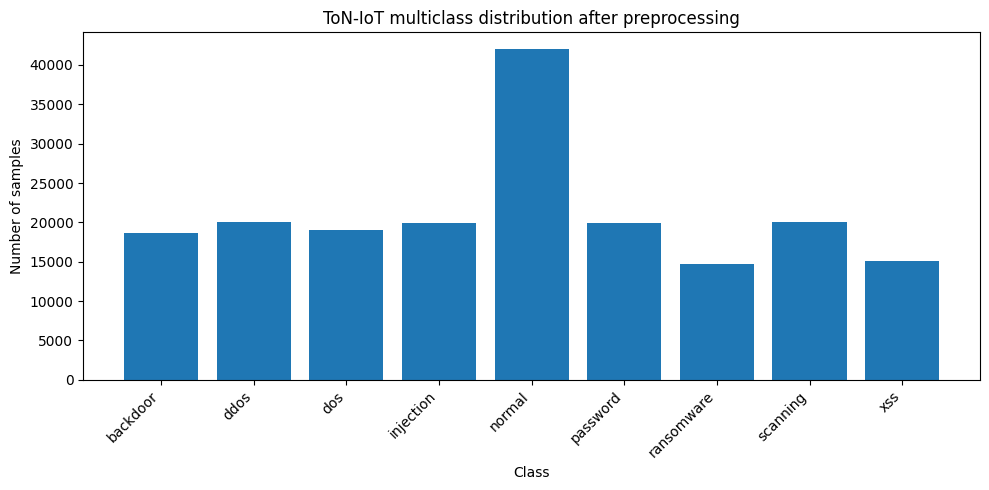

Saved: multiclass_preparation_outputs\figures\ton_iot_class_distribution_after_preprocessing.png


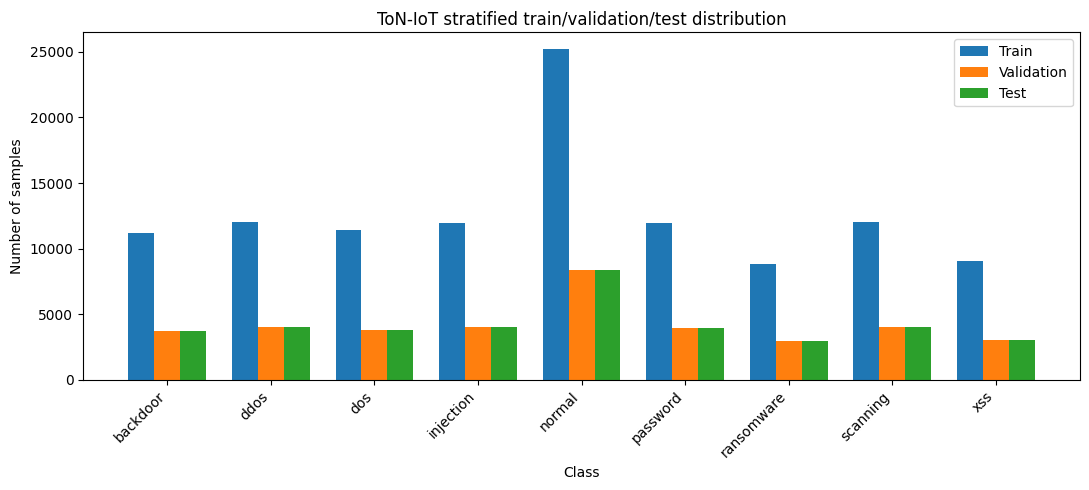

Saved: multiclass_preparation_outputs\figures\ton_iot_train_val_test_distribution.png

[Unseen-category diagnostic: validation/test vs training]
                  column  n_train_unique  n_val_unseen  n_test_unseen
3              dns_query             567            60             60
16              http_uri              66             8             12
18       http_user_agent              28             0              7
21            weird_name              10             1              1
14      http_trans_depth              10             0              1
20  http_resp_mime_types               9             0              1
2             conn_state              13             0              0
1                service               9             0              0
9             ssl_cipher               6             0              0
12           ssl_subject               6             0              0
13            ssl_issuer               5             0              0
8            ss

In [35]:
# STEP 2: Multiclass target preparation + data cleaning +
# leakage-aware feature design + stratified train/val/test split

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("=" * 80)
print("STEP 2: MULTICLASS TARGET PREPARATION + CLEANING + SPLITTING")
print("=" * 80)

t0 = time.perf_counter()

# Safety checks
assert "df" in globals(), "DataFrame 'df' not found. Run Step 1 first."
assert "type" in df.columns, "Expected multiclass target column 'type' not found."
assert "label" in df.columns, "Expected binary helper column 'label' not found."

df_work = df.copy()

print("\n[Initial dataset shape]")
print(df_work.shape)


# Standardize target text
df_work["type"] = df_work["type"].astype(str).str.strip().str.lower()
df_work["label"] = pd.to_numeric(df_work["label"], errors="coerce").fillna(-1).astype(int)

print("\n[Original multiclass distribution: 'type']")
print(df_work["type"].value_counts(dropna=False))

print("\n[Original binary distribution: 'label']")
print(df_work["label"].value_counts(dropna=False))


# Binary-vs-multiclass consistency check
# normal should correspond to label=0, attacks to label=1
print("\n[Consistency check between 'type' and binary 'label']")
consistency_table = pd.crosstab(df_work["type"], df_work["label"], margins=True)
print(consistency_table)


# Remove exact duplicate rows, because duplicates can inflate performance
n_before = len(df_work)
dup_count = df_work.duplicated().sum()

df_work = df_work.drop_duplicates().reset_index(drop=True)

n_after = len(df_work)
removed = n_before - n_after

print("\n[Duplicate handling]")
print("Rows before deduplication :", n_before)
print("Duplicate rows removed    :", removed)
print("Rows after deduplication  :", n_after)
print(f"Percent removed           : {100 * removed / max(n_before, 1):.4f}%")

print("\n[Class distribution after deduplication]")
print(df_work["type"].value_counts())


# Rare class handling
MIN_CLASS_COUNT = 2000

class_counts = df_work["type"].value_counts()
rare_classes = class_counts[class_counts < MIN_CLASS_COUNT].index.tolist()

print("\n[Rare class analysis]")
print("Minimum class count threshold:", MIN_CLASS_COUNT)
print("Rare classes detected        :", rare_classes if rare_classes else "None")

df_main = df_work[~df_work["type"].isin(rare_classes)].copy().reset_index(drop=True)

print("\n[Dataset shape after rare-class filtering]")
print(df_main.shape)

print("\n[Retained multiclass distribution]")
print(df_main["type"].value_counts())

excluded_summary = {
    "rare_classes_removed": rare_classes,
    "rows_removed_due_to_rare_classes": int(len(df_work) - len(df_main))
}
print("\n[Excluded class summary]")
print(json.dumps(excluded_summary, indent=2))


# Preserve context columns for forensic graph/evidence pipeline
# These are NOT all necessarily model features.
CONTEXT_COLS = [c for c in [
    "src_ip", "dst_ip", "src_port", "dst_port", "proto", "service", "conn_state"
] if c in df_main.columns]

print("\n[Context columns preserved for forensic use]")
print(CONTEXT_COLS)


# Define target and feature exclusions
# - 'type' is multiclass target
# - 'label' is binary helper and must be excluded from features
# - raw IPs are excluded from model features to reduce leakage / memorization
TARGET_COL = "type"
BINARY_HELPER_COL = "label"

DROP_FROM_FEATURES = [c for c in [
    TARGET_COL,
    BINARY_HELPER_COL,
    "src_ip",
    "dst_ip"
] if c in df_main.columns]

print("\n[Columns dropped from model features]")
print(DROP_FROM_FEATURES)


# Build feature table
# Replace '-' placeholders in object columns to make categorical handling explicit
X_raw = df_main.drop(columns=DROP_FROM_FEATURES, errors="ignore").copy()
y_text = df_main[TARGET_COL].copy()

# normalize placeholder tokens in object columns
obj_cols = X_raw.select_dtypes(include=["object", "string"]).columns.tolist()
for c in obj_cols:
    X_raw[c] = X_raw[c].astype(str).str.strip()
    X_raw[c] = X_raw[c].replace({"-": "MISSING_TOKEN", "": "MISSING_TOKEN", "nan": "MISSING_TOKEN"})

print("\n[Raw feature matrix]")
print("Shape:", X_raw.shape)

print("\n[Feature dtypes before encoding]")
print(X_raw.dtypes.value_counts())


# Encode multiclass target
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

label_mapping = {cls: int(idx) for idx, cls in enumerate(label_encoder.classes_)}
inv_label_mapping = {int(idx): cls for cls, idx in label_mapping.items()}

print("\n[Multiclass label mapping]")
print(label_mapping)

print("\n[Encoded target distribution]")
print(pd.Series(y).value_counts().sort_index())


# Column groups for modeling
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print("\n[Model feature groups]")
print("Numeric feature count     :", len(numeric_cols))
print("Categorical feature count :", len(categorical_cols))

print("\nNumeric feature columns:")
print(numeric_cols)

print("\nCategorical feature columns:")
print(categorical_cols)


# Cardinality review of categorical columns
# Useful for deciding one-hot vs frequency encoding later
cat_cardinality = pd.DataFrame({
    "column": categorical_cols,
    "n_unique": [X_raw[c].nunique(dropna=False) for c in categorical_cols]
}).sort_values(by="n_unique", ascending=False)

print("\n[Categorical cardinality summary]")
print(cat_cardinality)


# Optional: identify very high-cardinality categorical columns
# We may frequency-encode these later instead of one-hot encoding
HIGH_CARD_THRESHOLD = 50
high_card_cat_cols = cat_cardinality.loc[
    cat_cardinality["n_unique"] > HIGH_CARD_THRESHOLD, "column"
].tolist()

low_mid_card_cat_cols = cat_cardinality.loc[
    cat_cardinality["n_unique"] <= HIGH_CARD_THRESHOLD, "column"
].tolist()

print("\n[Categorical encoding strategy suggestion]")
print("High-cardinality categorical columns  :", high_card_cat_cols if high_card_cat_cols else "None")
print("Low/mid-cardinality categorical cols  :", low_mid_card_cat_cols if low_mid_card_cat_cols else "None")


# Stratified split: train / val / test
# First stable setup for multiclass pipeline
X_trainval_raw, X_test_raw, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X_raw,
    y,
    df_main.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train_raw, X_val_raw, y_train, y_val, idx_train, idx_val = train_test_split(
    X_trainval_raw,
    y_trainval,
    idx_trainval,
    test_size=0.25,   # 0.25 of 0.80 = 0.20 overall
    random_state=42,
    stratify=y_trainval
)

# context frames aligned with split indices
ctx_train = df_main.loc[idx_train, CONTEXT_COLS].reset_index(drop=True)
ctx_val   = df_main.loc[idx_val, CONTEXT_COLS].reset_index(drop=True)
ctx_test  = df_main.loc[idx_test, CONTEXT_COLS].reset_index(drop=True)

# reset feature indices for cleaner downstream use
X_train_raw = X_train_raw.reset_index(drop=True)
X_val_raw   = X_val_raw.reset_index(drop=True)
X_test_raw  = X_test_raw.reset_index(drop=True)

y_train = pd.Series(y_train).reset_index(drop=True)
y_val   = pd.Series(y_val).reset_index(drop=True)
y_test  = pd.Series(y_test).reset_index(drop=True)


# Split diagnostics
print("\n[Split shapes]")
print("X_train_raw :", X_train_raw.shape)
print("X_val_raw   :", X_val_raw.shape)
print("X_test_raw  :", X_test_raw.shape)

def print_split_distribution(name, y_split):
    vc = pd.Series(y_split).value_counts().sort_index()
    pct = pd.Series(y_split).value_counts(normalize=True).sort_index() * 100
    df_dist = pd.DataFrame({
        "class_id": vc.index,
        "class_name": [inv_label_mapping[i] for i in vc.index],
        "count": vc.values,
        "percent": pct.values.round(4)
    })
    print(f"\n[{name} class distribution]")
    print(df_dist)

print_split_distribution("TRAIN", y_train)
print_split_distribution("VAL", y_val)
print_split_distribution("TEST", y_test)

# Save split and metadata artifacts
OUT_DIR = "multiclass_preparation_outputs"
os.makedirs(OUT_DIR, exist_ok=True)


# Save class-distribution figures for manuscript reporting
FIG_DIR = os.path.join("multiclass_preparation_outputs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

print("\n[Saving class distribution figures]")

# Figure 1: retained multiclass distribution after filtering
class_counts_plot = df_main["type"].value_counts().reindex(label_encoder.classes_)

plt.figure(figsize=(10, 5))
plt.bar(class_counts_plot.index, class_counts_plot.values)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("ToN-IoT multiclass distribution after preprocessing")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

class_dist_fig_path = os.path.join(FIG_DIR, "ton_iot_class_distribution_after_preprocessing.png")
plt.savefig(class_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", class_dist_fig_path)


# Figure 2: train/validation/test class distribution
split_dist_df = pd.DataFrame({
    "class_name": label_encoder.classes_,
    "train": pd.Series(y_train).value_counts().sort_index().values,
    "val": pd.Series(y_val).value_counts().sort_index().values,
    "test": pd.Series(y_test).value_counts().sort_index().values
})

x_pos = np.arange(len(split_dist_df))
bar_width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x_pos - bar_width, split_dist_df["train"], width=bar_width, label="Train")
plt.bar(x_pos, split_dist_df["val"], width=bar_width, label="Validation")
plt.bar(x_pos + bar_width, split_dist_df["test"], width=bar_width, label="Test")

plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("ToN-IoT stratified train/validation/test distribution")
plt.xticks(x_pos, split_dist_df["class_name"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()

split_dist_fig_path = os.path.join(FIG_DIR, "ton_iot_train_val_test_distribution.png")
plt.savefig(split_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", split_dist_fig_path)

split_dist_df.to_csv(os.path.join(FIG_DIR, "ton_iot_train_val_test_distribution.csv"), index=False)


# Check for unseen categorical levels between splits
# Important for robust preprocessing
print("\n[Unseen-category diagnostic: validation/test vs training]")
unseen_report = []

for c in categorical_cols:
    train_vals = set(X_train_raw[c].astype(str).unique())
    val_vals = set(X_val_raw[c].astype(str).unique())
    test_vals = set(X_test_raw[c].astype(str).unique())

    unseen_val = sorted(list(val_vals - train_vals))
    unseen_test = sorted(list(test_vals - train_vals))

    unseen_report.append({
        "column": c,
        "n_train_unique": len(train_vals),
        "n_val_unseen": len(unseen_val),
        "n_test_unseen": len(unseen_test)
    })

unseen_report_df = pd.DataFrame(unseen_report).sort_values(
    by=["n_test_unseen", "n_val_unseen", "n_train_unique"],
    ascending=[False, False, False]
)

print(unseen_report_df)




cat_cardinality.to_csv(os.path.join(OUT_DIR, "categorical_cardinality.csv"), index=False)
unseen_report_df.to_csv(os.path.join(OUT_DIR, "unseen_category_report.csv"), index=False)

prep_summary = {
    "target_column": TARGET_COL,
    "binary_helper_column": BINARY_HELPER_COL,
    "label_mapping": label_mapping,
    "rare_classes_removed": rare_classes,
    "rows_after_deduplication": int(len(df_work)),
    "rows_after_rare_class_filter": int(len(df_main)),
    "n_features_raw": int(X_raw.shape[1]),
    "numeric_feature_count": int(len(numeric_cols)),
    "categorical_feature_count": int(len(categorical_cols)),
    "high_cardinality_categorical_columns": high_card_cat_cols,
    "context_columns": CONTEXT_COLS,
    "train_shape": list(X_train_raw.shape),
    "val_shape": list(X_val_raw.shape),
    "test_shape": list(X_test_raw.shape)
}

with open(os.path.join(OUT_DIR, "multiclass_prep_summary.json"), "w", encoding="utf-8") as f:
    json.dump(prep_summary, f, indent=2)

t_step2 = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Preparation summary]")
print(json.dumps(prep_summary, indent=2))

print(f"\nSTEP 2 completed successfully in {t_step2:.4f} seconds.")

STEP 3: REQUIRED COMPANION PREPARATION

[All-classes setup]
Shape: (190474, 44)
Class mapping: {'backdoor': 0, 'ddos': 1, 'dos': 2, 'injection': 3, 'mitm': 4, 'normal': 5, 'password': 6, 'ransomware': 7, 'scanning': 8, 'xss': 9}
Class counts:
type
normal        42040
scanning      20000
ddos          19993
injection     19964
password      19861
dos           18992
backdoor      18711
xss           15137
ransomware    14735
mitm           1041
Name: count, dtype: int64

[Suggested class weights for all-classes run]
{0: 1.01797872908984, 1: 0.9527034462061722, 2: 1.0029170176916598, 3: 0.9540873572430375, 4: 18.297214217098944, 5: 0.4530780209324453, 6: 0.9590352953023513, 7: 1.2926637258228708, 8: 0.95237, 9: 1.2583338838607385}

[Leakage-resistant grouped split setup]
Grouping column: src_ip
Rows           : 189433
Unique groups  : 51

[Grouped split shapes]
X_train_group_raw : (98008, 40)
X_val_group_raw   : (84019, 40)
X_test_group_raw  : (7406, 40)

[TRAIN grouped-split class distr

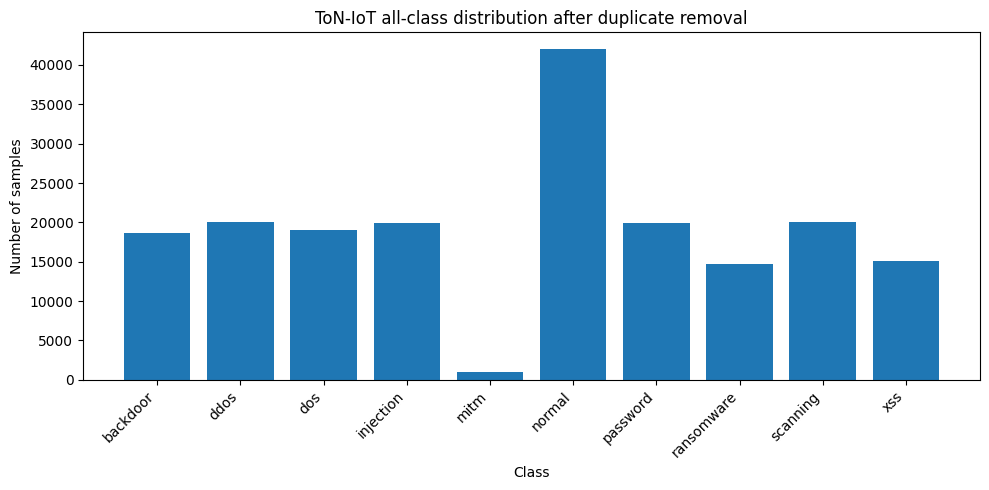

Saved: companion_outputs\figures\ton_iot_all_class_distribution.png


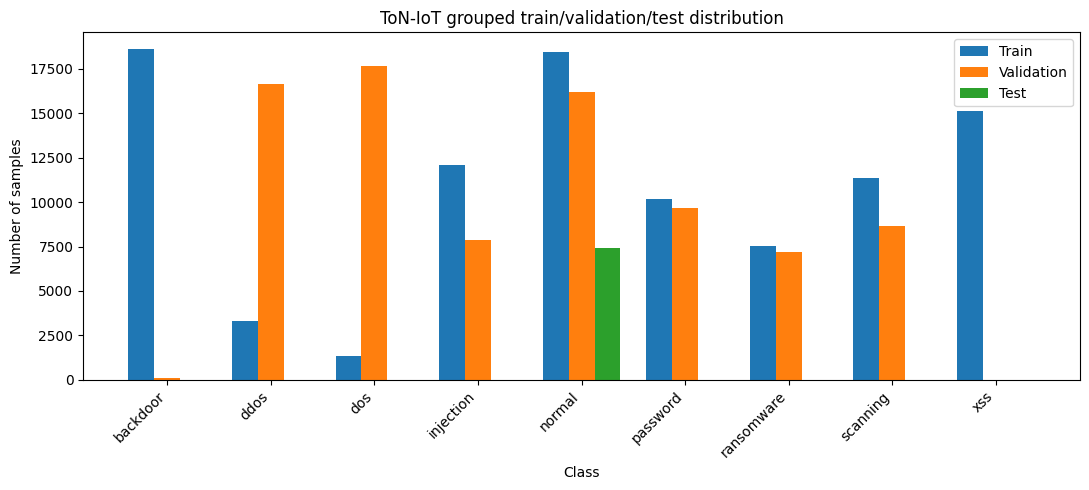

Saved: companion_outputs\figures\ton_iot_grouped_train_val_test_distribution.png

[Group overlap check]
Train ∩ Val  : 0
Train ∩ Test : 0
Val ∩ Test   : 0

[Saved companion artifacts]
Directory: companion_outputs
{
  "all_classes_shape": [
    190474,
    44
  ],
  "all_classes_label_mapping": {
    "backdoor": 0,
    "ddos": 1,
    "dos": 2,
    "injection": 3,
    "mitm": 4,
    "normal": 5,
    "password": 6,
    "ransomware": 7,
    "scanning": 8,
    "xss": 9
  },
  "all_classes_class_weights": {
    "0": 1.01797872908984,
    "1": 0.9527034462061722,
    "2": 1.0029170176916598,
    "3": 0.9540873572430375,
    "4": 18.297214217098944,
    "5": 0.4530780209324453,
    "6": 0.9590352953023513,
    "7": 1.2926637258228708,
    "8": 0.95237,
    "9": 1.2583338838607385
  },
  "group_column": "src_ip",
  "n_unique_groups": 51,
  "grouped_train_shape": [
    98008,
    40
  ],
  "grouped_val_shape": [
    84019,
    40
  ],
  "grouped_test_shape": [
    7406,
    40
  ],
  "train_val_

In [36]:
# STEP 3


import os
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

print("=" * 80)
print("STEP 3: REQUIRED COMPANION PREPARATION")
print("=" * 80)

assert "df_work" in globals(), "Run Step 2 first."
assert "label_encoder" in globals(), "Run Step 2 first."


# A. Retain all classes for robustness run
df_all = df_work.copy().reset_index(drop=True)

TARGET_COL_ALL = "type"
BINARY_HELPER_COL_ALL = "label"

DROP_FROM_FEATURES_ALL = [c for c in [
    TARGET_COL_ALL,
    BINARY_HELPER_COL_ALL,
    "src_ip",
    "dst_ip"
] if c in df_all.columns]

X_all_raw = df_all.drop(columns=DROP_FROM_FEATURES_ALL, errors="ignore").copy()
y_all_text = df_all[TARGET_COL_ALL].copy()

obj_cols_all = X_all_raw.select_dtypes(include=["object", "string"]).columns.tolist()
for c in obj_cols_all:
    X_all_raw[c] = X_all_raw[c].astype(str).str.strip()
    X_all_raw[c] = X_all_raw[c].replace({"-": "MISSING_TOKEN", "": "MISSING_TOKEN", "nan": "MISSING_TOKEN"})

# fresh encoder for all-classes setup
from sklearn.preprocessing import LabelEncoder
label_encoder_all = LabelEncoder()
y_all = label_encoder_all.fit_transform(y_all_text)

label_mapping_all = {cls: int(i) for i, cls in enumerate(label_encoder_all.classes_)}
inv_label_mapping_all = {int(i): cls for cls, i in label_mapping_all.items()}

print("\n[All-classes setup]")
print("Shape:", df_all.shape)
print("Class mapping:", label_mapping_all)
print("Class counts:")
print(df_all["type"].value_counts())

# class weights for rare-class robustness run
classes_all = np.unique(y_all)
class_weights_all = compute_class_weight(
    class_weight="balanced",
    classes=classes_all,
    y=y_all
)
class_weight_dict_all = {int(c): float(w) for c, w in zip(classes_all, class_weights_all)}

print("\n[Suggested class weights for all-classes run]")
print(class_weight_dict_all)


# B. Leakage-resistant grouped split
# Group by src_ip if available, else fallback to dst_ip
GROUP_COL = "src_ip" if "src_ip" in df_main.columns else ("dst_ip" if "dst_ip" in df_main.columns else None)
assert GROUP_COL is not None, "No suitable grouping column found for grouped split."

groups = df_main[GROUP_COL].astype(str).values

print("\n[Leakage-resistant grouped split setup]")
print("Grouping column:", GROUP_COL)
print("Rows           :", len(groups))
print("Unique groups  :", len(np.unique(groups)))

# Use group shuffle for train/test, then split train into train/val by groups
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
trainval_idx_g, test_idx_g = next(gss_outer.split(X_raw, y, groups=groups))

X_trainval_group_raw = X_raw.iloc[trainval_idx_g].reset_index(drop=True)
X_test_group_raw     = X_raw.iloc[test_idx_g].reset_index(drop=True)

y_trainval_group = pd.Series(y).iloc[trainval_idx_g].reset_index(drop=True)
y_test_group     = pd.Series(y).iloc[test_idx_g].reset_index(drop=True)

groups_trainval = groups[trainval_idx_g]

gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_g2, val_idx_g2 = next(gss_inner.split(X_trainval_group_raw, y_trainval_group, groups=groups_trainval))

X_train_group_raw = X_trainval_group_raw.iloc[train_idx_g2].reset_index(drop=True)
X_val_group_raw   = X_trainval_group_raw.iloc[val_idx_g2].reset_index(drop=True)

y_train_group = y_trainval_group.iloc[train_idx_g2].reset_index(drop=True)
y_val_group   = y_trainval_group.iloc[val_idx_g2].reset_index(drop=True)

ctx_train_group = df_main.iloc[np.array(trainval_idx_g)[train_idx_g2]][CONTEXT_COLS].reset_index(drop=True)
ctx_val_group   = df_main.iloc[np.array(trainval_idx_g)[val_idx_g2]][CONTEXT_COLS].reset_index(drop=True)
ctx_test_group  = df_main.iloc[test_idx_g][CONTEXT_COLS].reset_index(drop=True)

print("\n[Grouped split shapes]")
print("X_train_group_raw :", X_train_group_raw.shape)
print("X_val_group_raw   :", X_val_group_raw.shape)
print("X_test_group_raw  :", X_test_group_raw.shape)

def show_group_dist(name, y_split, inv_map):
    vc = pd.Series(y_split).value_counts().sort_index()
    pct = pd.Series(y_split).value_counts(normalize=True).sort_index() * 100
    dist_df = pd.DataFrame({
        "class_id": vc.index,
        "class_name": [inv_map[int(i)] for i in vc.index],
        "count": vc.values,
        "percent": pct.values.round(4)
    })
    print(f"\n[{name} grouped-split class distribution]")
    print(dist_df)

show_group_dist("TRAIN", y_train_group, inv_label_mapping)
show_group_dist("VAL", y_val_group, inv_label_mapping)
show_group_dist("TEST", y_test_group, inv_label_mapping)

# Save metadata
OUT_DIR_2B = "companion_outputs"
os.makedirs(OUT_DIR_2B, exist_ok=True)

# Save companion distribution figures
FIG_DIR_2B = os.path.join("companion_outputs", "figures")
os.makedirs(FIG_DIR_2B, exist_ok=True)

print("\n[Saving companion distribution figures]")

# Figure 1: all-classes distribution including rare class
all_class_counts_plot = df_all["type"].value_counts().reindex(label_encoder_all.classes_)

plt.figure(figsize=(10, 5))
plt.bar(all_class_counts_plot.index, all_class_counts_plot.values)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("ToN-IoT all-class distribution after duplicate removal")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

all_class_fig_path = os.path.join(FIG_DIR_2B, "ton_iot_all_class_distribution.png")
plt.savefig(all_class_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", all_class_fig_path)


# Figure 2: grouped train/validation/test class distribution
group_train_counts = pd.Series(y_train_group).value_counts().reindex(range(len(inv_label_mapping)), fill_value=0).sort_index()
group_val_counts   = pd.Series(y_val_group).value_counts().reindex(range(len(inv_label_mapping)), fill_value=0).sort_index()
group_test_counts  = pd.Series(y_test_group).value_counts().reindex(range(len(inv_label_mapping)), fill_value=0).sort_index()

group_split_dist_df = pd.DataFrame({
    "class_name": [inv_label_mapping[i] for i in range(len(inv_label_mapping))],
    "train": group_train_counts.values,
    "val": group_val_counts.values,
    "test": group_test_counts.values
})

x_pos = np.arange(len(group_split_dist_df))
bar_width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x_pos - bar_width, group_split_dist_df["train"], width=bar_width, label="Train")
plt.bar(x_pos, group_split_dist_df["val"], width=bar_width, label="Validation")
plt.bar(x_pos + bar_width, group_split_dist_df["test"], width=bar_width, label="Test")

plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("ToN-IoT grouped train/validation/test distribution")
plt.xticks(x_pos, group_split_dist_df["class_name"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()

group_split_fig_path = os.path.join(FIG_DIR_2B, "ton_iot_grouped_train_val_test_distribution.png")
plt.savefig(group_split_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", group_split_fig_path)

group_split_dist_df.to_csv(
    os.path.join(FIG_DIR_2B, "ton_iot_grouped_train_val_test_distribution.csv"),
    index=False
)

# group overlap diagnostic
train_groups_final = set(ctx_train_group[GROUP_COL].astype(str).unique())
val_groups_final   = set(ctx_val_group[GROUP_COL].astype(str).unique())
test_groups_final  = set(ctx_test_group[GROUP_COL].astype(str).unique())

print("\n[Group overlap check]")
print("Train ∩ Val  :", len(train_groups_final & val_groups_final))
print("Train ∩ Test :", len(train_groups_final & test_groups_final))
print("Val ∩ Test   :", len(val_groups_final & test_groups_final))


# # Save metadata
# OUT_DIR_2B = "companion_outputs"
# os.makedirs(OUT_DIR_2B, exist_ok=True)

companion_summary = {
    "all_classes_shape": list(df_all.shape),
    "all_classes_label_mapping": label_mapping_all,
    "all_classes_class_weights": class_weight_dict_all,
    "group_column": GROUP_COL,
    "n_unique_groups": int(len(np.unique(groups))),
    "grouped_train_shape": list(X_train_group_raw.shape),
    "grouped_val_shape": list(X_val_group_raw.shape),
    "grouped_test_shape": list(X_test_group_raw.shape),
    "train_val_group_overlap": int(len(train_groups_final & val_groups_final)),
    "train_test_group_overlap": int(len(train_groups_final & test_groups_final)),
    "val_test_group_overlap": int(len(val_groups_final & test_groups_final))
}

with open(os.path.join(OUT_DIR_2B, "companion_summary.json"), "w", encoding="utf-8") as f:
    json.dump(companion_summary, f, indent=2)

print("\n[Saved companion artifacts]")
print("Directory:", OUT_DIR_2B)
print(json.dumps(companion_summary, indent=2))

print("\nSTEP 3 completed successfully.")

STEP 4: LEAKAGE-RESISTANT BINARY GROUPED SPLIT

[Binary dataset shape]
(190474, 45)

[Binary target distribution]
binary_target
1    148434
0     42040
Name: count, dtype: int64
binary_target
1    77.9287
0    22.0713
Name: proportion, dtype: float64

[Context columns for grouped binary setup]
['src_ip', 'dst_ip', 'src_port', 'dst_port', 'proto', 'service', 'conn_state']

[Binary raw feature matrix]
(190474, 40)

[Grouping metadata]
Grouping column     : host_pair_group
Unique host pairs   : 1026

[Grouped binary split shapes]
X_train_bin_raw : (124684, 40)
X_val_bin_raw   : (36174, 40)
X_test_bin_raw  : (29616, 40)

[TRAIN binary grouped-split distribution]
   class_id class_name  count  percent
0         0     benign  26667  21.3877
1         1     attack  98017  78.6123

[VAL binary grouped-split distribution]
   class_id class_name  count  percent
0         0     benign   7944  21.9605
1         1     attack  28230  78.0395

[TEST binary grouped-split distribution]
   class_id clas

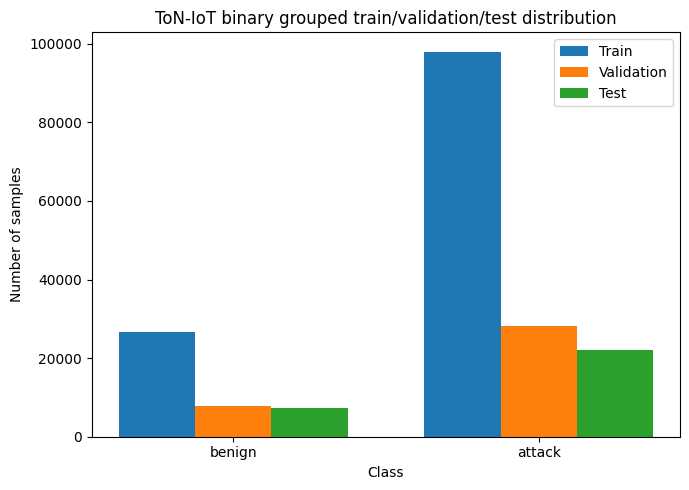

Saved: binary_grouped_split_outputs\figures\ton_iot_binary_grouped_train_val_test_distribution.png

[Host-pair group overlap check]
Train ∩ Val  : 0
Train ∩ Test : 0
Val ∩ Test   : 0

[Saved grouped binary artifacts]
Directory: binary_grouped_split_outputs
{
  "rows": 190474,
  "binary_distribution": {
    "0": 42040,
    "1": 148434
  },
  "n_unique_host_pairs": 1026,
  "train_shape": [
    124684,
    40
  ],
  "val_shape": [
    36174,
    40
  ],
  "test_shape": [
    29616,
    40
  ],
  "train_val_overlap": 0,
  "train_test_overlap": 0,
  "val_test_overlap": 0
}

STEP 4 completed successfully.


In [37]:
# STEP 4: Leakage-resistant binary grouped split

import os
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

print("=" * 80)
print("STEP 4: LEAKAGE-RESISTANT BINARY GROUPED SPLIT")
print("=" * 80)

assert "df_work" in globals(), "Run Step 2 first."


# Build binary dataset after deduplication
# Keep all rows here; no rare-class filtering needed for binary
df_bin = df_work.copy().reset_index(drop=True)

df_bin["binary_target"] = pd.to_numeric(df_bin["label"], errors="coerce").fillna(-1).astype(int)

print("\n[Binary dataset shape]")
print(df_bin.shape)

print("\n[Binary target distribution]")
print(df_bin["binary_target"].value_counts())
print((100 * df_bin["binary_target"].value_counts(normalize=True)).round(4))


# Preserve context
CONTEXT_COLS_BIN = [c for c in [
    "src_ip", "dst_ip", "src_port", "dst_port", "proto", "service", "conn_state"
] if c in df_bin.columns]

print("\n[Context columns for grouped binary setup]")
print(CONTEXT_COLS_BIN)


# Feature exclusions
# Exclude raw IPs and targets from predictive features
DROP_FROM_FEATURES_BIN = [c for c in [
    "type",
    "label",
    "binary_target",
    "src_ip",
    "dst_ip"
] if c in df_bin.columns]

X_bin_raw = df_bin.drop(columns=DROP_FROM_FEATURES_BIN, errors="ignore").copy()
y_bin = df_bin["binary_target"].copy()

obj_cols_bin = X_bin_raw.select_dtypes(include=["object", "string"]).columns.tolist()
for c in obj_cols_bin:
    X_bin_raw[c] = X_bin_raw[c].astype(str).str.strip()
    X_bin_raw[c] = X_bin_raw[c].replace({"-": "MISSING_TOKEN", "": "MISSING_TOKEN", "nan": "MISSING_TOKEN"})

print("\n[Binary raw feature matrix]")
print(X_bin_raw.shape)


# Group by directed host pair
# Stronger than random split, less degenerate than src_ip alone
assert "src_ip" in df_bin.columns and "dst_ip" in df_bin.columns, "Need src_ip and dst_ip for grouped split."

df_bin["host_pair_group"] = df_bin["src_ip"].astype(str) + "->" + df_bin["dst_ip"].astype(str)
groups_bin = df_bin["host_pair_group"].values

print("\n[Grouping metadata]")
print("Grouping column     : host_pair_group")
print("Unique host pairs   :", df_bin["host_pair_group"].nunique())


# Outer split: trainval/test
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
trainval_idx_b, test_idx_b = next(gss_outer.split(X_bin_raw, y_bin, groups=groups_bin))

X_trainval_bin_raw = X_bin_raw.iloc[trainval_idx_b].reset_index(drop=True)
X_test_bin_raw     = X_bin_raw.iloc[test_idx_b].reset_index(drop=True)

y_trainval_bin = y_bin.iloc[trainval_idx_b].reset_index(drop=True)
y_test_bin     = y_bin.iloc[test_idx_b].reset_index(drop=True)

groups_trainval_bin = groups_bin[trainval_idx_b]


# Inner split: train/val
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_b2, val_idx_b2 = next(gss_inner.split(X_trainval_bin_raw, y_trainval_bin, groups=groups_trainval_bin))

X_train_bin_raw = X_trainval_bin_raw.iloc[train_idx_b2].reset_index(drop=True)
X_val_bin_raw   = X_trainval_bin_raw.iloc[val_idx_b2].reset_index(drop=True)

y_train_bin = y_trainval_bin.iloc[train_idx_b2].reset_index(drop=True)
y_val_bin   = y_trainval_bin.iloc[val_idx_b2].reset_index(drop=True)

ctx_train_bin = df_bin.iloc[np.array(trainval_idx_b)[train_idx_b2]][CONTEXT_COLS_BIN].reset_index(drop=True)
ctx_val_bin   = df_bin.iloc[np.array(trainval_idx_b)[val_idx_b2]][CONTEXT_COLS_BIN].reset_index(drop=True)
ctx_test_bin  = df_bin.iloc[test_idx_b][CONTEXT_COLS_BIN].reset_index(drop=True)

print("\n[Grouped binary split shapes]")
print("X_train_bin_raw :", X_train_bin_raw.shape)
print("X_val_bin_raw   :", X_val_bin_raw.shape)
print("X_test_bin_raw  :", X_test_bin_raw.shape)

def show_bin_dist(name, y_split):
    vc = pd.Series(y_split).value_counts().sort_index()
    pct = pd.Series(y_split).value_counts(normalize=True).sort_index() * 100
    out = pd.DataFrame({
        "class_id": vc.index,
        "class_name": ["benign" if i == 0 else "attack" for i in vc.index],
        "count": vc.values,
        "percent": pct.values.round(4)
    })
    print(f"\n[{name} binary grouped-split distribution]")
    print(out)

show_bin_dist("TRAIN", y_train_bin)
show_bin_dist("VAL", y_val_bin)
show_bin_dist("TEST", y_test_bin)


# Save binary grouped-split distribution figure
OUT_DIR_2C = "binary_grouped_split_outputs"
os.makedirs(OUT_DIR_2C, exist_ok=True)

FIG_DIR_2C = os.path.join(OUT_DIR_2C, "figures")
os.makedirs(FIG_DIR_2C, exist_ok=True)

print("\n[Saving binary grouped-split figure]")

bin_train_counts = pd.Series(y_train_bin).value_counts().reindex([0, 1], fill_value=0).sort_index()
bin_val_counts   = pd.Series(y_val_bin).value_counts().reindex([0, 1], fill_value=0).sort_index()
bin_test_counts  = pd.Series(y_test_bin).value_counts().reindex([0, 1], fill_value=0).sort_index()

bin_split_dist_df = pd.DataFrame({
    "class_name": ["benign", "attack"],
    "train": bin_train_counts.values,
    "val": bin_val_counts.values,
    "test": bin_test_counts.values
})

x_pos = np.arange(len(bin_split_dist_df))
bar_width = 0.25

plt.figure(figsize=(7, 5))
plt.bar(x_pos - bar_width, bin_split_dist_df["train"], width=bar_width, label="Train")
plt.bar(x_pos, bin_split_dist_df["val"], width=bar_width, label="Validation")
plt.bar(x_pos + bar_width, bin_split_dist_df["test"], width=bar_width, label="Test")

plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("ToN-IoT binary grouped train/validation/test distribution")
plt.xticks(x_pos, bin_split_dist_df["class_name"])
plt.legend()
plt.tight_layout()

bin_grouped_fig_path = os.path.join(FIG_DIR_2C, "ton_iot_binary_grouped_train_val_test_distribution.png")
plt.savefig(bin_grouped_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", bin_grouped_fig_path)

bin_split_dist_df.to_csv(
    os.path.join(FIG_DIR_2C, "ton_iot_binary_grouped_train_val_test_distribution.csv"),
    index=False
)


# Group overlap check
train_groups_bin = set(df_bin.iloc[np.array(trainval_idx_b)[train_idx_b2]]["host_pair_group"].astype(str).unique())
val_groups_bin   = set(df_bin.iloc[np.array(trainval_idx_b)[val_idx_b2]]["host_pair_group"].astype(str).unique())
test_groups_bin  = set(df_bin.iloc[test_idx_b]["host_pair_group"].astype(str).unique())

print("\n[Host-pair group overlap check]")
print("Train ∩ Val  :", len(train_groups_bin & val_groups_bin))
print("Train ∩ Test :", len(train_groups_bin & test_groups_bin))
print("Val ∩ Test   :", len(val_groups_bin & test_groups_bin))


# # Save outputs
# OUT_DIR_2C = "binary_grouped_split_outputs"
# os.makedirs(OUT_DIR_2C, exist_ok=True)

step2c_summary = {
    "rows": int(len(df_bin)),
    "binary_distribution": {str(k): int(v) for k, v in df_bin["binary_target"].value_counts().sort_index().items()},
    "n_unique_host_pairs": int(df_bin["host_pair_group"].nunique()),
    "train_shape": list(X_train_bin_raw.shape),
    "val_shape": list(X_val_bin_raw.shape),
    "test_shape": list(X_test_bin_raw.shape),
    "train_val_overlap": int(len(train_groups_bin & val_groups_bin)),
    "train_test_overlap": int(len(train_groups_bin & test_groups_bin)),
    "val_test_overlap": int(len(val_groups_bin & test_groups_bin))
}

with open(os.path.join(OUT_DIR_2C, "binary_grouped_split_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step2c_summary, f, indent=2)

print("\n[Saved grouped binary artifacts]")
print("Directory:", OUT_DIR_2C)
print(json.dumps(step2c_summary, indent=2))

print("\nSTEP 4 completed successfully.")

STEP 5: MULTICLASS PREPROCESSING + TRAINING + MODEL SELECTION

[Numeric preprocessing plan]
Log-transform numeric columns:
['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'http_request_body_len', 'http_response_body_len']

Non-log numeric columns:
['src_port', 'dst_port', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_status_code']

[Categorical preprocessing plan]
High-cardinality categorical columns:
['dns_query', 'http_uri']

Low/mid-cardinality categorical columns:
['http_user_agent', 'conn_state', 'weird_name', 'http_trans_depth', 'http_resp_mime_types', 'service', 'ssl_subject', 'ssl_cipher', 'ssl_issuer', 'http_method', 'ssl_version', 'proto', 'dns_RD', 'dns_AA', 'dns_rejected', 'dns_RA', 'ssl_resumed', 'ssl_established', 'weird_addl', 'http_orig_mime_types', 'http_version', 'weird_notice']

[Candidate models]
['logreg', 'rf', 'extratrees']

-----------------------------------------------------------------------------

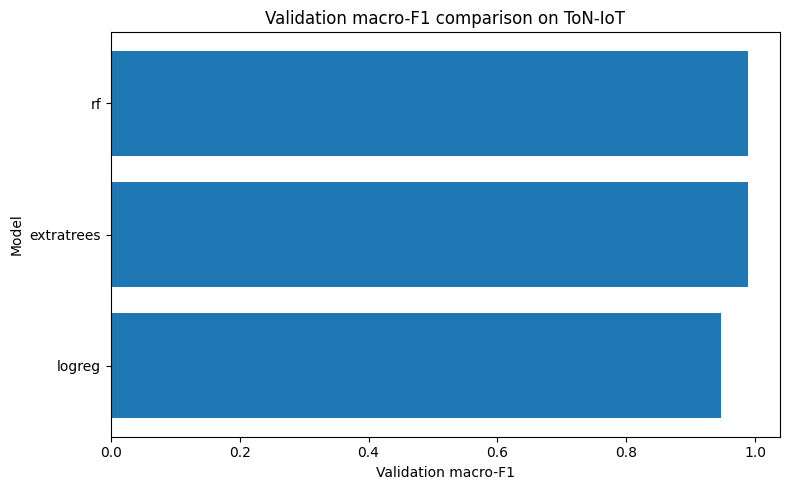

Saved: multiclass_model_selection_outputs\figures\ton_iot_validation_macro_f1_comparison.png

[Selected best model]
Best model name: rf

[Best model refit on TRAIN+VAL]
Refit time (s): 18.2198
Fitting final model on TRAIN+VAL: logreg
Fitting final model on TRAIN+VAL: rf
Fitting final model on TRAIN+VAL: extratrees

Final models trained:
['logreg', 'rf', 'extratrees']

[VALIDATION CLASSIFICATION REPORT: rf]
              precision    recall  f1-score   support

    backdoor     0.9995    1.0000    0.9997      3742
        ddos     0.9870    0.9872    0.9871      3999
         dos     0.9874    0.9887    0.9880      3798
   injection     0.9771    0.9712    0.9741      3993
      normal     0.9987    0.9973    0.9980      8408
    password     0.9947    0.9940    0.9943      3972
  ransomware     0.9986    1.0000    0.9993      2947
    scanning     0.9893    0.9915    0.9904      4000
         xss     0.9682    0.9739    0.9710      3028

    accuracy                         0.9903     

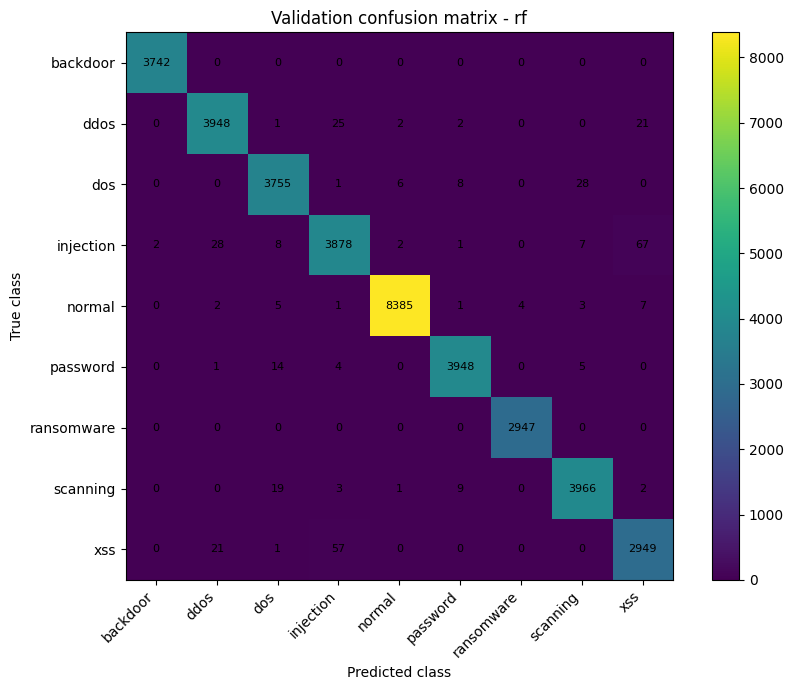

Saved: multiclass_model_selection_outputs\figures\validation_confusion_matrix_rf.png


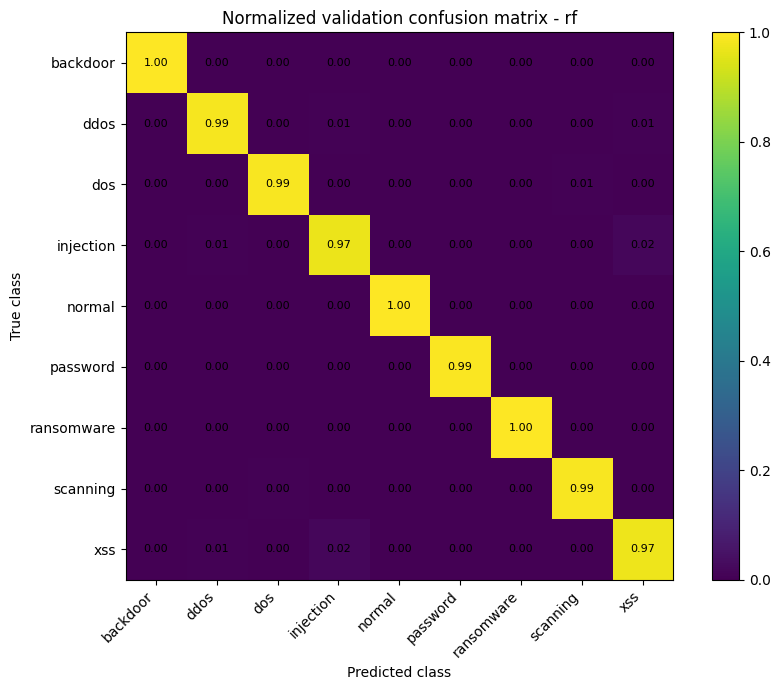

Saved: multiclass_model_selection_outputs\figures\validation_confusion_matrix_normalized_rf.png

[Saved artifacts]
Directory: multiclass_model_selection_outputs

[Step 5 summary]
{
  "candidate_models": [
    "logreg",
    "rf",
    "extratrees"
  ],
  "best_model": "rf",
  "selection_rule": [
    "highest validation macro F1",
    "then highest validation weighted F1",
    "then highest validation OVR macro ROC-AUC",
    "then lowest latency"
  ],
  "refit_time_seconds": 18.219758999999613,
  "train_shape": [
    113659,
    40
  ],
  "val_shape": [
    37887,
    40
  ],
  "trainval_shape": [
    151546,
    40
  ],
  "test_shape": [
    37887,
    40
  ]
}

STEP 5 completed successfully in 147.2469 seconds.


In [38]:

# STEP 5: Multiclass preprocessing + baseline training +
# validation-based model selection

import os
import json
import time
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("=" * 80)
print("STEP 5: MULTICLASS PREPROCESSING + TRAINING + MODEL SELECTION")
print("=" * 80)

t0 = time.perf_counter()

OUT_DIR = "multiclass_model_selection_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Safety checks
required_vars = [
    "X_train_raw", "X_val_raw", "X_test_raw",
    "y_train", "y_val", "y_test",
    "numeric_cols", "categorical_cols",
    "high_card_cat_cols", "low_mid_card_cat_cols",
    "inv_label_mapping", "label_mapping"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Step 2 first."


# Custom frequency encoder for high-cardinality categorical columns
# Learned on training only, safe on unseen values
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_maps_ = {}
        self.columns_ = []

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)
        self.freq_maps_ = {}

        n = len(X)
        for c in self.columns_:
            s = X[c].astype(str)
            vc = s.value_counts(dropna=False)
            self.freq_maps_[c] = (vc / max(n, 1)).to_dict()

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = np.zeros((len(X), len(self.columns_)), dtype=float)

        for j, c in enumerate(self.columns_):
            fmap = self.freq_maps_.get(c, {})
            out[:, j] = X[c].astype(str).map(fmap).fillna(0.0).astype(float).to_numpy()

        return out


# Optional log transform for highly skewed numeric traffic features
# 
log_transform_candidates = [
    "duration", "src_bytes", "dst_bytes", "missed_bytes",
    "src_pkts", "src_ip_bytes", "dst_pkts", "dst_ip_bytes",
    "http_request_body_len", "http_response_body_len"
]
log_transform_numeric_cols = [c for c in log_transform_candidates if c in numeric_cols]
non_log_numeric_cols = [c for c in numeric_cols if c not in log_transform_numeric_cols]

print("\n[Numeric preprocessing plan]")
print("Log-transform numeric columns:")
print(log_transform_numeric_cols if log_transform_numeric_cols else "None")

print("\nNon-log numeric columns:")
print(non_log_numeric_cols if non_log_numeric_cols else "None")

print("\n[Categorical preprocessing plan]")
print("High-cardinality categorical columns:")
print(high_card_cat_cols if high_card_cat_cols else "None")

print("\nLow/mid-cardinality categorical columns:")
print(low_mid_card_cat_cols if low_mid_card_cat_cols else "None")


# Build preprocessing pipelines
# We create two preprocessors:
#   1) scaled_preprocessor  -> for logistic regression
#   2) tree_preprocessor    -> for tree-based models
# numeric branches
log_num_pipe_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

plain_num_pipe_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

log_num_pipe_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, validate=False))
])

plain_num_pipe_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# low/mid categorical one-hot
ohe_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# high-cardinality categorical frequency encoding
freq_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("freq", FrequencyEncoder())
])

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_num_pipe_scaled, log_transform_numeric_cols),
        ("plain_num", plain_num_pipe_scaled, non_log_numeric_cols),
        ("lowmid_cat", ohe_pipe, low_mid_card_cat_cols),
        ("high_cat", freq_pipe, high_card_cat_cols),
    ],
    remainder="drop"
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_num_pipe_tree, log_transform_numeric_cols),
        ("plain_num", plain_num_pipe_tree, non_log_numeric_cols),
        ("lowmid_cat", ohe_pipe, low_mid_card_cat_cols),
        ("high_cat", freq_pipe, high_card_cat_cols),
    ],
    remainder="drop"
)


# Define models
models = {
    "logreg": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("clf", LogisticRegression(
            max_iter=400,
            multi_class="auto",
            class_weight="balanced",
            n_jobs=None
        ))
    ]),
    "rf": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=250,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]),
    "extratrees": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("clf", ExtraTreesClassifier(
            n_estimators=250,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])
}

print("\n[Candidate models]")
print(list(models.keys()))


# Evaluation helper for multiclass validation
def evaluate_multiclass_model(model, X_tr, y_tr, X_va, y_va):
    result = {}

    # fit time
    t_fit0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    fit_s = time.perf_counter() - t_fit0

    # predict time
    t_pred0 = time.perf_counter()
    y_pred = model.predict(X_va)
    pred_s = time.perf_counter() - t_pred0

    # metrics
    acc = accuracy_score(y_va, y_pred)
    f1_macro = f1_score(y_va, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_va, y_pred, average="weighted", zero_division=0)
    prec_macro = precision_score(y_va, y_pred, average="macro", zero_division=0)
    rec_macro = recall_score(y_va, y_pred, average="macro", zero_division=0)

    result["val_acc"] = acc
    result["val_f1_macro"] = f1_macro
    result["val_f1_weighted"] = f1_weighted
    result["val_prec_macro"] = prec_macro
    result["val_rec_macro"] = rec_macro
    result["fit_s"] = fit_s
    result["pred_s"] = pred_s
    result["pred_ms_per_sample"] = 1000 * pred_s / len(X_va)

    # multiclass ROC-AUC (OVR macro) if predict_proba exists
    result["val_roc_auc_ovr_macro"] = np.nan
    result["val_roc_auc_ovr_weighted"] = np.nan
    result["y_pred"] = y_pred
    result["y_proba"] = None

    if hasattr(model, "predict_proba"):
        try:
            y_proba = model.predict_proba(X_va)
            result["y_proba"] = y_proba
            result["val_roc_auc_ovr_macro"] = roc_auc_score(
                y_va, y_proba, multi_class="ovr", average="macro"
            )
            result["val_roc_auc_ovr_weighted"] = roc_auc_score(
                y_va, y_proba, multi_class="ovr", average="weighted"
            )
        except Exception as e:
            print(f"ROC-AUC computation warning: {e}")

    return result


# Train/evaluate all candidate models on validation split
rows = []
val_diagnostics = {}

for name, model in models.items():
    print("\n" + "-" * 80)
    print(f"Training model: {name}")

    res = evaluate_multiclass_model(model, X_train_raw, y_train, X_val_raw, y_val)
    val_diagnostics[name] = res

    rows.append({
        "model": name,
        "val_acc": res["val_acc"],
        "val_f1_macro": res["val_f1_macro"],
        "val_f1_weighted": res["val_f1_weighted"],
        "val_prec_macro": res["val_prec_macro"],
        "val_rec_macro": res["val_rec_macro"],
        "val_roc_auc_ovr_macro": res["val_roc_auc_ovr_macro"],
        "val_roc_auc_ovr_weighted": res["val_roc_auc_ovr_weighted"],
        "fit_s": res["fit_s"],
        "pred_s": res["pred_s"],
        "pred_ms_per_sample": res["pred_ms_per_sample"]
    })

    print(f"Validation Accuracy              : {res['val_acc']:.6f}")
    print(f"Validation F1 Macro              : {res['val_f1_macro']:.6f}")
    print(f"Validation F1 Weighted           : {res['val_f1_weighted']:.6f}")
    print(f"Validation Precision Macro       : {res['val_prec_macro']:.6f}")
    print(f"Validation Recall Macro          : {res['val_rec_macro']:.6f}")
    print(f"Validation ROC-AUC OVR Macro     : {res['val_roc_auc_ovr_macro']:.6f}")
    print(f"Validation ROC-AUC OVR Weighted  : {res['val_roc_auc_ovr_weighted']:.6f}")
    print(f"Fit time (s)                     : {res['fit_s']:.4f}")
    print(f"Predict time (s)                 : {res['pred_s']:.4f}")
    print(f"Predict ms/sample                : {res['pred_ms_per_sample']:.6f}")


# Model comparison table
# Sort primarily by macro-F1 for balanced multiclass quality
scores_df = pd.DataFrame(rows).sort_values(
    by=["val_f1_macro", "val_f1_weighted", "val_roc_auc_ovr_macro", "pred_ms_per_sample"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

print("\n" + "=" * 80)
print("[VALIDATION MODEL COMPARISON TABLE]")
print("=" * 80)
print(scores_df)

# Save validation model-comparison figure
print("\n[Saving validation model-comparison figure]")

plot_df = scores_df.sort_values(by="val_f1_macro", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["model"], plot_df["val_f1_macro"])
plt.xlabel("Validation macro-F1")
plt.ylabel("Model")
plt.title("Validation macro-F1 comparison on ToN-IoT")
plt.tight_layout()

model_comparison_fig_path = os.path.join(FIG_DIR, "ton_iot_validation_macro_f1_comparison.png")
plt.savefig(model_comparison_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", model_comparison_fig_path)


# Select best model
best_name = scores_df.loc[0, "model"]
best_model = clone(models[best_name])

print("\n[Selected best model]")
print("Best model name:", best_name)


# Refit best model on TRAIN + VAL
# This is the model we will use for test evaluation in Step 4
X_trainval_raw = pd.concat([X_train_raw, X_val_raw], axis=0).reset_index(drop=True)
y_trainval = pd.concat([pd.Series(y_train), pd.Series(y_val)], axis=0).reset_index(drop=True)

t_refit0 = time.perf_counter()
best_model.fit(X_trainval_raw, y_trainval)
t_refit = time.perf_counter() - t_refit0

print("\n[Best model refit on TRAIN+VAL]")
print(f"Refit time (s): {t_refit:.4f}")


# Also fit all final models on TRAIN+VAL for later test comparison
final_models = {}
for name, model in models.items():
    m = clone(model)
    print(f"Fitting final model on TRAIN+VAL: {name}")
    m.fit(X_trainval_raw, y_trainval)
    final_models[name] = m

print("\nFinal models trained:")
print(list(final_models.keys()))


# Detailed classification report for validation best model
# Useful for interpretation before test stage
best_val_pred = val_diagnostics[best_name]["y_pred"]

print("\n" + "=" * 80)
print(f"[VALIDATION CLASSIFICATION REPORT: {best_name}]")
print("=" * 80)
print(classification_report(
    y_val,
    best_val_pred,
    target_names=[inv_label_mapping[i] for i in sorted(inv_label_mapping.keys())],
    digits=4,
    zero_division=0
))


# Validation confusion matrix
cm_val = confusion_matrix(y_val, best_val_pred, labels=sorted(inv_label_mapping.keys()))
cm_val_df = pd.DataFrame(
    cm_val,
    index=[f"true_{inv_label_mapping[i]}" for i in sorted(inv_label_mapping.keys())],
    columns=[f"pred_{inv_label_mapping[i]}" for i in sorted(inv_label_mapping.keys())]
)

print("\n[Validation confusion matrix]")
print(cm_val_df)

# Save validation confusion-matrix figures
print("\n[Saving validation confusion-matrix figures]")

class_names = [inv_label_mapping[i] for i in sorted(inv_label_mapping.keys())]

plt.figure(figsize=(9, 7))
plt.imshow(cm_val, interpolation="nearest")
plt.title(f"Validation confusion matrix - {best_name}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(cm_val.shape[0]):
    for j in range(cm_val.shape[1]):
        plt.text(j, i, str(cm_val[i, j]), ha="center", va="center", fontsize=8)

plt.tight_layout()

cm_val_fig_path = os.path.join(FIG_DIR, f"validation_confusion_matrix_{best_name}.png")
plt.savefig(cm_val_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_val_fig_path)


# Normalized validation confusion matrix
cm_val_norm = cm_val.astype(float) / np.maximum(cm_val.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(9, 7))
plt.imshow(cm_val_norm, interpolation="nearest")
plt.title(f"Normalized validation confusion matrix - {best_name}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(cm_val_norm.shape[0]):
    for j in range(cm_val_norm.shape[1]):
        plt.text(j, i, f"{cm_val_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()

cm_val_norm_fig_path = os.path.join(FIG_DIR, f"validation_confusion_matrix_normalized_{best_name}.png")
plt.savefig(cm_val_norm_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_val_norm_fig_path)


# # Save artifacts
# OUT_DIR = "multiclass_model_selection_outputs"
# os.makedirs(OUT_DIR, exist_ok=True)

scores_df.to_csv(os.path.join(OUT_DIR, "validation_model_comparison.csv"), index=False)
cm_val_df.to_csv(os.path.join(OUT_DIR, f"validation_confusion_matrix_{best_name}.csv"))

step5_summary = {
    "candidate_models": list(models.keys()),
    "best_model": best_name,
    "selection_rule": [
        "highest validation macro F1",
        "then highest validation weighted F1",
        "then highest validation OVR macro ROC-AUC",
        "then lowest latency"
    ],
    "refit_time_seconds": float(t_refit),
    "train_shape": list(X_train_raw.shape),
    "val_shape": list(X_val_raw.shape),
    "trainval_shape": list(X_trainval_raw.shape),
    "test_shape": list(X_test_raw.shape)
}

with open(os.path.join(OUT_DIR, "step5_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step5_summary, f, indent=2)

t_step3 = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 5 summary]")
print(json.dumps(step5_summary, indent=2))

print(f"\nSTEP 5 completed successfully in {t_step3:.4f} seconds.")

STEP 6: STRONG TABULAR BASELINE

--------------------------------------------------------------------------------
Training strong baseline: xgboost
Validation Accuracy              : 0.990445
Validation F1 Macro              : 0.989326
Validation F1 Weighted           : 0.990445
Validation Precision Macro       : 0.989177
Validation Recall Macro          : 0.989480
Validation ROC-AUC OVR Macro     : 0.999907
Validation ROC-AUC OVR Weighted  : 0.999916
Fit time (s)                     : 11.8037
Predict ms/sample                : 0.012540

--------------------------------------------------------------------------------
Training strong baseline: lightgbm
Validation Accuracy              : 0.990736
Validation F1 Macro              : 0.989628
Validation F1 Weighted           : 0.990735
Validation Precision Macro       : 0.989437
Validation Recall Macro          : 0.989830
Validation ROC-AUC OVR Macro     : 0.999895
Validation ROC-AUC OVR Weighted  : 0.999905
Fit time (s)                    

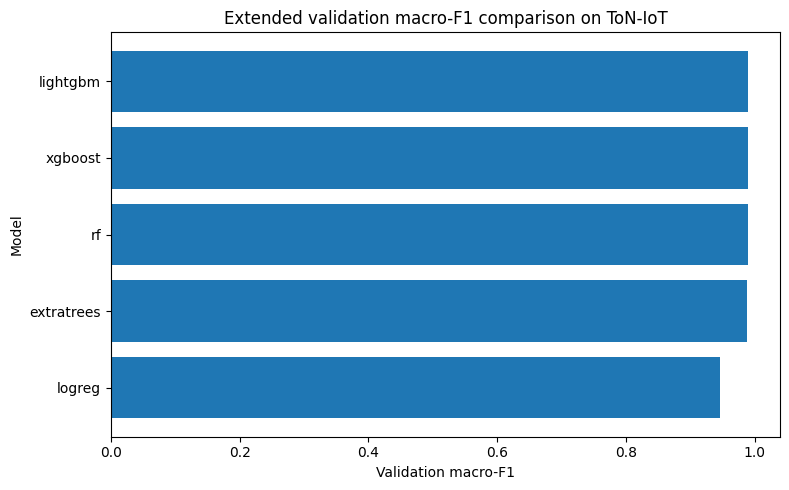

Saved: multiclass_model_selection_outputs\figures\ton_iot_extended_validation_macro_f1_comparison.png

[Fitting strong baselines on TRAIN+VAL]
Fitting final strong baseline on TRAIN+VAL: xgboost
Fitting final strong baseline on TRAIN+VAL: lightgbm

Updated final models:
['logreg', 'rf', 'extratrees', 'xgboost', 'lightgbm']

[Extended selected best model]
Best model after adding strong baselines: lightgbm

STEP 6 completed successfully.


In [39]:

# STEP 6: Add strong tabular baseline (XGBoost / LightGBM)

import time
import json
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

print("=" * 80)
print("STEP 6: STRONG TABULAR BASELINE")
print("=" * 80)

assert "scaled_preprocessor" in globals()
assert "tree_preprocessor" in globals()
assert "X_train_raw" in globals()
assert "X_val_raw" in globals()
assert "y_train" in globals()
assert "y_val" in globals()
assert "scores_df" in globals()

baseline_models = {}


# Try XGBoost first
xgb_available = False
lgbm_available = False

try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception as e:
    print(f"XGBoost not available: {e}")

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except Exception as e:
    print(f"LightGBM not available: {e}")

if xgb_available:
    baseline_models["xgboost"] = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("clf", XGBClassifier(
            n_estimators=250,
            max_depth=8,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ))
    ])

if lgbm_available:
    baseline_models["lightgbm"] = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("clf", LGBMClassifier(
            n_estimators=250,
            learning_rate=0.1,
            num_leaves=31,
            objective="multiclass",
            random_state=42,
            n_jobs=-1,
            class_weight="balanced",
            verbose=-1
        ))
    ])

if len(baseline_models) == 0:
    raise ImportError("Neither XGBoost nor LightGBM is available in this environment.")
    
# if len(baseline_models) == 0:
#     raise ImportError("Neither XGBoost nor LightGBM is available in this environment.")

def evaluate_multiclass_model_simple(model, X_tr, y_tr, X_va, y_va):
    result = {}

    t_fit0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    result["fit_s"] = time.perf_counter() - t_fit0

    t_pred0 = time.perf_counter()
    y_pred = model.predict(X_va)
    result["y_pred"] = y_pred
    result["pred_s"] = time.perf_counter() - t_pred0

    result["val_acc"] = accuracy_score(y_va, y_pred)
    result["val_f1_macro"] = f1_score(y_va, y_pred, average="macro", zero_division=0)
    result["val_f1_weighted"] = f1_score(y_va, y_pred, average="weighted", zero_division=0)
    result["val_prec_macro"] = precision_score(y_va, y_pred, average="macro", zero_division=0)
    result["val_rec_macro"] = recall_score(y_va, y_pred, average="macro", zero_division=0)
    result["pred_ms_per_sample"] = 1000 * result["pred_s"] / len(X_va)

    result["val_roc_auc_ovr_macro"] = np.nan
    result["val_roc_auc_ovr_weighted"] = np.nan

    result["y_proba"] = None
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_va)
        result["y_proba"] = y_proba
        result["val_roc_auc_ovr_macro"] = roc_auc_score(
            y_va, y_proba, multi_class="ovr", average="macro"
        )
        result["val_roc_auc_ovr_weighted"] = roc_auc_score(
            y_va, y_proba, multi_class="ovr", average="weighted"
        )

    return result

new_rows = []

for name, model in baseline_models.items():
    print("\n" + "-" * 80)
    print(f"Training strong baseline: {name}")

    res = evaluate_multiclass_model_simple(model, X_train_raw, y_train, X_val_raw, y_val)

    new_rows.append({
        "model": name,
        "val_acc": res["val_acc"],
        "val_f1_macro": res["val_f1_macro"],
        "val_f1_weighted": res["val_f1_weighted"],
        "val_prec_macro": res["val_prec_macro"],
        "val_rec_macro": res["val_rec_macro"],
        "val_roc_auc_ovr_macro": res["val_roc_auc_ovr_macro"],
        "val_roc_auc_ovr_weighted": res["val_roc_auc_ovr_weighted"],
        "fit_s": res["fit_s"],
        "pred_s": res["pred_s"],
        "pred_ms_per_sample": res["pred_ms_per_sample"]
    })

    print(f"Validation Accuracy              : {res['val_acc']:.6f}")
    print(f"Validation F1 Macro              : {res['val_f1_macro']:.6f}")
    print(f"Validation F1 Weighted           : {res['val_f1_weighted']:.6f}")
    print(f"Validation Precision Macro       : {res['val_prec_macro']:.6f}")
    print(f"Validation Recall Macro          : {res['val_rec_macro']:.6f}")
    print(f"Validation ROC-AUC OVR Macro     : {res['val_roc_auc_ovr_macro']:.6f}")
    print(f"Validation ROC-AUC OVR Weighted  : {res['val_roc_auc_ovr_weighted']:.6f}")
    print(f"Fit time (s)                     : {res['fit_s']:.4f}")
    print(f"Predict ms/sample                : {res['pred_ms_per_sample']:.6f}")

scores_df_extended = pd.concat([scores_df, pd.DataFrame(new_rows)], axis=0)
scores_df_extended = scores_df_extended.sort_values(
    by=["val_f1_macro", "val_f1_weighted", "val_roc_auc_ovr_macro", "pred_ms_per_sample"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

print("\n" + "=" * 80)
print("[EXTENDED VALIDATION MODEL COMPARISON TABLE]")
print("=" * 80)
print(scores_df_extended)

# Save extended validation model-comparison figure
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

print("\n[Saving extended validation model-comparison figure]")

plot_df = scores_df_extended.sort_values(by="val_f1_macro", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["model"], plot_df["val_f1_macro"])
plt.xlabel("Validation macro-F1")
plt.ylabel("Model")
plt.title("Extended validation macro-F1 comparison on ToN-IoT")
plt.tight_layout()

extended_fig_path = os.path.join(FIG_DIR, "ton_iot_extended_validation_macro_f1_comparison.png")
plt.savefig(extended_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", extended_fig_path)

OUT_DIR = "multiclass_model_selection_outputs"
scores_df_extended.to_csv(os.path.join(OUT_DIR, "validation_model_comparison_extended.csv"), index=False)

# Fit strong baselines on TRAIN+VAL and add them to final_models
assert "X_trainval_raw" in globals(), "X_trainval_raw not found. Run Step 5 first."
assert "y_trainval" in globals(), "y_trainval not found. Run Step 5 first."
assert "final_models" in globals(), "final_models not found. Run Step 5 first."

print("\n[Fitting strong baselines on TRAIN+VAL]")

for name, model in baseline_models.items():
    print(f"Fitting final strong baseline on TRAIN+VAL: {name}")
    m = clone(model)
    m.fit(X_trainval_raw, y_trainval)
    final_models[name] = m

print("\nUpdated final models:")
print(list(final_models.keys()))

best_name_extended = scores_df_extended.loc[0, "model"]

print("\n[Extended selected best model]")
print("Best model after adding strong baselines:", best_name_extended)

best_name = best_name_extended
best_model = final_models[best_name]

print("\nSTEP 6 completed successfully.")

In [40]:
# STEP 6D: Finalize best multiclass model after all baselines

import os
import json
import time
import pandas as pd
from sklearn.base import clone

print("=" * 80)
print("STEP 6D: FINALIZE BEST MULTICLASS MODEL")
print("=" * 80)

required_vars = [
    "scores_df_extended",
    "models",
    "baseline_models",
    "X_train_raw", "X_val_raw", "X_test_raw",
    "y_train", "y_val"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found."

# merge baseline models into main model pool
for k, v in baseline_models.items():
    models[k] = v

best_name_extended = scores_df_extended.loc[0, "model"]
best_model = clone(models[best_name_extended])

print("\n[Selected best model after full comparison]")
print("Best model name:", best_name_extended)

X_trainval_raw = pd.concat([X_train_raw, X_val_raw], axis=0).reset_index(drop=True)
y_trainval = pd.concat([pd.Series(y_train), pd.Series(y_val)], axis=0).reset_index(drop=True)

t0 = time.perf_counter()
best_model.fit(X_trainval_raw, y_trainval)
refit_time_extended = time.perf_counter() - t0

print(f"Refit time on TRAIN+VAL (s): {refit_time_extended:.4f}")

final_models = {}
for name, model in models.items():
    m = clone(model)
    print(f"Fitting final model on TRAIN+VAL: {name}")
    m.fit(X_trainval_raw, y_trainval)
    final_models[name] = m

print("\n[Final model pool]")
print(list(final_models.keys()))

OUT_DIR = "multiclass_model_selection_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

step6d_summary = {
    "best_model_after_full_comparison": best_name_extended,
    "candidate_models_final": list(final_models.keys()),
    "refit_time_seconds": float(refit_time_extended),
    "trainval_shape": list(X_trainval_raw.shape),
    "test_shape": list(X_test_raw.shape)
}

with open(os.path.join(OUT_DIR, "step6d_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step6d_summary, f, indent=2)

print("\n[Saved updated model-selection summary]")
print(json.dumps(step6d_summary, indent=2))

print("\nSTEP 6D completed successfully.")

STEP 6D: FINALIZE BEST MULTICLASS MODEL

[Selected best model after full comparison]
Best model name: lightgbm
Refit time on TRAIN+VAL (s): 7.5863
Fitting final model on TRAIN+VAL: logreg
Fitting final model on TRAIN+VAL: rf
Fitting final model on TRAIN+VAL: extratrees
Fitting final model on TRAIN+VAL: xgboost
Fitting final model on TRAIN+VAL: lightgbm

[Final model pool]
['logreg', 'rf', 'extratrees', 'xgboost', 'lightgbm']

[Saved updated model-selection summary]
{
  "best_model_after_full_comparison": "lightgbm",
  "candidate_models_final": [
    "logreg",
    "rf",
    "extratrees",
    "xgboost",
    "lightgbm"
  ],
  "refit_time_seconds": 7.586259100004099,
  "trainval_shape": [
    151546,
    40
  ],
  "test_shape": [
    37887,
    40
  ]
}

STEP 6D completed successfully.


STEP 7: MULTICLASS TEST EVALUATION + FINAL MODEL COMPARISON

[Best model entering test evaluation]
Best model name: lightgbm

[Test set shape]
(37887, 40)

[Test class names]
['backdoor', 'ddos', 'dos', 'injection', 'normal', 'password', 'ransomware', 'scanning', 'xss']

[TEST RESULTS: BEST MODEL = lightgbm]
Test Accuracy                 : 0.991818
Test F1 Macro                 : 0.990677
Test F1 Weighted              : 0.991824
Test Precision Macro          : 0.990475
Test Recall Macro             : 0.990910
Test ROC-AUC OVR Macro        : 0.999909
Test ROC-AUC OVR Weighted     : 0.999921
Top-2 Accuracy                : 0.998020
Top-3 Accuracy                : 0.999499
Predict time total (s)        : 0.804031
Predict latency (ms/sample)   : 0.021222
Predict_proba total (s)       : 0.799012
Predict_proba (ms/sample)     : 0.021089

[TEST CLASSIFICATION REPORT: lightgbm]
              precision    recall  f1-score   support

    backdoor     1.0000    0.9997    0.9999      3742
        

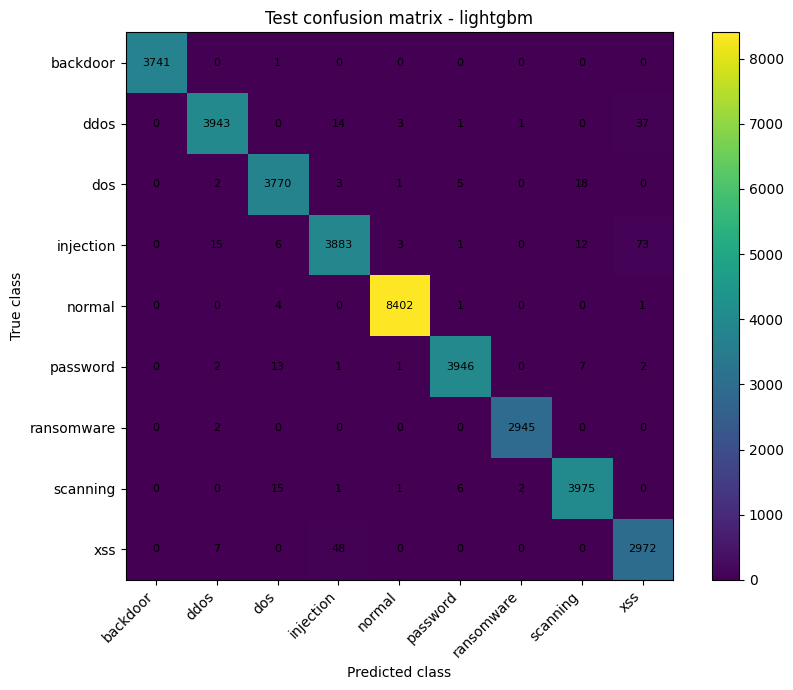

Saved: multiclass_test_evaluation_outputs\figures\test_confusion_matrix_lightgbm.png


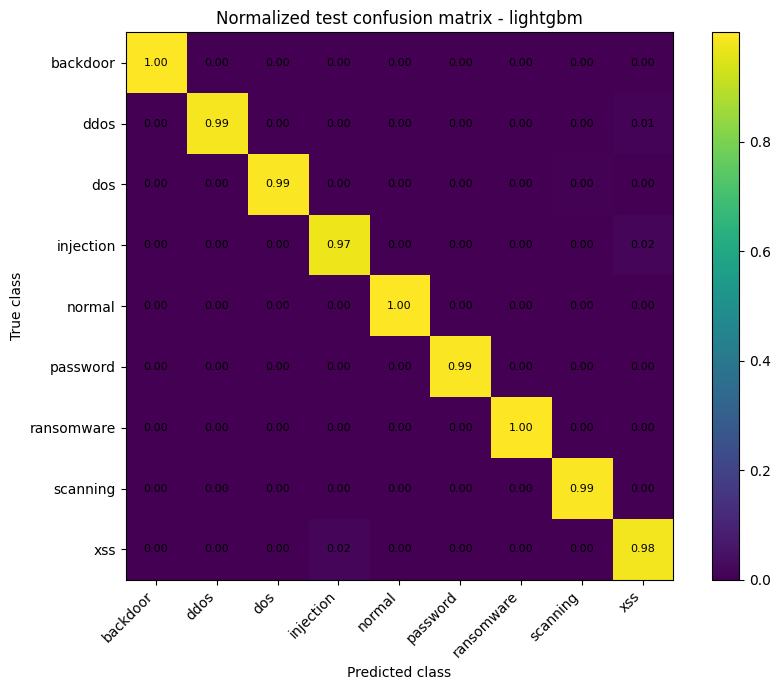

Saved: multiclass_test_evaluation_outputs\figures\test_confusion_matrix_normalized_lightgbm.png

[Per-class performance table]
   class_name  precision    recall  f1_score  support
0    backdoor   1.000000  0.999733  0.999866   3742.0
1  ransomware   0.998982  0.999321  0.999152   2947.0
2      normal   0.998930  0.999286  0.999108   8408.0
3    password   0.996465  0.993454  0.994957   3972.0
4    scanning   0.990778  0.993750  0.992262   4000.0
5         dos   0.989761  0.992366  0.991062   3799.0
6        ddos   0.992949  0.985996  0.989460   3999.0
7   injection   0.983038  0.972452  0.977716   3993.0
8         xss   0.963371  0.981830  0.972513   3027.0

Evaluating final model on test: logreg

Evaluating final model on test: rf

Evaluating final model on test: extratrees

Evaluating final model on test: xgboost

Evaluating final model on test: lightgbm

[Saving test predictions for statistical testing]
Saved: multiclass_test_evaluation_outputs\predictions\ton_iot_test_predictions_

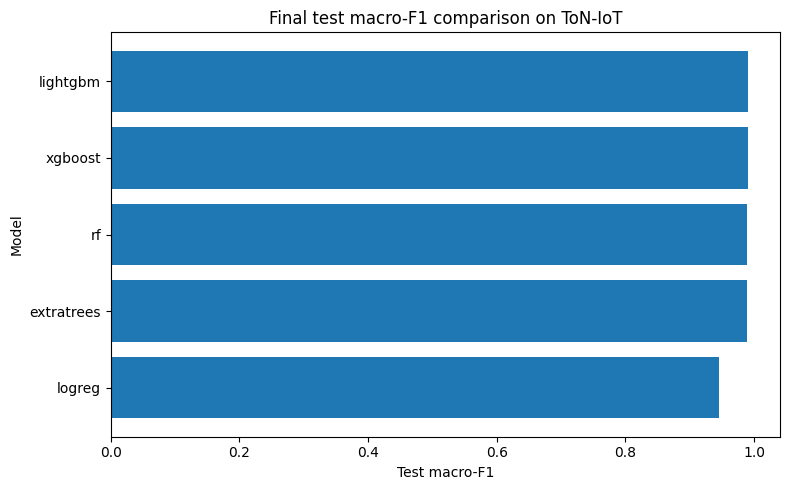

Saved: multiclass_test_evaluation_outputs\figures\ton_iot_test_macro_f1_comparison.png

[Compact ready summary table]
        model  test_acc  test_f1_macro  test_f1_weighted  test_roc_auc_ovr_macro  pred_ms_per_sample
0    lightgbm  0.991818       0.990677          0.991824                0.999909            0.021301
1     xgboost  0.991633       0.990571          0.991638                0.999912            0.012439
2          rf  0.990445       0.989228          0.990450                0.999552            0.011092
3  extratrees  0.989601       0.988294          0.989607                0.999343            0.012969
4      logreg  0.950511       0.944718          0.950557                0.995456            0.005920

[Hardest classes by F1]
   class_name  precision    recall  f1_score  support
0         xss   0.963371  0.981830  0.972513   3027.0
1   injection   0.983038  0.972452  0.977716   3993.0
2        ddos   0.992949  0.985996  0.989460   3999.0
3         dos   0.989761  0.992366 

In [41]:
# STEP 7: Multiclass test evaluation + comparison of final models

import os
import json
import time
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    top_k_accuracy_score
)

print("=" * 80)
print("STEP 7: MULTICLASS TEST EVALUATION + FINAL MODEL COMPARISON")
print("=" * 80)

t0 = time.perf_counter()

OUT_DIR = "multiclass_test_evaluation_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

PRED_DIR = os.path.join(OUT_DIR, "predictions")
os.makedirs(PRED_DIR, exist_ok=True)

# Safety checks
required_vars = [
    "best_model", "final_models",
    "X_test_raw", "y_test", "inv_label_mapping"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Step 3 first."

# final best model name after all baselines
if "best_name_extended" in globals():
    best_name_final = best_name_extended
elif "scores_df_extended" in globals():
    best_name_final = scores_df_extended.loc[0, "model"]
else:
    best_name_final = "best_model"

class_ids = sorted(inv_label_mapping.keys())
class_names = [inv_label_mapping[i] for i in class_ids]

print("\n[Best model entering test evaluation]")
print("Best model name:", best_name_final)

print("\n[Test set shape]")
print(X_test_raw.shape)

print("\n[Test class names]")
print(class_names)


# Helper: evaluate a multiclass model on test
def evaluate_multiclass_test(model, X, y, class_ids):
    result = {}

    # predict labels
    t_pred0 = time.perf_counter()
    y_pred = model.predict(X)
    pred_s = time.perf_counter() - t_pred0

    result["y_pred"] = y_pred
    result["pred_time_s"] = pred_s
    result["pred_ms_per_sample"] = 1000 * pred_s / len(X)

    # basic metrics
    result["test_acc"] = accuracy_score(y, y_pred)
    result["test_f1_macro"] = f1_score(y, y_pred, average="macro", zero_division=0)
    result["test_f1_weighted"] = f1_score(y, y_pred, average="weighted", zero_division=0)
    result["test_prec_macro"] = precision_score(y, y_pred, average="macro", zero_division=0)
    result["test_rec_macro"] = recall_score(y, y_pred, average="macro", zero_division=0)

    # confusion matrix
    result["cm"] = confusion_matrix(y, y_pred, labels=class_ids)

    # probability-based metrics
    result["y_proba"] = None
    result["proba_time_s"] = np.nan
    result["proba_ms_per_sample"] = np.nan
    result["test_roc_auc_ovr_macro"] = np.nan
    result["test_roc_auc_ovr_weighted"] = np.nan
    result["top2_acc"] = np.nan
    result["top3_acc"] = np.nan

    if hasattr(model, "predict_proba"):
        try:
            t_proba0 = time.perf_counter()
            y_proba = model.predict_proba(X)
            proba_s = time.perf_counter() - t_proba0

            result["y_proba"] = y_proba
            result["proba_time_s"] = proba_s
            result["proba_ms_per_sample"] = 1000 * proba_s / len(X)

            result["test_roc_auc_ovr_macro"] = roc_auc_score(
                y, y_proba, multi_class="ovr", average="macro"
            )
            result["test_roc_auc_ovr_weighted"] = roc_auc_score(
                y, y_proba, multi_class="ovr", average="weighted"
            )

            result["top2_acc"] = top_k_accuracy_score(y, y_proba, k=2, labels=class_ids)
            result["top3_acc"] = top_k_accuracy_score(y, y_proba, k=3, labels=class_ids)

        except Exception as e:
            print(f"Probability-based metric warning: {e}")

    return result


# Evaluate best model on test
best_test_res = evaluate_multiclass_test(best_model, X_test_raw, y_test, class_ids)

print("\n" + "=" * 80)
print(f"[TEST RESULTS: BEST MODEL = {best_name_final}]")
print("=" * 80)
print(f"Test Accuracy                 : {best_test_res['test_acc']:.6f}")
print(f"Test F1 Macro                 : {best_test_res['test_f1_macro']:.6f}")
print(f"Test F1 Weighted              : {best_test_res['test_f1_weighted']:.6f}")
print(f"Test Precision Macro          : {best_test_res['test_prec_macro']:.6f}")
print(f"Test Recall Macro             : {best_test_res['test_rec_macro']:.6f}")
print(f"Test ROC-AUC OVR Macro        : {best_test_res['test_roc_auc_ovr_macro']:.6f}")
print(f"Test ROC-AUC OVR Weighted     : {best_test_res['test_roc_auc_ovr_weighted']:.6f}")
print(f"Top-2 Accuracy                : {best_test_res['top2_acc']:.6f}")
print(f"Top-3 Accuracy                : {best_test_res['top3_acc']:.6f}")
print(f"Predict time total (s)        : {best_test_res['pred_time_s']:.6f}")
print(f"Predict latency (ms/sample)   : {best_test_res['pred_ms_per_sample']:.6f}")
print(f"Predict_proba total (s)       : {best_test_res['proba_time_s']:.6f}")
print(f"Predict_proba (ms/sample)     : {best_test_res['proba_ms_per_sample']:.6f}")


# Best model classification report
print("\n" + "=" * 80)
print(f"[TEST CLASSIFICATION REPORT: {best_name_final}]")
print("=" * 80)
print(classification_report(
    y_test,
    best_test_res["y_pred"],
    target_names=class_names,
    digits=4,
    zero_division=0
))


# Best model confusion matrix
cm_test = best_test_res["cm"]
cm_test_df = pd.DataFrame(
    cm_test,
    index=[f"true_{name}" for name in class_names],
    columns=[f"pred_{name}" for name in class_names]
)

print("\n[Best model test confusion matrix]")
print(cm_test_df)


# Save test confusion-matrix figures
print("\n[Saving test confusion-matrix figures]")

plt.figure(figsize=(9, 7))
plt.imshow(cm_test, interpolation="nearest")
plt.title(f"Test confusion matrix - {best_name_final}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        plt.text(j, i, str(cm_test[i, j]), ha="center", va="center", fontsize=8)

plt.tight_layout()

cm_test_fig_path = os.path.join(FIG_DIR, f"test_confusion_matrix_{best_name_final}.png")
plt.savefig(cm_test_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_test_fig_path)


cm_test_norm = cm_test.astype(float) / np.maximum(cm_test.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(9, 7))
plt.imshow(cm_test_norm, interpolation="nearest")
plt.title(f"Normalized test confusion matrix - {best_name_final}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(cm_test_norm.shape[0]):
    for j in range(cm_test_norm.shape[1]):
        plt.text(j, i, f"{cm_test_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()

cm_test_norm_fig_path = os.path.join(FIG_DIR, f"test_confusion_matrix_normalized_{best_name_final}.png")
plt.savefig(cm_test_norm_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_test_norm_fig_path)


# Per-class metrics table
report_dict = classification_report(
    y_test,
    best_test_res["y_pred"],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class_rows = []
for cname in class_names:
    per_class_rows.append({
        "class_name": cname,
        "precision": report_dict[cname]["precision"],
        "recall": report_dict[cname]["recall"],
        "f1_score": report_dict[cname]["f1-score"],
        "support": report_dict[cname]["support"]
    })

per_class_df = pd.DataFrame(per_class_rows).sort_values(by="f1_score", ascending=False).reset_index(drop=True)

print("\n[Per-class performance table]")
print(per_class_df)

test_predictions = {}
test_probabilities = {}

# Compare all final models on test
compare_rows = []

for name, model in final_models.items():
    print(f"\nEvaluating final model on test: {name}")
    res = evaluate_multiclass_test(model, X_test_raw, y_test, class_ids)
    test_predictions[name] = res["y_pred"]
    test_probabilities[name] = res["y_proba"]

    compare_rows.append({
        "model": name,
        "test_acc": res["test_acc"],
        "test_f1_macro": res["test_f1_macro"],
        "test_f1_weighted": res["test_f1_weighted"],
        "test_prec_macro": res["test_prec_macro"],
        "test_rec_macro": res["test_rec_macro"],
        "test_roc_auc_ovr_macro": res["test_roc_auc_ovr_macro"],
        "test_roc_auc_ovr_weighted": res["test_roc_auc_ovr_weighted"],
        "top2_acc": res["top2_acc"],
        "top3_acc": res["top3_acc"],
        "pred_time_s": res["pred_time_s"],
        "pred_ms_per_sample": res["pred_ms_per_sample"],
        "proba_time_s": res["proba_time_s"],
        "proba_ms_per_sample": res["proba_ms_per_sample"]
    })

compare_test_df = pd.DataFrame(compare_rows).sort_values(
    by=["test_f1_macro", "test_f1_weighted", "test_roc_auc_ovr_macro", "pred_ms_per_sample"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

# Save test predictions for later statistical testing
print("\n[Saving test predictions for statistical testing]")

test_pred_df = pd.DataFrame({
    "y_true": pd.Series(y_test).astype(int)
})

for name, pred in test_predictions.items():
    test_pred_df[f"pred_{name}"] = pd.Series(pred).astype(int)

test_pred_path = os.path.join(PRED_DIR, "ton_iot_test_predictions_all_models.csv")
test_pred_df.to_csv(test_pred_path, index=False)

print("Saved:", test_pred_path)

print("\n" + "=" * 80)
print("[TEST MODEL COMPARISON TABLE]")
print("=" * 80)
print(compare_test_df)

# Save final test model-comparison figure
print("\n[Saving test model-comparison figure]")

plot_df = compare_test_df.sort_values(by="test_f1_macro", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["model"], plot_df["test_f1_macro"])
plt.xlabel("Test macro-F1")
plt.ylabel("Model")
plt.title("Final test macro-F1 comparison on ToN-IoT")
plt.tight_layout()

test_comparison_fig_path = os.path.join(FIG_DIR, "ton_iot_test_macro_f1_comparison.png")
plt.savefig(test_comparison_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", test_comparison_fig_path)

# Compact summary 
summary_table = compare_test_df[[
    "model",
    "test_acc",
    "test_f1_macro",
    "test_f1_weighted",
    "test_roc_auc_ovr_macro",
    "pred_ms_per_sample"
]].copy()

print("\n[Compact ready summary table]")
print(summary_table)


# Hardest classes analysis
hardest_classes_df = per_class_df.sort_values(by="f1_score", ascending=True).reset_index(drop=True)

print("\n[Hardest classes by F1]")
print(hardest_classes_df)


# # Save artifacts
# OUT_DIR = "multiclass_test_evaluation_outputs"
# os.makedirs(OUT_DIR, exist_ok=True)

cm_test_df.to_csv(os.path.join(OUT_DIR, f"test_confusion_matrix_{best_name_final}.csv"))
per_class_df.to_csv(os.path.join(OUT_DIR, f"test_per_class_metrics_{best_name_final}.csv"), index=False)
compare_test_df.to_csv(os.path.join(OUT_DIR, "test_model_comparison.csv"), index=False)
summary_table.to_csv(os.path.join(OUT_DIR, "test_summary_table.csv"), index=False)
hardest_classes_df.to_csv(os.path.join(OUT_DIR, f"hardest_classes_{best_name_final}.csv"), index=False)

step7_summary = {
    "best_model": best_name_final,
    "test_shape": list(X_test_raw.shape),
    "class_names": class_names,
    "best_model_test_metrics": {
        "accuracy": float(best_test_res["test_acc"]),
        "f1_macro": float(best_test_res["test_f1_macro"]),
        "f1_weighted": float(best_test_res["test_f1_weighted"]),
        "precision_macro": float(best_test_res["test_prec_macro"]),
        "recall_macro": float(best_test_res["test_rec_macro"]),
        "roc_auc_ovr_macro": float(best_test_res["test_roc_auc_ovr_macro"]),
        "roc_auc_ovr_weighted": float(best_test_res["test_roc_auc_ovr_weighted"]),
        "top2_accuracy": float(best_test_res["top2_acc"]),
        "top3_accuracy": float(best_test_res["top3_acc"]),
        "pred_ms_per_sample": float(best_test_res["pred_ms_per_sample"]),
        "proba_ms_per_sample": float(best_test_res["proba_ms_per_sample"])
    }
}

with open(os.path.join(OUT_DIR, "step7_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step7_summary, f, indent=2)

t_step4 = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 7 summary]")
print(json.dumps(step7_summary, indent=2))

print(f"\nSTEP 7 completed successfully in {t_step4:.4f} seconds.")

STEP 8: MULTICLASS GLOBAL EXPLAINABILITY

[Best model for XAI]
Model: lightgbm

[Recovered transformed feature space]
Number of transformed features: 154
First 50 transformed feature names:
['duration__log1p', 'src_bytes__log1p', 'dst_bytes__log1p', 'missed_bytes__log1p', 'src_pkts__log1p', 'src_ip_bytes__log1p', 'dst_pkts__log1p', 'dst_ip_bytes__log1p', 'http_request_body_len__log1p', 'http_response_body_len__log1p', 'src_port__scaled', 'dst_port__scaled', 'dns_qclass__scaled', 'dns_qtype__scaled', 'dns_rcode__scaled', 'http_status_code__scaled', 'http_user_agent_Comos/0.9_(robot@xyleme.com)', 'http_user_agent_DAFUPnP', 'http_user_agent_DataCha0s/2.0', 'http_user_agent_Debian APT-HTTP/1.3 (1.7.4)', 'http_user_agent_MICROSOFT_DEVICE_METADATA_RETRIEVAL_CLIENT', 'http_user_agent_MISSING_TOKEN', 'http_user_agent_Microsoft BITS/7.8', 'http_user_agent_Microsoft NCSI', 'http_user_agent_Microsoft-CryptoAPI/10.0', 'http_user_agent_Microsoft-Delivery-Optimization/10.0', 'http_user_agent_Microso

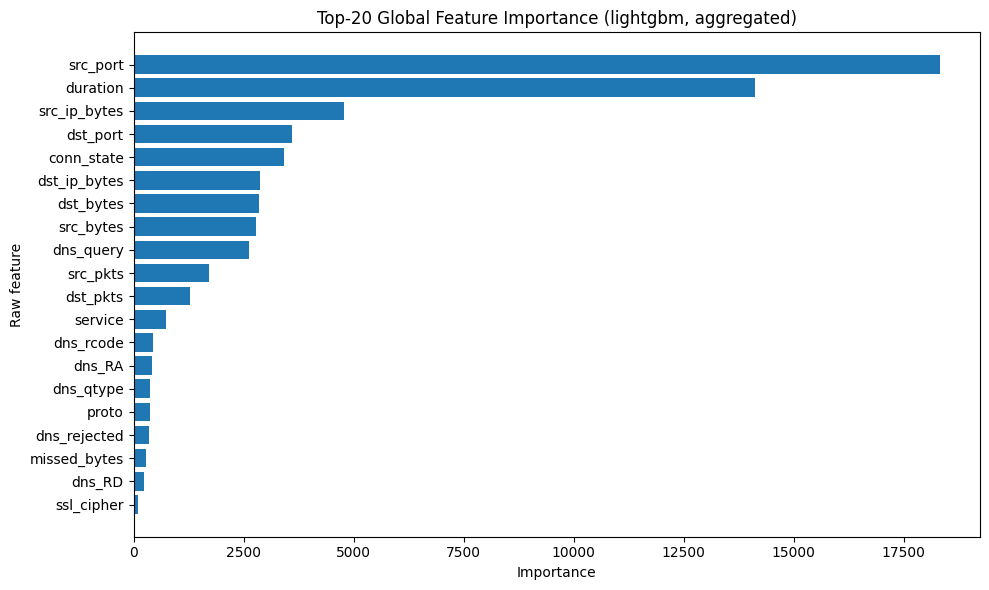

Saved: multiclass_global_xai_outputs\figures\top_20_builtin_importance_lightgbm.png


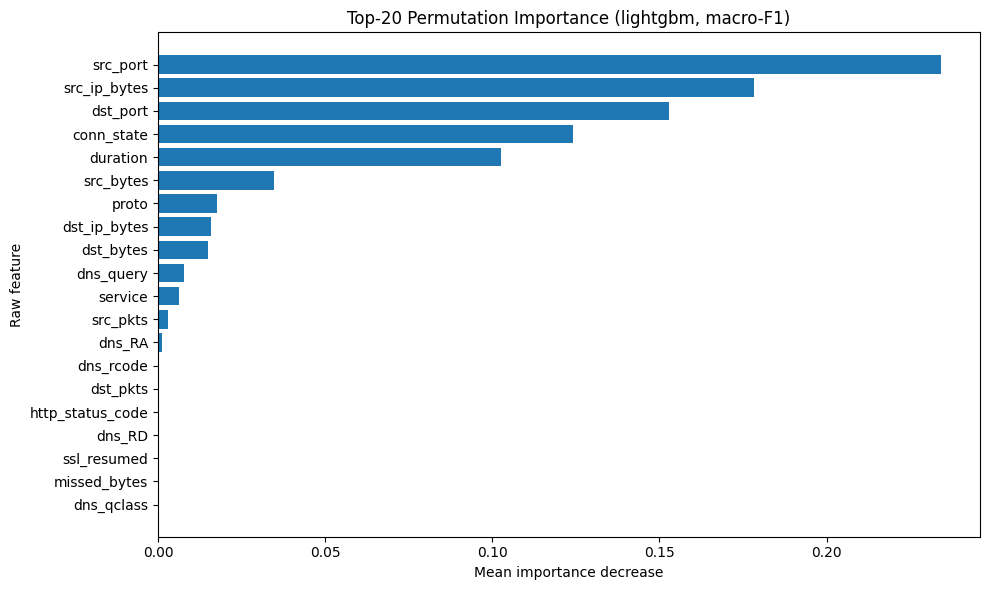

Saved: multiclass_global_xai_outputs\figures\top_20_permutation_importance_lightgbm.png

[Top 25 consensus-important raw features]
               raw_feature  importance  perm_importance_mean  perm_importance_std  builtin_rank  perm_rank  rank_sum
0                 src_port       18319              0.234209             0.002384           1.0        1.0       2.0
1             src_ip_bytes        4783              0.178271             0.001586           3.0        2.0       5.0
2                 duration       14127              0.102645             0.002424           2.0        5.0       7.0
3                 dst_port        3597              0.152772             0.002160           4.0        3.0       7.0
4               conn_state        3417              0.124142             0.002169           5.0        4.0       9.0
5             dst_ip_bytes        2876              0.015916             0.000797           6.0        8.0      14.0
6                src_bytes        2786            

In [42]:

# STEP 8: Multiclass global explainability
# - built-in importance when available
# - permutation importance
# - transformed feature-name recovery
# - final-model compatible (LightGBM / XGBoost / RF / ExtraTrees / LogReg)

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

print("=" * 80)
print("STEP 8: MULTICLASS GLOBAL EXPLAINABILITY")
print("=" * 80)

t0 = time.perf_counter()

OUT_DIR = "multiclass_global_xai_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Safety checks
required_vars = [
    "best_model",
    "X_trainval_raw", "X_test_raw", "y_test",
    "numeric_cols", "log_transform_numeric_cols", "non_log_numeric_cols",
    "low_mid_card_cat_cols", "high_card_cat_cols"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Steps 2-4 first."

if "best_name_extended" in globals():
    best_name_final = best_name_extended
elif "scores_df_extended" in globals():
    best_name_final = scores_df_extended.loc[0, "model"]
else:
    best_name_final = "best_model"

print("\n[Best model for XAI]")
print("Model:", best_name_final)


# Get fitted pipeline parts
preprocessor = best_model.named_steps["preprocessor"]
clf = best_model.named_steps["clf"]


# Recover transformed feature names

def get_transformed_feature_names(preprocessor, low_mid_cat_cols, high_card_cat_cols,
                                  log_num_cols, plain_num_cols):
    feature_names = []

    # 1) log numeric columns
    feature_names.extend([f"{c}__log1p" for c in log_num_cols])

    # 2) plain numeric columns
    feature_names.extend([f"{c}__scaled" for c in plain_num_cols])

    # 3) one-hot categorical columns
    if len(low_mid_cat_cols) > 0:
        ohe = preprocessor.named_transformers_["lowmid_cat"].named_steps["onehot"]
        ohe_names = ohe.get_feature_names_out(low_mid_cat_cols).tolist()
        feature_names.extend(ohe_names)

    # 4) high-cardinality frequency encoded columns
    if len(high_card_cat_cols) > 0:
        feature_names.extend([f"{c}__freq" for c in high_card_cat_cols])

    return feature_names

transformed_feature_names = get_transformed_feature_names(
    preprocessor=preprocessor,
    low_mid_cat_cols=low_mid_card_cat_cols,
    high_card_cat_cols=high_card_cat_cols,
    log_num_cols=log_transform_numeric_cols,
    plain_num_cols=non_log_numeric_cols
)

print("\n[Recovered transformed feature space]")
print("Number of transformed features:", len(transformed_feature_names))
print("First 50 transformed feature names:")
print(transformed_feature_names[:50])


# Built-in model importance
# Supports:
# - tree models via feature_importances_
# - logistic regression via absolute coefficients

builtin_importance_df = None

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_

    if len(importances) != len(transformed_feature_names):
        print("\nFeature-name length mismatch detected.")
        print("Length of importances:", len(importances))
        print("Length of recovered feature names:", len(transformed_feature_names))
        transformed_feature_names = [f"feature_{i}" for i in range(len(importances))]
    builtin_importance_df = pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

    print("\n[Top 25 built-in global feature importances]")
    print(builtin_importance_df.head(25))

elif hasattr(clf, "coef_"):
    coef = clf.coef_
    if coef.ndim == 2:
        # multiclass: aggregate absolute coefficients across classes
        coef_abs = np.mean(np.abs(coef), axis=0)
    else:
        coef_abs = np.abs(coef)

    builtin_importance_df = pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": coef_abs
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)

    print("\n[Top 25 coefficient-based global importances]")
    print(builtin_importance_df.head(25))

else:
    print("\nBuilt-in feature importance is not available for this model.")


# Aggregate transformed importances back to original raw features
def map_transformed_to_raw_feature_name(fname):
    if fname.endswith("__log1p"):
        return fname.replace("__log1p", "")
    if fname.endswith("__scaled"):
        return fname.replace("__scaled", "")
    if fname.endswith("__freq"):
        return fname.replace("__freq", "")

    # one-hot names
    all_candidate_prefixes = low_mid_card_cat_cols
    for c in sorted(all_candidate_prefixes, key=len, reverse=True):
        if fname.startswith(c + "_"):
            return c
    return fname

aggregated_builtin_df = None
if builtin_importance_df is not None:
    aggregated_builtin_df = builtin_importance_df.copy()
    aggregated_builtin_df["raw_feature"] = aggregated_builtin_df["feature"].apply(map_transformed_to_raw_feature_name)
    aggregated_builtin_df = aggregated_builtin_df.groupby("raw_feature", as_index=False)["importance"].sum()
    aggregated_builtin_df = aggregated_builtin_df.sort_values(by="importance", ascending=False).reset_index(drop=True)

    print("\n[Top 25 aggregated raw-feature importances]")
    print(aggregated_builtin_df.head(25))


# Permutation importance on held-out test subset
# Use macro-F1 because this is multiclass and class balance matters
MAX_PERM_SAMPLES = min(12000, len(X_test_raw))
X_perm = X_test_raw.iloc[:MAX_PERM_SAMPLES].copy()
y_perm = y_test.iloc[:MAX_PERM_SAMPLES].copy() if isinstance(y_test, pd.Series) else pd.Series(y_test[:MAX_PERM_SAMPLES])

print("\n[Permutation importance setup]")
print("Samples used:", len(X_perm))
print("Scoring:", "f1_macro")
print("Repeats:", 5)

t_perm0 = time.perf_counter()
perm = permutation_importance(
    best_model,
    X_perm,
    y_perm,
    scoring="f1_macro",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
t_perm = time.perf_counter() - t_perm0

perm_importance_df = pd.DataFrame({
    "raw_feature": X_perm.columns,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std
}).sort_values(by="perm_importance_mean", ascending=False).reset_index(drop=True)

print("\n[Top 25 permutation importances]")
print(perm_importance_df.head(25))
print(f"\nPermutation importance time (s): {t_perm:.4f}")


# Plot top features
TOPK = 20

if aggregated_builtin_df is not None:
    top_builtin = aggregated_builtin_df.head(TOPK)

    plt.figure(figsize=(10, 6))
    plt.barh(top_builtin["raw_feature"][::-1], top_builtin["importance"][::-1])
    plt.title(f"Top-{TOPK} Global Feature Importance ({best_name_final}, aggregated)")
    plt.xlabel("Importance")
    plt.ylabel("Raw feature")
    plt.tight_layout()

    builtin_fig_path = os.path.join(FIG_DIR, f"top_{TOPK}_builtin_importance_{best_name_final}.png")
    plt.savefig(builtin_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", builtin_fig_path)
    
top_perm = perm_importance_df.head(TOPK)
plt.figure(figsize=(10, 6))
plt.barh(top_perm["raw_feature"][::-1], top_perm["perm_importance_mean"][::-1])
plt.title(f"Top-{TOPK} Permutation Importance ({best_name_final}, macro-F1)")
plt.xlabel("Mean importance decrease")
plt.ylabel("Raw feature")
plt.tight_layout()

perm_fig_path = os.path.join(FIG_DIR, f"top_{TOPK}_permutation_importance_{best_name_final}.png")
plt.savefig(perm_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", perm_fig_path)


# Consensus importance table
if aggregated_builtin_df is not None:
    xai_consensus_df = aggregated_builtin_df.merge(
        perm_importance_df,
        on="raw_feature",
        how="outer"
    ).fillna(0)

    xai_consensus_df["builtin_rank"] = xai_consensus_df["importance"].rank(ascending=False, method="min")
    xai_consensus_df["perm_rank"] = xai_consensus_df["perm_importance_mean"].rank(ascending=False, method="min")
    xai_consensus_df["rank_sum"] = xai_consensus_df["builtin_rank"] + xai_consensus_df["perm_rank"]

    xai_consensus_df = xai_consensus_df.sort_values(
        by=["rank_sum", "importance", "perm_importance_mean"],
        ascending=[True, False, False]
    ).reset_index(drop=True)

    print("\n[Top 25 consensus-important raw features]")
    print(xai_consensus_df.head(25))
else:
    xai_consensus_df = perm_importance_df.copy()


# # Save artifacts
# OUT_DIR = "multiclass_global_xai_outputs"
# os.makedirs(OUT_DIR, exist_ok=True)

# FIG_DIR = os.path.join(OUT_DIR, "figures")
# os.makedirs(FIG_DIR, exist_ok=True)


if builtin_importance_df is not None:
    builtin_importance_df.to_csv(os.path.join(OUT_DIR, "builtin_transformed_feature_importance.csv"), index=False)

if aggregated_builtin_df is not None:
    aggregated_builtin_df.to_csv(os.path.join(OUT_DIR, "builtin_raw_feature_importance.csv"), index=False)

perm_importance_df.to_csv(os.path.join(OUT_DIR, "permutation_importance.csv"), index=False)
xai_consensus_df.to_csv(os.path.join(OUT_DIR, "xai_consensus_importance.csv"), index=False)

step8_summary = {
    "best_model": best_name_final,
    "n_transformed_features": int(len(transformed_feature_names)),
    "permutation_samples_used": int(len(X_perm)),
    "permutation_scoring": "f1_macro",
    "permutation_repeats": 5,
    "permutation_time_seconds": float(t_perm)
}

with open(os.path.join(OUT_DIR, "step8_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step8_summary, f, indent=2)

t_step5a = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 8 summary]")
print(json.dumps(step8_summary, indent=2))

print(f"\nSTEP 8 completed successfully in {t_step5a:.4f} seconds.")

STEP 9: MULTICLASS SHAP ANALYSIS

[Model for SHAP]
Best model: lightgbm

[SHAP sample setup]
Raw sample size: 300
Transformed SHAP matrix shape: (300, 154)
Number of transformed feature names: 154

SHAP computation time (s): 2.6109
Detected SHAP class count: 9

[Top 25 transformed features by global mean |SHAP|]
                  feature  mean_abs_shap
0        dst_port__scaled       1.312284
1        src_port__scaled       0.946184
2     src_ip_bytes__log1p       0.850481
3          conn_state_REJ       0.683123
4         duration__log1p       0.666311
5     dst_ip_bytes__log1p       0.406770
6        src_bytes__log1p       0.313229
7         src_pkts__log1p       0.301548
8        dst_bytes__log1p       0.281332
9               proto_tcp       0.234109
10          conn_state_S1       0.177617
11        dst_pkts__log1p       0.152878
12          conn_state_SF       0.148650
13        dns_query__freq       0.135756
14         conn_state_OTH       0.117771
15  service_MISSING_TOKEN     

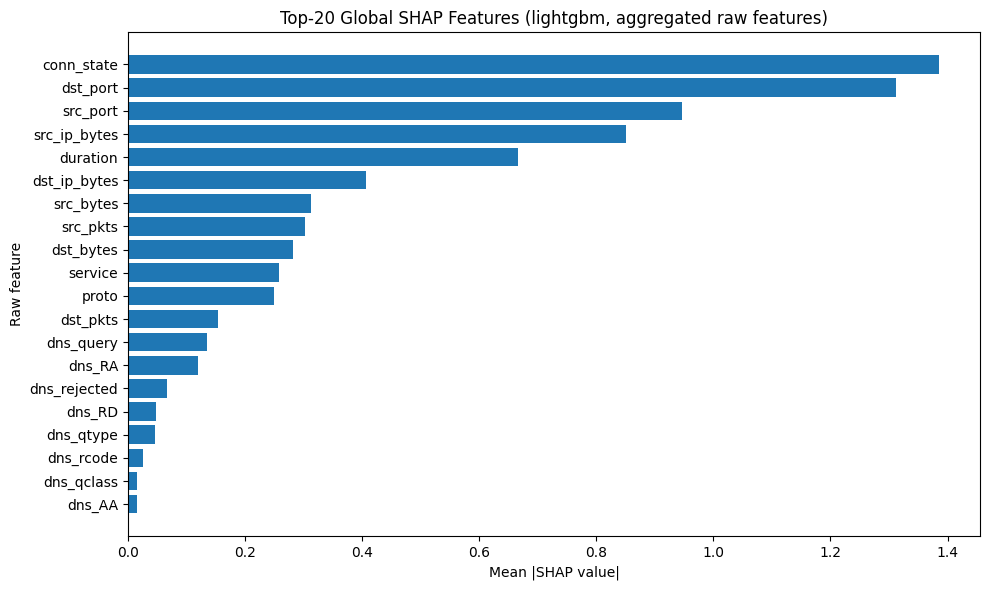

Saved: multiclass_shap_outputs\figures\top_20_global_shap_raw_lightgbm.png

[Representative class summary plot]
Chosen class: xss


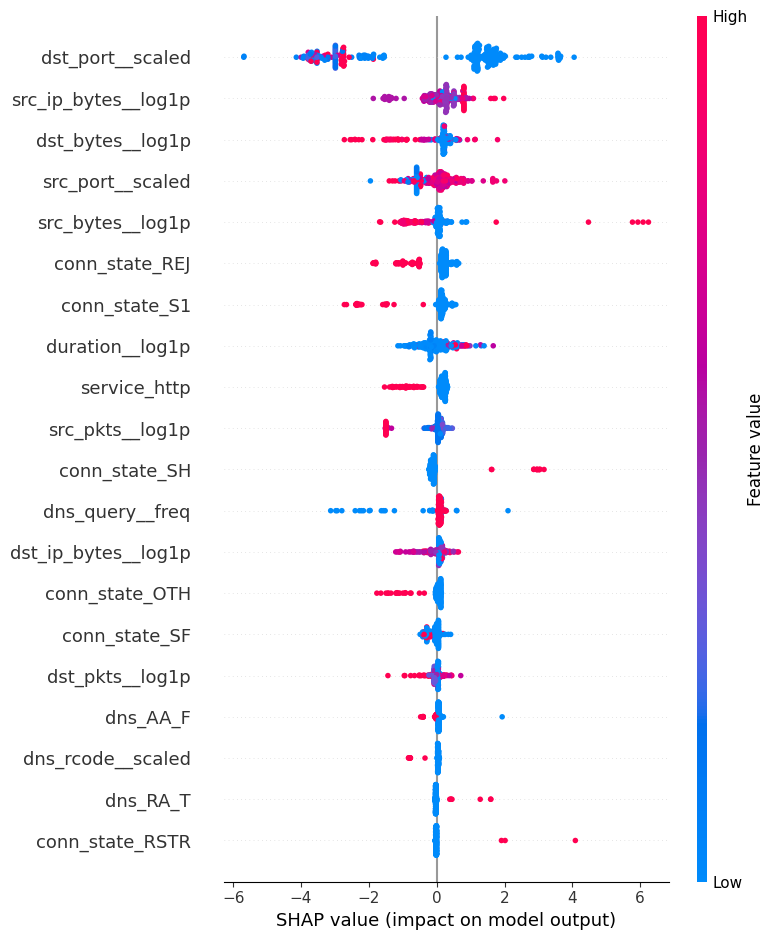

Saved: multiclass_shap_outputs\figures\shap_summary_xss_lightgbm.png

[Saved artifacts]
Directory: multiclass_shap_outputs

[Step 9 summary]
{
  "best_model": "lightgbm",
  "shap_sample_size": 300,
  "transformed_feature_count": 154,
  "class_count": 9,
  "class_names": [
    "backdoor",
    "ddos",
    "dos",
    "injection",
    "normal",
    "password",
    "ransomware",
    "scanning",
    "xss"
  ],
  "representative_class_plot": "xss",
  "shap_time_seconds": 2.6109070000238717
}

STEP 9 completed successfully in 4.5921 seconds.


In [43]:
# STEP 9: Multiclass SHAP analysis for selected final tree model
# - computation-safe version
# - supports LightGBM / XGBoost / RF / ExtraTrees


import os
import json
import time
import numpy as np
import pandas as pd
import shap

print("=" * 80)
print("STEP 9: MULTICLASS SHAP ANALYSIS")
print("=" * 80)

t0 = time.perf_counter()

OUT_DIR = "multiclass_shap_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Safety checks
required_vars = [
    "best_model",
    "X_test_raw", "y_test",
    "inv_label_mapping",
    "transformed_feature_names",
    "low_mid_card_cat_cols"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Step 5A first."

if "best_name_extended" in globals():
    best_name_final = best_name_extended
elif "scores_df_extended" in globals():
    best_name_final = scores_df_extended.loc[0, "model"]
else:
    best_name_final = "best_model"

if best_name_final not in ["lightgbm", "xgboost", "rf", "extratrees"]:
    raise ValueError(f"SHAP block currently expects a tree-based final model, got: {best_name_final}")

print("\n[Model for SHAP]")
print("Best model:", best_name_final)


# Get fitted preprocessor and classifier
preprocessor = best_model.named_steps["preprocessor"]
clf = best_model.named_steps["clf"]


# Small sample for SHAP to keep runtime stable
MAX_SHAP_SAMPLES = min(300, len(X_test_raw))
X_shap_raw = X_test_raw.iloc[:MAX_SHAP_SAMPLES].copy()
y_shap = y_test.iloc[:MAX_SHAP_SAMPLES].copy() if isinstance(y_test, pd.Series) else pd.Series(y_test[:MAX_SHAP_SAMPLES])

print("\n[SHAP sample setup]")
print("Raw sample size:", len(X_shap_raw))

# transform using the fitted preprocessor
X_shap_trans = preprocessor.transform(X_shap_raw)

# convert sparse to dense if needed
if hasattr(X_shap_trans, "toarray"):
    X_shap_trans = X_shap_trans.toarray()

X_shap_trans = np.asarray(X_shap_trans)

print("Transformed SHAP matrix shape:", X_shap_trans.shape)
print("Number of transformed feature names:", len(transformed_feature_names))

if X_shap_trans.shape[1] != len(transformed_feature_names):
    print("\nFeature-name mismatch detected.")
    print("Transformed matrix width:", X_shap_trans.shape[1])
    print("Recovered feature-name count:", len(transformed_feature_names))
    print("Using generic transformed feature names for SHAP output.")

    transformed_feature_names = [
        f"feature_{i}" for i in range(X_shap_trans.shape[1])
    ]

# SHAP computation
t_shap0 = time.perf_counter()

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap_trans)

t_shap = time.perf_counter() - t_shap0

print(f"\nSHAP computation time (s): {t_shap:.4f}")


# Normalize SHAP output shape
# Different SHAP versions may return:
# - list of arrays, one per class
# - single 3D array (samples, features, classes)
if isinstance(shap_values, list):
    shap_by_class = [np.asarray(sv) for sv in shap_values]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_by_class = [shap_values[:, :, k] for k in range(shap_values.shape[2])]
else:
    raise ValueError(
        f"Unexpected SHAP output structure: type={type(shap_values)}, "
        f"shape={getattr(shap_values, 'shape', None)}"
    )

n_classes = len(shap_by_class)
print("Detected SHAP class count:", n_classes)

class_names = [inv_label_mapping[i] for i in sorted(inv_label_mapping.keys())]
assert n_classes == len(class_names), \
    f"SHAP class count {n_classes} != label class count {len(class_names)}"


# Global mean absolute SHAP aggregated across all classes
mean_abs_shap_per_class = []
for k, sv in enumerate(shap_by_class):
    mean_abs = np.mean(np.abs(sv), axis=0)
    mean_abs_shap_per_class.append(mean_abs)

mean_abs_shap_per_class = np.vstack(mean_abs_shap_per_class)  # (n_classes, n_features)
global_mean_abs_shap = mean_abs_shap_per_class.mean(axis=0)

global_shap_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "mean_abs_shap": global_mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False).reset_index(drop=True)

print("\n[Top 25 transformed features by global mean |SHAP|]")
print(global_shap_df.head(25))


# Aggregate transformed SHAP back to raw feature level
def map_transformed_to_raw_feature_name(fname):
    if fname.endswith("__log1p"):
        return fname.replace("__log1p", "")
    if fname.endswith("__scaled"):
        return fname.replace("__scaled", "")
    if fname.endswith("__freq"):
        return fname.replace("__freq", "")

    for c in sorted(low_mid_card_cat_cols, key=len, reverse=True):
        if fname.startswith(c + "_"):
            return c
    return fname

global_shap_raw_df = global_shap_df.copy()
global_shap_raw_df["raw_feature"] = global_shap_raw_df["feature"].apply(map_transformed_to_raw_feature_name)
global_shap_raw_df = global_shap_raw_df.groupby("raw_feature", as_index=False)["mean_abs_shap"].sum()
global_shap_raw_df = global_shap_raw_df.sort_values(by="mean_abs_shap", ascending=False).reset_index(drop=True)

print("\n[Top 25 raw features by aggregated global mean |SHAP|]")
print(global_shap_raw_df.head(25))


# Per-class SHAP tables
per_class_shap_tables = {}

for k, cname in enumerate(class_names):
    class_df = pd.DataFrame({
        "feature": transformed_feature_names,
        "mean_abs_shap": mean_abs_shap_per_class[k]
    }).sort_values(by="mean_abs_shap", ascending=False).reset_index(drop=True)

    class_df["raw_feature"] = class_df["feature"].apply(map_transformed_to_raw_feature_name)
    class_raw_df = class_df.groupby("raw_feature", as_index=False)["mean_abs_shap"].sum()
    class_raw_df = class_raw_df.sort_values(by="mean_abs_shap", ascending=False).reset_index(drop=True)

    per_class_shap_tables[cname] = class_raw_df

    print("\n" + "-" * 80)
    print(f"[Top 10 raw SHAP features for class: {cname}]")
    print(class_raw_df.head(10))


# Plot global raw SHAP top features
TOPK = 20
top_global_raw = global_shap_raw_df.head(TOPK)

plt.figure(figsize=(10, 6))
plt.barh(top_global_raw["raw_feature"][::-1], top_global_raw["mean_abs_shap"][::-1])
plt.title(f"Top-{TOPK} Global SHAP Features ({best_name_final}, aggregated raw features)")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Raw feature")
plt.tight_layout()

global_shap_fig_path = os.path.join(FIG_DIR, f"top_{TOPK}_global_shap_raw_{best_name_final}.png")
plt.savefig(global_shap_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", global_shap_fig_path)

# Representative summary plot
# choose one difficult class if available
preferred_class = "xss" if "xss" in class_names else class_names[0]
preferred_idx = class_names.index(preferred_class)

print("\n[Representative class summary plot]")
print("Chosen class:", preferred_class)

try:
    shap.summary_plot(
        shap_by_class[preferred_idx],
        X_shap_trans,
        feature_names=transformed_feature_names,
        show=False,
        max_display=20
    )

    shap_summary_fig_path = os.path.join(
        FIG_DIR,
        f"shap_summary_{preferred_class}_{best_name_final}.png"
    )
    plt.tight_layout()
    plt.savefig(shap_summary_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", shap_summary_fig_path)

except Exception as e:
    print("SHAP summary plot warning:", e)


# # Save artifacts
# OUT_DIR = "multiclass_shap_outputs"
# os.makedirs(OUT_DIR, exist_ok=True)

global_shap_df.to_csv(os.path.join(OUT_DIR, "global_transformed_shap_importance.csv"), index=False)
global_shap_raw_df.to_csv(os.path.join(OUT_DIR, "global_raw_shap_importance.csv"), index=False)

for cname, class_df in per_class_shap_tables.items():
    safe_name = cname.replace("/", "_").replace(" ", "_")
    class_df.to_csv(os.path.join(OUT_DIR, f"shap_raw_importance_{safe_name}.csv"), index=False)

step9_summary = {
    "best_model": best_name_final,
    "shap_sample_size": int(len(X_shap_raw)),
    "transformed_feature_count": int(X_shap_trans.shape[1]),
    "class_count": int(n_classes),
    "class_names": class_names,
    "representative_class_plot": preferred_class,
    "shap_time_seconds": float(t_shap)
}

with open(os.path.join(OUT_DIR, "step9_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step9_summary, f, indent=2)

t_step5b = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 9 summary]")
print(json.dumps(step9_summary, indent=2))

print(f"\nSTEP 9 completed successfully in {t_step5b:.4f} seconds.")

In [44]:
# STEP 10: Statistical comparison of final models
# - McNemar's test on paired test predictions
# - auxiliary Wilcoxon signed-rank test on per-class F1 scores

import os
import json
import time
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support

print("=" * 80)
print("STEP 10: STATISTICAL COMPARISON OF FINAL MODELS")
print("=" * 80)

t0 = time.perf_counter()

try:
    from scipy.stats import binomtest, chi2, wilcoxon
except Exception as e:
    raise ImportError(f"SciPy is required for statistical testing: {e}")


# Safety checks / prediction loading
PRED_PATH = os.path.join(
    "multiclass_test_evaluation_outputs",
    "predictions",
    "ton_iot_test_predictions_all_models.csv"
)

if "test_pred_df" in globals():
    pred_df = test_pred_df.copy()
else:
    assert os.path.exists(PRED_PATH), f"Prediction file not found: {PRED_PATH}"
    pred_df = pd.read_csv(PRED_PATH)

assert "y_true" in pred_df.columns, "Expected column 'y_true' not found."

model_names = [
    c.replace("pred_", "")
    for c in pred_df.columns
    if c.startswith("pred_")
]

print("\n[Available prediction columns]")
print(model_names)

y_true = pred_df["y_true"].astype(int).to_numpy()
class_ids = sorted(np.unique(y_true).tolist())

print("\n[Test sample count]")
print(len(y_true))

print("\n[Class IDs]")
print(class_ids)


# Decide model pairs
candidate_pairs = []

if "compare_test_df" in globals():
    ranked_models = compare_test_df["model"].tolist()
    if len(ranked_models) >= 2:
        candidate_pairs.append((ranked_models[0], ranked_models[1]))
    if len(ranked_models) >= 3:
        candidate_pairs.append((ranked_models[0], ranked_models[2]))
        candidate_pairs.append((ranked_models[1], ranked_models[2]))

model_pairs = [
    ("lightgbm", "xgboost"),
    ("lightgbm", "rf"),
    ("xgboost", "rf"),
    ("lightgbm", "extratrees"),
    ("xgboost", "extratrees")
]

for p in manual_pairs:
    if p[0] in model_names and p[1] in model_names:
        candidate_pairs.append(p)

# remove duplicates while preserving order
seen = set()
model_pairs = []
for a, b in candidate_pairs:
    key = tuple(sorted([a, b]))
    if key not in seen and a in model_names and b in model_names:
        model_pairs.append((a, b))
        seen.add(key)

print("\n[Model pairs selected for statistical comparison]")
print(model_pairs)


# McNemar helper
def mcnemar_exact_from_predictions(y_true, pred_a, pred_b):
    correct_a = pred_a == y_true
    correct_b = pred_b == y_true

    both_correct = int(np.sum(correct_a & correct_b))
    both_wrong = int(np.sum(~correct_a & ~correct_b))

    a_correct_b_wrong = int(np.sum(correct_a & ~correct_b))
    a_wrong_b_correct = int(np.sum(~correct_a & correct_b))

    discordant = a_correct_b_wrong + a_wrong_b_correct

    if discordant == 0:
        exact_p = 1.0
        chi2_stat = 0.0
        chi2_p = 1.0
    else:
        exact_p = binomtest(
            min(a_correct_b_wrong, a_wrong_b_correct),
            n=discordant,
            p=0.5,
            alternative="two-sided"
        ).pvalue

        chi2_stat = (abs(a_correct_b_wrong - a_wrong_b_correct) - 1) ** 2 / discordant
        chi2_p = chi2.sf(chi2_stat, df=1)

    if a_correct_b_wrong > a_wrong_b_correct:
        direction = "model_a_better"
    elif a_correct_b_wrong < a_wrong_b_correct:
        direction = "model_b_better"
    else:
        direction = "tie"

    return {
        "both_correct": both_correct,
        "both_wrong": both_wrong,
        "a_correct_b_wrong": a_correct_b_wrong,
        "a_wrong_b_correct": a_wrong_b_correct,
        "discordant_pairs": discordant,
        "mcnemar_exact_p": exact_p,
        "mcnemar_chi2_stat": chi2_stat,
        "mcnemar_chi2_p": chi2_p,
        "direction": direction
    }


def per_class_f1(y_true, y_pred, class_ids):
    _, _, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_ids,
        zero_division=0
    )
    return f1, support


alpha = 0.05

mcnemar_rows = []
wilcoxon_rows = []

for model_a, model_b in model_pairs:
    pred_a = pred_df[f"pred_{model_a}"].astype(int).to_numpy()
    pred_b = pred_df[f"pred_{model_b}"].astype(int).to_numpy()

    acc_a = accuracy_score(y_true, pred_a)
    acc_b = accuracy_score(y_true, pred_b)

    mc = mcnemar_exact_from_predictions(y_true, pred_a, pred_b)

    mcnemar_rows.append({
        "model_a": model_a,
        "model_b": model_b,
        "accuracy_a": acc_a,
        "accuracy_b": acc_b,
        "accuracy_diff_a_minus_b": acc_a - acc_b,
        "both_correct": mc["both_correct"],
        "both_wrong": mc["both_wrong"],
        "a_correct_b_wrong": mc["a_correct_b_wrong"],
        "a_wrong_b_correct": mc["a_wrong_b_correct"],
        "discordant_pairs": mc["discordant_pairs"],
        "mcnemar_exact_p": mc["mcnemar_exact_p"],
        "mcnemar_chi2_stat": mc["mcnemar_chi2_stat"],
        "mcnemar_chi2_p": mc["mcnemar_chi2_p"],
        "significant_at_0_05": bool(mc["mcnemar_exact_p"] < alpha),
        "direction": mc["direction"]
    })

    # Auxiliary Wilcoxon test on paired per-class F1 values
    f1_a, support = per_class_f1(y_true, pred_a, class_ids)
    f1_b, _ = per_class_f1(y_true, pred_b, class_ids)

    try:
        if np.allclose(f1_a, f1_b):
            w_stat = 0.0
            w_p = 1.0
        else:
            w_stat, w_p = wilcoxon(
                f1_a,
                f1_b,
                zero_method="wilcox",
                alternative="two-sided",
                mode="auto"
            )
    except Exception as e:
        print(f"Wilcoxon warning for {model_a} vs {model_b}: {e}")
        w_stat = np.nan
        w_p = np.nan

    wilcoxon_rows.append({
        "model_a": model_a,
        "model_b": model_b,
        "mean_per_class_f1_a": float(np.mean(f1_a)),
        "mean_per_class_f1_b": float(np.mean(f1_b)),
        "mean_per_class_f1_diff_a_minus_b": float(np.mean(f1_a - f1_b)),
        "wilcoxon_statistic": float(w_stat) if not pd.isna(w_stat) else np.nan,
        "wilcoxon_p": float(w_p) if not pd.isna(w_p) else np.nan,
        "significant_at_0_05": bool(w_p < alpha) if not pd.isna(w_p) else False,
        "n_classes": int(len(class_ids))
    })


mcnemar_df = pd.DataFrame(mcnemar_rows)
wilcoxon_df = pd.DataFrame(wilcoxon_rows)

print("\n" + "=" * 80)
print("[MCNEMAR TEST RESULTS]")
print("=" * 80)
print(mcnemar_df)

print("\n" + "=" * 80)
print("[AUXILIARY WILCOXON TEST RESULTS: PER-CLASS F1]")
print("=" * 80)
print(wilcoxon_df)


# Save artifacts
OUT_DIR = "statistical_test_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

mcnemar_df.to_csv(os.path.join(OUT_DIR, "mcnemar_test_results.csv"), index=False)
wilcoxon_df.to_csv(os.path.join(OUT_DIR, "wilcoxon_per_class_f1_results.csv"), index=False)

step10_summary = {
    "alpha": alpha,
    "prediction_file": PRED_PATH,
    "n_test_samples": int(len(y_true)),
    "models_available": model_names,
    "model_pairs_tested": [list(p) for p in model_pairs],
    "primary_test": "McNemar exact test on paired test-set correctness",
    "auxiliary_test": "Wilcoxon signed-rank test on paired per-class F1 scores"
}

with open(os.path.join(OUT_DIR, "step10_statistical_test_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step10_summary, f, indent=2)

t_step10 = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 10 summary]")
print(json.dumps(step10_summary, indent=2))

print(f"\nSTEP 10 completed successfully in {t_step10:.4f} seconds.")

STEP 10: STATISTICAL COMPARISON OF FINAL MODELS

[Available prediction columns]
['logreg', 'rf', 'extratrees', 'xgboost', 'lightgbm']

[Test sample count]
37887

[Class IDs]
[0, 1, 2, 3, 4, 5, 6, 7, 8]

[Model pairs selected for statistical comparison]
[('lightgbm', 'xgboost'), ('lightgbm', 'rf'), ('xgboost', 'rf'), ('lightgbm', 'extratrees'), ('rf', 'extratrees')]

[MCNEMAR TEST RESULTS]
    model_a     model_b  accuracy_a  accuracy_b  accuracy_diff_a_minus_b  both_correct  both_wrong  a_correct_b_wrong  a_wrong_b_correct  discordant_pairs  mcnemar_exact_p  mcnemar_chi2_stat  \
0  lightgbm     xgboost    0.991818    0.991633                 0.000185         37508         248                 69                 62               131     6.002946e-01           0.274809   
1  lightgbm          rf    0.991818    0.990445                 0.001373         37468         253                109                 57               166     6.647590e-05          15.668675   
2   xgboost          rf   

STEP 11: LEARNING CURVE ANALYSIS ON ToN-IoT

[Learning curve model]
lightgbm

[Learning curve dataset]
X shape: (151546, 40)
y shape: (151546,)
Class distribution:
0    14969
1    15994
2    15193
3    15971
4    33632
5    15889
6    11788
7    16000
8    12110
Name: count, dtype: int64

[Learning curve setup]
Scoring     : f1_macro
CV folds    : 3
Train sizes : [0.1, 0.25, 0.5, 0.75, 1.0]

[Learning curve results]
   train_size  train_f1_macro_mean  train_f1_macro_std  cv_f1_macro_mean  cv_f1_macro_std  fit_time_mean_s  score_time_mean_s
0       10103             0.999802            0.000110          0.981535         0.000330         2.381296           1.022846
1       25257             0.999577            0.000034          0.984713         0.000634         3.829825           1.091032
2       50515             0.999543            0.000022          0.987745         0.000799         4.661279           1.157282
3       75772             0.999417            0.000013          0.988600    

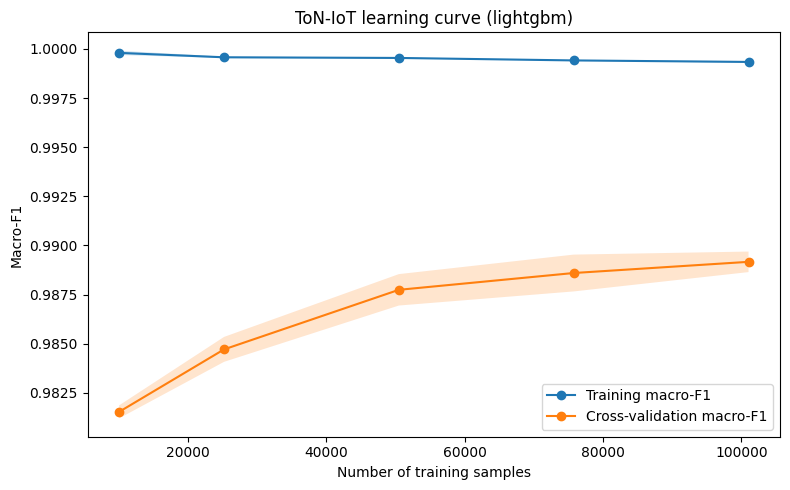


Saved: learning_curve_outputs\figures\ton_iot_learning_curve_lightgbm.png

[Saved artifacts]
Directory: learning_curve_outputs

[Step 11 summary]
{
  "dataset": "ToN-IoT",
  "model": "lightgbm",
  "scoring": "f1_macro",
  "cv_folds": 3,
  "train_sizes": [
    0.1,
    0.25,
    0.5,
    0.75,
    1.0
  ],
  "learning_curve_time_seconds": 101.32941520001623,
  "figure_path": "learning_curve_outputs\\figures\\ton_iot_learning_curve_lightgbm.png"
}

STEP 11 completed successfully in 101.7639 seconds.


In [45]:
# STEP 11: Learning curve analysis for selected ToN-IoT model
# - train size vs training macro-F1
# - train size vs cross-validation macro-F1

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, learning_curve

print("=" * 80)
print("STEP 11: LEARNING CURVE ANALYSIS ON ToN-IoT")
print("=" * 80)

t0 = time.perf_counter()


# Safety checks
required_vars = [
    "final_models",
    "X_trainval_raw",
    "y_trainval"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run previous steps first."

if "best_name_final" in globals():
    lc_model_name = best_name_final
elif "best_name_extended" in globals():
    lc_model_name = best_name_extended
elif "scores_df_extended" in globals():
    lc_model_name = scores_df_extended.loc[0, "model"]
else:
    lc_model_name = list(final_models.keys())[0]

assert lc_model_name in final_models, f"Selected model '{lc_model_name}' not found in final_models."

print("\n[Learning curve model]")
print(lc_model_name)

lc_model = clone(final_models[lc_model_name])

# Suppress verbose model output during repeated learning-curve fits
try:
    if "clf" in lc_model.named_steps:
        clf = lc_model.named_steps["clf"]

        if clf.__class__.__name__ == "LGBMClassifier":
            clf.set_params(verbose=-1, verbosity=-1)

        if clf.__class__.__name__ == "XGBClassifier":
            clf.set_params(verbosity=0)
except Exception as e:
    print(f"Verbosity suppression warning: {e}")
    

X_lc = X_trainval_raw.copy()
y_lc = pd.Series(y_trainval).reset_index(drop=True)

print("\n[Learning curve dataset]")
print("X shape:", X_lc.shape)
print("y shape:", y_lc.shape)
print("Class distribution:")
print(y_lc.value_counts().sort_index())


# Learning curve setup
train_sizes = np.array([0.10, 0.25, 0.50, 0.75, 1.00])

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("\n[Learning curve setup]")
print("Scoring     : f1_macro")
print("CV folds    : 3")
print("Train sizes :", train_sizes.tolist())


t_lc0 = time.perf_counter()

train_sizes_abs, train_scores, cv_scores, fit_times, score_times = learning_curve(
    estimator=lc_model,
    X=X_lc,
    y=y_lc,
    train_sizes=train_sizes,
    cv=cv,
    scoring="f1_macro",
    n_jobs=1,
    return_times=True,
    shuffle=True,
    random_state=42
)

t_lc = time.perf_counter() - t_lc0

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

cv_mean = cv_scores.mean(axis=1)
cv_std = cv_scores.std(axis=1)

fit_time_mean = fit_times.mean(axis=1)
score_time_mean = score_times.mean(axis=1)

learning_curve_df = pd.DataFrame({
    "train_size": train_sizes_abs,
    "train_f1_macro_mean": train_mean,
    "train_f1_macro_std": train_std,
    "cv_f1_macro_mean": cv_mean,
    "cv_f1_macro_std": cv_std,
    "fit_time_mean_s": fit_time_mean,
    "score_time_mean_s": score_time_mean
})

print("\n[Learning curve results]")
print(learning_curve_df)


# Save figure
OUT_DIR = "learning_curve_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(
    learning_curve_df["train_size"],
    learning_curve_df["train_f1_macro_mean"],
    marker="o",
    label="Training macro-F1"
)
plt.plot(
    learning_curve_df["train_size"],
    learning_curve_df["cv_f1_macro_mean"],
    marker="o",
    label="Cross-validation macro-F1"
)

plt.fill_between(
    learning_curve_df["train_size"],
    learning_curve_df["train_f1_macro_mean"] - learning_curve_df["train_f1_macro_std"],
    learning_curve_df["train_f1_macro_mean"] + learning_curve_df["train_f1_macro_std"],
    alpha=0.2
)

plt.fill_between(
    learning_curve_df["train_size"],
    learning_curve_df["cv_f1_macro_mean"] - learning_curve_df["cv_f1_macro_std"],
    learning_curve_df["cv_f1_macro_mean"] + learning_curve_df["cv_f1_macro_std"],
    alpha=0.2
)

plt.xlabel("Number of training samples")
plt.ylabel("Macro-F1")
plt.title(f"ToN-IoT learning curve ({lc_model_name})")
plt.legend()
plt.tight_layout()

lc_fig_path = os.path.join(FIG_DIR, f"ton_iot_learning_curve_{lc_model_name}.png")
plt.savefig(lc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved:", lc_fig_path)


# Save artifacts
learning_curve_df.to_csv(
    os.path.join(OUT_DIR, f"ton_iot_learning_curve_{lc_model_name}.csv"),
    index=False
)

step11_summary = {
    "dataset": "ToN-IoT",
    "model": lc_model_name,
    "scoring": "f1_macro",
    "cv_folds": 3,
    "train_sizes": train_sizes.tolist(),
    "learning_curve_time_seconds": float(t_lc),
    "figure_path": lc_fig_path
}

with open(os.path.join(OUT_DIR, "step11_learning_curve_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step11_summary, f, indent=2)

t_step11 = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 11 summary]")
print(json.dumps(step11_summary, indent=2))

print(f"\nSTEP 11 completed successfully in {t_step11:.4f} seconds.")

STEP 12A: UNSW-NB15 LOADING + PREPROCESSING SETUP

[UNSW load status]
Loaded in 0.9338 seconds
Train shape: (175341, 45)
Test shape : (82332, 45)

[UNSW train columns]
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

[UNSW binary target distribution: train]
label
0     56000
1    119341
Name: count, dtype: int64
label
0    31.9378
1    68.0622
Name: proportion, dtype: float64

[UNSW binary target distribution: test]
label
0    37000
1    45332
Name: count, dtype: int64
label
0    44.94
1    55.06
Name: proportion, dtype: floa

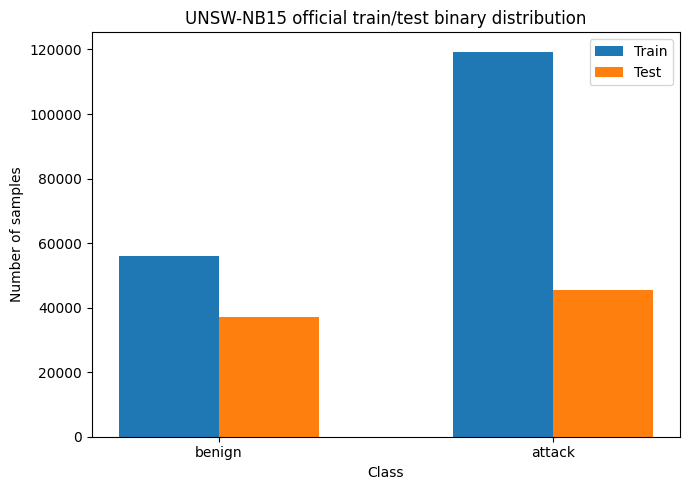


Saved: unsw_nb15_validation_outputs\figures\unsw_nb15_train_test_distribution.png

[Saved artifacts]
Directory: unsw_nb15_validation_outputs

[Step 12A summary]
{
  "dataset": "UNSW-NB15",
  "train_path": "../UNSW_NB15_training-set.csv",
  "test_path": "../UNSW_NB15_testing-set.csv",
  "train_shape": [
    175341,
    45
  ],
  "test_shape": [
    82332,
    45
  ],
  "feature_train_shape": [
    175341,
    42
  ],
  "feature_test_shape": [
    82332,
    42
  ],
  "target_column": "label",
  "dropped_feature_columns": [
    "id",
    "label",
    "attack_cat"
  ],
  "numeric_feature_count": 39,
  "categorical_feature_count": 3,
  "high_cardinality_categorical_columns": [
    "proto"
  ],
  "low_mid_cardinality_categorical_columns": [
    "service",
    "state"
  ],
  "log_numeric_columns": [
    "dur",
    "spkts",
    "dpkts",
    "sbytes",
    "dbytes",
    "rate",
    "sttl",
    "dttl",
    "sload",
    "dload",
    "sloss",
    "dloss",
    "sinpkt",
    "dinpkt",
    "sjit",
 

In [46]:
# STEP 12A: UNSW-NB15 loading + binary target preparation + preprocessing setup

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

print("=" * 80)
print("STEP 12A: UNSW-NB15 LOADING + PREPROCESSING SETUP")
print("=" * 80)

t0 = time.perf_counter()


# Safety checks
if "UNSW_TRAIN_PATH" not in globals():
    UNSW_TRAIN_PATH = "../UNSW_NB15_training-set.csv"

if "UNSW_TEST_PATH" not in globals():
    UNSW_TEST_PATH = "../UNSW_NB15_testing-set.csv"

assert os.path.exists(UNSW_TRAIN_PATH), f"UNSW train file not found: {UNSW_TRAIN_PATH}"
assert os.path.exists(UNSW_TEST_PATH), f"UNSW test file not found: {UNSW_TEST_PATH}"


# Load official UNSW train/test partitions
t_load0 = time.perf_counter()

try:
    unsw_train_df = pd.read_csv(UNSW_TRAIN_PATH, low_memory=False)
    unsw_test_df = pd.read_csv(UNSW_TEST_PATH, low_memory=False)
except UnicodeDecodeError:
    unsw_train_df = pd.read_csv(UNSW_TRAIN_PATH, low_memory=False, encoding="latin1")
    unsw_test_df = pd.read_csv(UNSW_TEST_PATH, low_memory=False, encoding="latin1")

t_load = time.perf_counter() - t_load0

print("\n[UNSW load status]")
print(f"Loaded in {t_load:.4f} seconds")
print("Train shape:", unsw_train_df.shape)
print("Test shape :", unsw_test_df.shape)

print("\n[UNSW train columns]")
print(unsw_train_df.columns.tolist())

assert "label" in unsw_train_df.columns, "Expected UNSW binary target column 'label' not found in train set."
assert "label" in unsw_test_df.columns, "Expected UNSW binary target column 'label' not found in test set."


# Basic target distribution
unsw_train_df["label"] = pd.to_numeric(unsw_train_df["label"], errors="coerce").fillna(-1).astype(int)
unsw_test_df["label"] = pd.to_numeric(unsw_test_df["label"], errors="coerce").fillna(-1).astype(int)

print("\n[UNSW binary target distribution: train]")
print(unsw_train_df["label"].value_counts().sort_index())
print((100 * unsw_train_df["label"].value_counts(normalize=True).sort_index()).round(4))

print("\n[UNSW binary target distribution: test]")
print(unsw_test_df["label"].value_counts().sort_index())
print((100 * unsw_test_df["label"].value_counts(normalize=True).sort_index()).round(4))

if "attack_cat" in unsw_train_df.columns:
    print("\n[UNSW attack category distribution: train]")
    print(unsw_train_df["attack_cat"].astype(str).str.strip().value_counts().head(20))

if "attack_cat" in unsw_test_df.columns:
    print("\n[UNSW attack category distribution: test]")
    print(unsw_test_df["attack_cat"].astype(str).str.strip().value_counts().head(20))


# Official benchmark split is preserved.
# We do not combine train and test, and we do not fit preprocessing on test.
DROP_FROM_UNSW_FEATURES = [
    c for c in ["id", "label", "attack_cat"]
    if c in unsw_train_df.columns
]

print("\n[UNSW columns dropped from model features]")
print(DROP_FROM_UNSW_FEATURES)

X_unsw_train_raw = unsw_train_df.drop(columns=DROP_FROM_UNSW_FEATURES, errors="ignore").copy()
X_unsw_test_raw = unsw_test_df.drop(columns=DROP_FROM_UNSW_FEATURES, errors="ignore").copy()

y_unsw_train = unsw_train_df["label"].copy().reset_index(drop=True)
y_unsw_test = unsw_test_df["label"].copy().reset_index(drop=True)


# Align test columns to train columns
missing_in_test = [c for c in X_unsw_train_raw.columns if c not in X_unsw_test_raw.columns]
extra_in_test = [c for c in X_unsw_test_raw.columns if c not in X_unsw_train_raw.columns]

print("\n[UNSW feature alignment]")
print("Missing in test:", missing_in_test if missing_in_test else "None")
print("Extra in test  :", extra_in_test if extra_in_test else "None")

for c in missing_in_test:
    X_unsw_test_raw[c] = np.nan

X_unsw_test_raw = X_unsw_test_raw[X_unsw_train_raw.columns].copy()


# Normalize object placeholders
unsw_obj_cols = X_unsw_train_raw.select_dtypes(include=["object", "string"]).columns.tolist()

for c in unsw_obj_cols:
    X_unsw_train_raw[c] = X_unsw_train_raw[c].astype(str).str.strip()
    X_unsw_train_raw[c] = X_unsw_train_raw[c].replace({
        "-": "MISSING_TOKEN",
        "": "MISSING_TOKEN",
        "nan": "MISSING_TOKEN",
        "None": "MISSING_TOKEN"
    })

    X_unsw_test_raw[c] = X_unsw_test_raw[c].astype(str).str.strip()
    X_unsw_test_raw[c] = X_unsw_test_raw[c].replace({
        "-": "MISSING_TOKEN",
        "": "MISSING_TOKEN",
        "nan": "MISSING_TOKEN",
        "None": "MISSING_TOKEN"
    })


# Feature groups
unsw_numeric_cols = X_unsw_train_raw.select_dtypes(include=[np.number]).columns.tolist()
unsw_categorical_cols = X_unsw_train_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print("\n[UNSW feature groups]")
print("Numeric feature count     :", len(unsw_numeric_cols))
print("Categorical feature count :", len(unsw_categorical_cols))

print("\nUNSW categorical columns:")
print(unsw_categorical_cols)


# Cardinality review
unsw_cat_cardinality = pd.DataFrame({
    "column": unsw_categorical_cols,
    "n_unique_train": [X_unsw_train_raw[c].nunique(dropna=False) for c in unsw_categorical_cols],
    "n_unique_test": [X_unsw_test_raw[c].nunique(dropna=False) for c in unsw_categorical_cols]
}).sort_values(by="n_unique_train", ascending=False)

print("\n[UNSW categorical cardinality]")
print(unsw_cat_cardinality)

UNSW_HIGH_CARD_THRESHOLD = 50

unsw_high_card_cat_cols = unsw_cat_cardinality.loc[
    unsw_cat_cardinality["n_unique_train"] > UNSW_HIGH_CARD_THRESHOLD,
    "column"
].tolist()

unsw_low_mid_card_cat_cols = unsw_cat_cardinality.loc[
    unsw_cat_cardinality["n_unique_train"] <= UNSW_HIGH_CARD_THRESHOLD,
    "column"
].tolist()

print("\n[UNSW categorical encoding strategy]")
print("High-cardinality categorical columns:", unsw_high_card_cat_cols if unsw_high_card_cat_cols else "None")
print("Low/mid-cardinality categorical cols:", unsw_low_mid_card_cat_cols if unsw_low_mid_card_cat_cols else "None")


# Data-driven log-transform selection for non-negative skewed numeric features
unsw_log_numeric_cols = []
for c in unsw_numeric_cols:
    s = pd.to_numeric(X_unsw_train_raw[c], errors="coerce")
    if s.min(skipna=True) >= 0 and s.max(skipna=True) > 10:
        unsw_log_numeric_cols.append(c)

unsw_non_log_numeric_cols = [c for c in unsw_numeric_cols if c not in unsw_log_numeric_cols]

print("\n[UNSW numeric preprocessing plan]")
print("Log-transform numeric columns:")
print(unsw_log_numeric_cols if unsw_log_numeric_cols else "None")

print("\nNon-log numeric columns:")
print(unsw_non_log_numeric_cols if unsw_non_log_numeric_cols else "None")


# Frequency encoder for high-cardinality categorical columns
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_maps_ = {}
        self.columns_ = []

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)
        self.freq_maps_ = {}

        n = len(X)
        for c in self.columns_:
            s = X[c].astype(str)
            vc = s.value_counts(dropna=False)
            self.freq_maps_[c] = (vc / max(n, 1)).to_dict()

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = np.zeros((len(X), len(self.columns_)), dtype=float)

        for j, c in enumerate(self.columns_):
            fmap = self.freq_maps_.get(c, {})
            out[:, j] = X[c].astype(str).map(fmap).fillna(0.0).astype(float).to_numpy()

        return out


# Build UNSW preprocessors
unsw_log_num_pipe_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

unsw_plain_num_pipe_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

unsw_log_num_pipe_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, validate=False))
])

unsw_plain_num_pipe_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

unsw_ohe_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

unsw_freq_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("freq", FrequencyEncoder())
])

unsw_scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", unsw_log_num_pipe_scaled, unsw_log_numeric_cols),
        ("plain_num", unsw_plain_num_pipe_scaled, unsw_non_log_numeric_cols),
        ("lowmid_cat", unsw_ohe_pipe, unsw_low_mid_card_cat_cols),
        ("high_cat", unsw_freq_pipe, unsw_high_card_cat_cols),
    ],
    remainder="drop"
)

unsw_tree_preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", unsw_log_num_pipe_tree, unsw_log_numeric_cols),
        ("plain_num", unsw_plain_num_pipe_tree, unsw_non_log_numeric_cols),
        ("lowmid_cat", unsw_ohe_pipe, unsw_low_mid_card_cat_cols),
        ("high_cat", unsw_freq_pipe, unsw_high_card_cat_cols),
    ],
    remainder="drop"
)


# Save distribution figure
OUT_DIR = "unsw_nb15_validation_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

unsw_dist_df = pd.DataFrame({
    "class_name": ["benign", "attack"],
    "train": y_unsw_train.value_counts().reindex([0, 1], fill_value=0).sort_index().values,
    "test": y_unsw_test.value_counts().reindex([0, 1], fill_value=0).sort_index().values
})

x_pos = np.arange(len(unsw_dist_df))
bar_width = 0.30

plt.figure(figsize=(7, 5))
plt.bar(x_pos - bar_width / 2, unsw_dist_df["train"], width=bar_width, label="Train")
plt.bar(x_pos + bar_width / 2, unsw_dist_df["test"], width=bar_width, label="Test")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("UNSW-NB15 official train/test binary distribution")
plt.xticks(x_pos, unsw_dist_df["class_name"])
plt.legend()
plt.tight_layout()

unsw_dist_fig_path = os.path.join(FIG_DIR, "unsw_nb15_train_test_distribution.png")
plt.savefig(unsw_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved:", unsw_dist_fig_path)


# Save artifacts
unsw_cat_cardinality.to_csv(os.path.join(OUT_DIR, "unsw_categorical_cardinality.csv"), index=False)
unsw_dist_df.to_csv(os.path.join(OUT_DIR, "unsw_train_test_distribution.csv"), index=False)

step12a_summary = {
    "dataset": "UNSW-NB15",
    "train_path": UNSW_TRAIN_PATH,
    "test_path": UNSW_TEST_PATH,
    "train_shape": list(unsw_train_df.shape),
    "test_shape": list(unsw_test_df.shape),
    "feature_train_shape": list(X_unsw_train_raw.shape),
    "feature_test_shape": list(X_unsw_test_raw.shape),
    "target_column": "label",
    "dropped_feature_columns": DROP_FROM_UNSW_FEATURES,
    "numeric_feature_count": int(len(unsw_numeric_cols)),
    "categorical_feature_count": int(len(unsw_categorical_cols)),
    "high_cardinality_categorical_columns": unsw_high_card_cat_cols,
    "low_mid_cardinality_categorical_columns": unsw_low_mid_card_cat_cols,
    "log_numeric_columns": unsw_log_numeric_cols,
    "non_log_numeric_columns": unsw_non_log_numeric_cols
}

with open(os.path.join(OUT_DIR, "step12a_unsw_preparation_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step12a_summary, f, indent=2)

t_step12a = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 12A summary]")
print(json.dumps(step12a_summary, indent=2))

print(f"\nSTEP 12A completed successfully in {t_step12a:.4f} seconds.")

STEP 12B: UNSW-NB15 EXTERNAL VALIDATION

[UNSW candidate models]
['logreg', 'rf', 'extratrees', 'lightgbm', 'xgboost']

--------------------------------------------------------------------------------
Training and evaluating UNSW model: logreg
Accuracy              : 0.866990
Precision             : 0.837698
Recall                : 0.940682
F1                    : 0.886208
Macro-F1              : 0.863084
Weighted-F1           : 0.865425
ROC-AUC               : 0.965927
Average Precision     : 0.972925
Fit time (s)          : 4.4249
Predict ms/sample     : 0.002265

--------------------------------------------------------------------------------
Training and evaluating UNSW model: rf
Accuracy              : 0.871314
Precision             : 0.817146
Recall                : 0.987183
F1                    : 0.894153
Macro-F1              : 0.865030
Weighted-F1           : 0.867977
ROC-AUC               : 0.980248
Average Precision     : 0.983722
Fit time (s)          : 9.5446
Predict ms/s

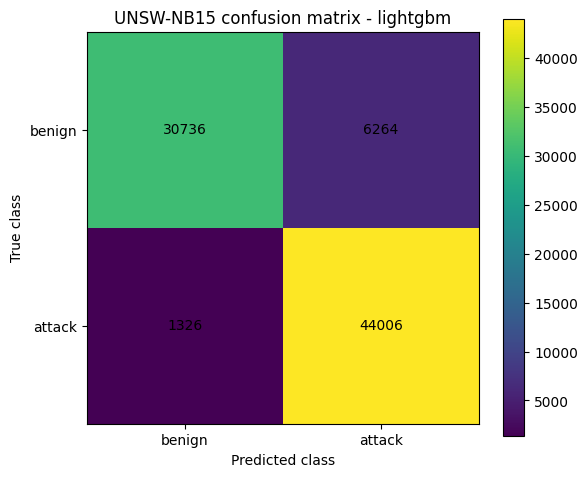

Saved: unsw_nb15_validation_outputs\figures\unsw_confusion_matrix_lightgbm.png


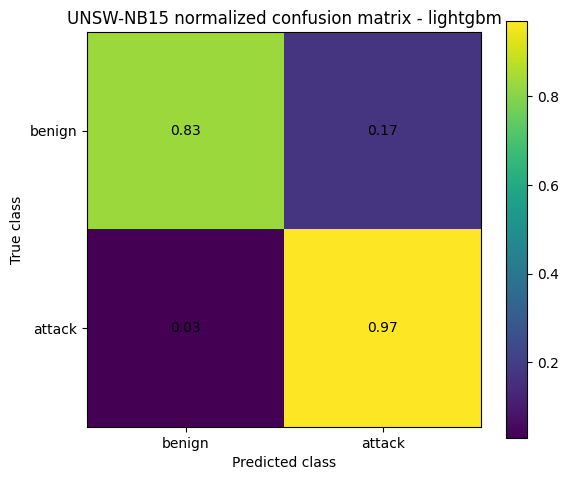

Saved: unsw_nb15_validation_outputs\figures\unsw_confusion_matrix_normalized_lightgbm.png


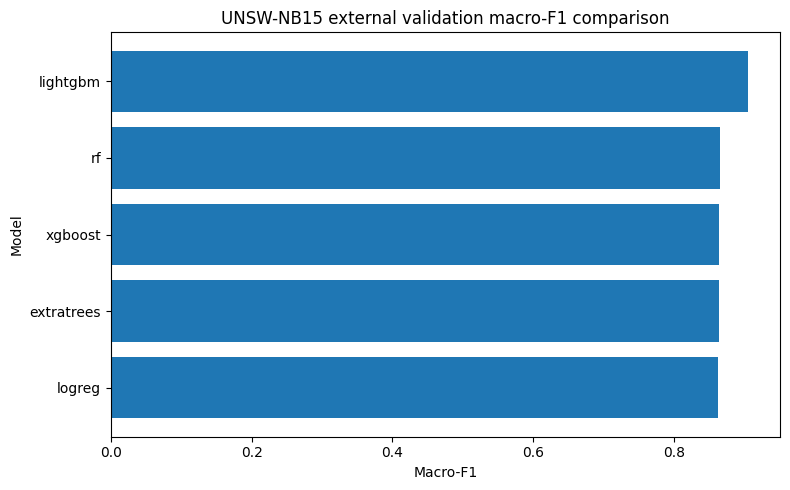

Saved: unsw_nb15_validation_outputs\figures\unsw_model_comparison_macro_f1.png

Saved: unsw_nb15_validation_outputs\predictions\unsw_test_predictions_all_models.csv

[Saved artifacts]
Directory: unsw_nb15_validation_outputs

[Step 12B summary]
{
  "dataset": "UNSW-NB15",
  "task": "binary intrusion detection",
  "train_shape": [
    175341,
    42
  ],
  "test_shape": [
    82332,
    42
  ],
  "models_evaluated": [
    "logreg",
    "rf",
    "extratrees",
    "lightgbm",
    "xgboost"
  ],
  "best_model": "lightgbm",
  "best_model_metrics": {
    "model": "lightgbm",
    "accuracy": 0.9078122722635185,
    "precision": 0.8753928784563357,
    "recall": 0.9707491396805789,
    "f1": 0.9206083554737349,
    "f1_macro": 0.9053535536599511,
    "f1_weighted": 0.9068973398999604,
    "roc_auc": 0.9852553449505271,
    "average_precision": 0.9891226576222689,
    "fit_s": 1.7905994999746326,
    "pred_s": 0.26346940000075847,
    "pred_ms_per_sample": 0.0032000850216289956
  },
  "predicti

In [47]:
# STEP 12B: UNSW-NB15 external validation
# - train on official UNSW training set
# - evaluate on official UNSW testing set
# - binary IDS validation benchmark

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

print("=" * 80)
print("STEP 12B: UNSW-NB15 EXTERNAL VALIDATION")
print("=" * 80)

t0 = time.perf_counter()


# Safety checks
required_vars = [
    "X_unsw_train_raw", "X_unsw_test_raw",
    "y_unsw_train", "y_unsw_test",
    "unsw_scaled_preprocessor", "unsw_tree_preprocessor"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Step 12A first."


OUT_DIR = "unsw_nb15_validation_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

PRED_DIR = os.path.join(OUT_DIR, "predictions")
os.makedirs(PRED_DIR, exist_ok=True)


# Candidate models for concise external validation
unsw_models = {
    "logreg": Pipeline([
        ("preprocessor", unsw_scaled_preprocessor),
        ("clf", LogisticRegression(
            max_iter=400,
            class_weight="balanced",
            n_jobs=None,
            random_state=42
        ))
    ]),
    "rf": Pipeline([
        ("preprocessor", unsw_tree_preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=250,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]),
    "extratrees": Pipeline([
        ("preprocessor", unsw_tree_preprocessor),
        ("clf", ExtraTreesClassifier(
            n_estimators=250,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])
}

try:
    from lightgbm import LGBMClassifier

    unsw_models["lightgbm"] = Pipeline([
        ("preprocessor", unsw_tree_preprocessor),
        ("clf", LGBMClassifier(
            objective="binary",
            n_estimators=250,
            learning_rate=0.1,
            num_leaves=31,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced",
            verbose=-1
        ))
    ])
except Exception as e:
    print(f"LightGBM not available for UNSW validation: {e}")

try:
    from xgboost import XGBClassifier

    unsw_models["xgboost"] = Pipeline([
        ("preprocessor", unsw_tree_preprocessor),
        ("clf", XGBClassifier(
            n_estimators=250,
            max_depth=8,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
except Exception as e:
    print(f"XGBoost not available for UNSW validation: {e}")


print("\n[UNSW candidate models]")
print(list(unsw_models.keys()))


def evaluate_unsw_binary_model(model, X_tr, y_tr, X_te, y_te):
    result = {}

    t_fit0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    result["fit_s"] = time.perf_counter() - t_fit0

    t_pred0 = time.perf_counter()
    y_pred = model.predict(X_te)
    result["pred_s"] = time.perf_counter() - t_pred0

    result["y_pred"] = y_pred
    result["pred_ms_per_sample"] = 1000 * result["pred_s"] / len(X_te)

    result["accuracy"] = accuracy_score(y_te, y_pred)
    result["precision"] = precision_score(y_te, y_pred, zero_division=0)
    result["recall"] = recall_score(y_te, y_pred, zero_division=0)
    result["f1"] = f1_score(y_te, y_pred, zero_division=0)
    result["f1_macro"] = f1_score(y_te, y_pred, average="macro", zero_division=0)
    result["f1_weighted"] = f1_score(y_te, y_pred, average="weighted", zero_division=0)

    result["roc_auc"] = np.nan
    result["average_precision"] = np.nan
    result["y_score"] = None

    if hasattr(model, "predict_proba"):
        try:
            y_proba = model.predict_proba(X_te)
            y_score = y_proba[:, 1]
            result["y_score"] = y_score
            result["roc_auc"] = roc_auc_score(y_te, y_score)
            result["average_precision"] = average_precision_score(y_te, y_score)
        except Exception as e:
            print(f"Probability metric warning: {e}")

    result["cm"] = confusion_matrix(y_te, y_pred, labels=[0, 1])

    return result


# Train and evaluate
unsw_rows = []
unsw_predictions = {}
unsw_scores = {}
unsw_final_models = {}

for name, model in unsw_models.items():
    print("\n" + "-" * 80)
    print(f"Training and evaluating UNSW model: {name}")

    res = evaluate_unsw_binary_model(
        model,
        X_unsw_train_raw,
        y_unsw_train,
        X_unsw_test_raw,
        y_unsw_test
    )

    unsw_final_models[name] = model
    unsw_predictions[name] = res["y_pred"]
    unsw_scores[name] = res["y_score"]

    unsw_rows.append({
        "model": name,
        "accuracy": res["accuracy"],
        "precision": res["precision"],
        "recall": res["recall"],
        "f1": res["f1"],
        "f1_macro": res["f1_macro"],
        "f1_weighted": res["f1_weighted"],
        "roc_auc": res["roc_auc"],
        "average_precision": res["average_precision"],
        "fit_s": res["fit_s"],
        "pred_s": res["pred_s"],
        "pred_ms_per_sample": res["pred_ms_per_sample"]
    })

    print(f"Accuracy              : {res['accuracy']:.6f}")
    print(f"Precision             : {res['precision']:.6f}")
    print(f"Recall                : {res['recall']:.6f}")
    print(f"F1                    : {res['f1']:.6f}")
    print(f"Macro-F1              : {res['f1_macro']:.6f}")
    print(f"Weighted-F1           : {res['f1_weighted']:.6f}")
    print(f"ROC-AUC               : {res['roc_auc']:.6f}")
    print(f"Average Precision     : {res['average_precision']:.6f}")
    print(f"Fit time (s)          : {res['fit_s']:.4f}")
    print(f"Predict ms/sample     : {res['pred_ms_per_sample']:.6f}")


unsw_results_df = pd.DataFrame(unsw_rows).sort_values(
    by=["f1_macro", "f1", "roc_auc", "pred_ms_per_sample"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

unsw_best_name = unsw_results_df.loc[0, "model"]
unsw_best_model = unsw_final_models[unsw_best_name]

print("\n" + "=" * 80)
print("[UNSW-NB15 EXTERNAL VALIDATION RESULTS]")
print("=" * 80)
print(unsw_results_df)

print("\n[Selected UNSW best model]")
print(unsw_best_name)


# Best model report
unsw_best_pred = unsw_predictions[unsw_best_name]
unsw_best_cm = confusion_matrix(y_unsw_test, unsw_best_pred, labels=[0, 1])

print("\n" + "=" * 80)
print(f"[UNSW CLASSIFICATION REPORT: {unsw_best_name}]")
print("=" * 80)
print(classification_report(
    y_unsw_test,
    unsw_best_pred,
    target_names=["benign", "attack"],
    digits=4,
    zero_division=0
))

unsw_cm_df = pd.DataFrame(
    unsw_best_cm,
    index=["true_benign", "true_attack"],
    columns=["pred_benign", "pred_attack"]
)

print("\n[UNSW best model confusion matrix]")
print(unsw_cm_df)


# Save confusion matrix figure
plt.figure(figsize=(6, 5))
plt.imshow(unsw_best_cm, interpolation="nearest")
plt.title(f"UNSW-NB15 confusion matrix - {unsw_best_name}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(np.arange(2), ["benign", "attack"])
plt.yticks(np.arange(2), ["benign", "attack"])
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(unsw_best_cm[i, j]), ha="center", va="center")

plt.tight_layout()

unsw_cm_fig_path = os.path.join(FIG_DIR, f"unsw_confusion_matrix_{unsw_best_name}.png")
plt.savefig(unsw_cm_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", unsw_cm_fig_path)


# Normalized confusion matrix
unsw_cm_norm = unsw_best_cm.astype(float) / np.maximum(unsw_best_cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(6, 5))
plt.imshow(unsw_cm_norm, interpolation="nearest")
plt.title(f"UNSW-NB15 normalized confusion matrix - {unsw_best_name}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(np.arange(2), ["benign", "attack"])
plt.yticks(np.arange(2), ["benign", "attack"])
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{unsw_cm_norm[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()

unsw_cm_norm_fig_path = os.path.join(FIG_DIR, f"unsw_confusion_matrix_normalized_{unsw_best_name}.png")
plt.savefig(unsw_cm_norm_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", unsw_cm_norm_fig_path)


# Model comparison figure
plot_df = unsw_results_df.sort_values(by="f1_macro", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["model"], plot_df["f1_macro"])
plt.xlabel("Macro-F1")
plt.ylabel("Model")
plt.title("UNSW-NB15 external validation macro-F1 comparison")
plt.tight_layout()

unsw_comparison_fig_path = os.path.join(FIG_DIR, "unsw_model_comparison_macro_f1.png")
plt.savefig(unsw_comparison_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", unsw_comparison_fig_path)


# Save predictions
unsw_pred_df = pd.DataFrame({
    "y_true": pd.Series(y_unsw_test).astype(int)
})

for name, pred in unsw_predictions.items():
    unsw_pred_df[f"pred_{name}"] = pd.Series(pred).astype(int)

unsw_pred_path = os.path.join(PRED_DIR, "unsw_test_predictions_all_models.csv")
unsw_pred_df.to_csv(unsw_pred_path, index=False)

print("\nSaved:", unsw_pred_path)


# Save tables
unsw_results_df.to_csv(os.path.join(OUT_DIR, "unsw_external_validation_results.csv"), index=False)
unsw_cm_df.to_csv(os.path.join(OUT_DIR, f"unsw_confusion_matrix_{unsw_best_name}.csv"))

step12b_summary = {
    "dataset": "UNSW-NB15",
    "task": "binary intrusion detection",
    "train_shape": list(X_unsw_train_raw.shape),
    "test_shape": list(X_unsw_test_raw.shape),
    "models_evaluated": list(unsw_models.keys()),
    "best_model": unsw_best_name,
    "best_model_metrics": unsw_results_df.iloc[0].to_dict(),
    "prediction_file": unsw_pred_path,
    "confusion_matrix_figure": unsw_cm_fig_path,
    "normalized_confusion_matrix_figure": unsw_cm_norm_fig_path,
    "comparison_figure": unsw_comparison_fig_path
}

with open(os.path.join(OUT_DIR, "step12b_unsw_external_validation_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step12b_summary, f, indent=2)

t_step12b = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 12B summary]")
print(json.dumps(step12b_summary, indent=2))

print(f"\nSTEP 12B completed successfully in {t_step12b:.4f} seconds.")

STEP 13: UNSW-NB15 LEARNING CURVE ANALYSIS

[UNSW learning curve model]
lightgbm

[UNSW learning curve dataset]
X shape: (175341, 42)
y shape: (175341,)
Class distribution:
label
0     56000
1    119341
Name: count, dtype: int64

[UNSW learning curve setup]
Scoring     : f1_macro
CV folds    : 3
Train sizes : [0.1, 0.25, 0.5, 0.75, 1.0]

[UNSW learning curve results]
   train_size  train_f1_macro_mean  train_f1_macro_std  cv_f1_macro_mean  cv_f1_macro_std  fit_time_mean_s  score_time_mean_s
0       11689             0.997971            0.000319          0.936672         0.001018         0.478503           0.215702
1       29223             0.987224            0.000777          0.942214         0.000213         0.710714           0.195368
2       58447             0.973494            0.000770          0.944831         0.001043         0.924625           0.205534
3       87670             0.966103            0.000631          0.946906         0.000791         1.180575           0.203689


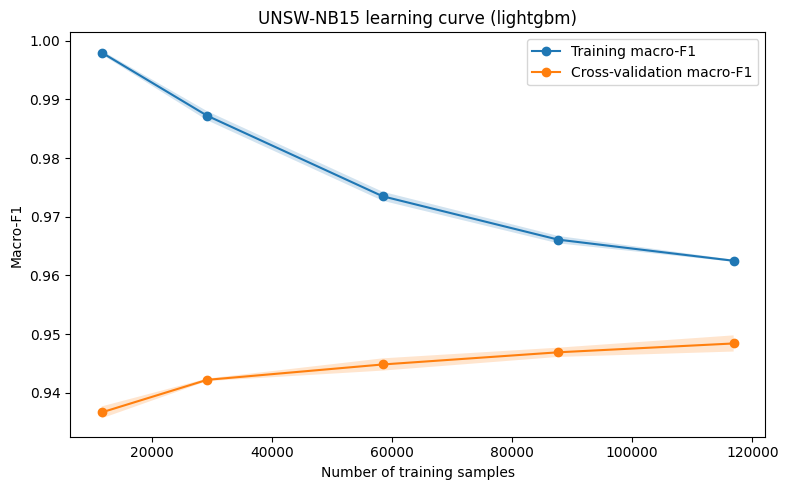


Saved: unsw_nb15_validation_outputs\figures\unsw_learning_curve_lightgbm.png

[Saved artifacts]
Directory: unsw_nb15_validation_outputs

[Step 13 summary]
{
  "dataset": "UNSW-NB15",
  "model": "lightgbm",
  "scoring": "f1_macro",
  "cv_folds": 3,
  "train_sizes": [
    0.1,
    0.25,
    0.5,
    0.75,
    1.0
  ],
  "learning_curve_time_seconds": 20.12726829998428,
  "figure_path": "unsw_nb15_validation_outputs\\figures\\unsw_learning_curve_lightgbm.png"
}

STEP 13 completed successfully in 20.6619 seconds.


In [48]:
# STEP 13: Learning curve analysis on UNSW-NB15
# - train size vs training macro-F1
# - train size vs cross-validation macro-F1

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, learning_curve

print("=" * 80)
print("STEP 13: UNSW-NB15 LEARNING CURVE ANALYSIS")
print("=" * 80)

t0 = time.perf_counter()


# Safety checks
required_vars = [
    "unsw_best_model",
    "unsw_best_name",
    "X_unsw_train_raw",
    "y_unsw_train"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Step 12B first."


print("\n[UNSW learning curve model]")
print(unsw_best_name)

lc_model = clone(unsw_best_model)

X_lc = X_unsw_train_raw.copy()
y_lc = pd.Series(y_unsw_train).reset_index(drop=True)

print("\n[UNSW learning curve dataset]")
print("X shape:", X_lc.shape)
print("y shape:", y_lc.shape)
print("Class distribution:")
print(y_lc.value_counts().sort_index())


train_sizes = np.array([0.10, 0.25, 0.50, 0.75, 1.00])

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("\n[UNSW learning curve setup]")
print("Scoring     : f1_macro")
print("CV folds    : 3")
print("Train sizes :", train_sizes.tolist())


t_lc0 = time.perf_counter()

train_sizes_abs, train_scores, cv_scores, fit_times, score_times = learning_curve(
    estimator=lc_model,
    X=X_lc,
    y=y_lc,
    train_sizes=train_sizes,
    cv=cv,
    scoring="f1_macro",
    n_jobs=1,
    return_times=True,
    shuffle=True,
    random_state=42
)

t_lc = time.perf_counter() - t_lc0

unsw_lc_df = pd.DataFrame({
    "train_size": train_sizes_abs,
    "train_f1_macro_mean": train_scores.mean(axis=1),
    "train_f1_macro_std": train_scores.std(axis=1),
    "cv_f1_macro_mean": cv_scores.mean(axis=1),
    "cv_f1_macro_std": cv_scores.std(axis=1),
    "fit_time_mean_s": fit_times.mean(axis=1),
    "score_time_mean_s": score_times.mean(axis=1)
})

print("\n[UNSW learning curve results]")
print(unsw_lc_df)


OUT_DIR = "unsw_nb15_validation_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(
    unsw_lc_df["train_size"],
    unsw_lc_df["train_f1_macro_mean"],
    marker="o",
    label="Training macro-F1"
)
plt.plot(
    unsw_lc_df["train_size"],
    unsw_lc_df["cv_f1_macro_mean"],
    marker="o",
    label="Cross-validation macro-F1"
)

plt.fill_between(
    unsw_lc_df["train_size"],
    unsw_lc_df["train_f1_macro_mean"] - unsw_lc_df["train_f1_macro_std"],
    unsw_lc_df["train_f1_macro_mean"] + unsw_lc_df["train_f1_macro_std"],
    alpha=0.2
)

plt.fill_between(
    unsw_lc_df["train_size"],
    unsw_lc_df["cv_f1_macro_mean"] - unsw_lc_df["cv_f1_macro_std"],
    unsw_lc_df["cv_f1_macro_mean"] + unsw_lc_df["cv_f1_macro_std"],
    alpha=0.2
)

plt.xlabel("Number of training samples")
plt.ylabel("Macro-F1")
plt.title(f"UNSW-NB15 learning curve ({unsw_best_name})")
plt.legend()
plt.tight_layout()

unsw_lc_fig_path = os.path.join(FIG_DIR, f"unsw_learning_curve_{unsw_best_name}.png")
plt.savefig(unsw_lc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved:", unsw_lc_fig_path)


unsw_lc_df.to_csv(
    os.path.join(OUT_DIR, f"unsw_learning_curve_{unsw_best_name}.csv"),
    index=False
)

step13_summary = {
    "dataset": "UNSW-NB15",
    "model": unsw_best_name,
    "scoring": "f1_macro",
    "cv_folds": 3,
    "train_sizes": train_sizes.tolist(),
    "learning_curve_time_seconds": float(t_lc),
    "figure_path": unsw_lc_fig_path
}

with open(os.path.join(OUT_DIR, "step13_unsw_learning_curve_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step13_summary, f, indent=2)

t_step13 = time.perf_counter() - t0

print("\n[Saved artifacts]")
print("Directory:", OUT_DIR)

print("\n[Step 13 summary]")
print(json.dumps(step13_summary, indent=2))

print(f"\nSTEP 13 completed successfully in {t_step13:.4f} seconds.")

In [49]:
# STEP 14: Multiclass forensic evidence logging
# - append-only SHA-256 hash-chained evidence records
# - alert = predicted class != normal
# - stores predicted class, confidence, top-k probabilities
# - stores per-alert signed SHAP attributions


import os
import json
import time
import hashlib
import datetime
import numpy as np
import pandas as pd
from dataclasses import dataclass, asdict

print("=" * 80)
print("STEP 14: MULTICLASS FORENSIC EVIDENCE LOGGING")
print("=" * 80)

t0 = time.perf_counter()


# Safety checks
required_vars = [
    "best_model",
    "X_test_raw", "y_test", "ctx_test",
    "inv_label_mapping", "label_mapping",
    "preprocessor", "transformed_feature_names",
    "low_mid_card_cat_cols"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run Steps 8-9 first."

if "best_name_extended" in globals():
    best_name_final = best_name_extended
elif "scores_df_extended" in globals():
    best_name_final = scores_df_extended.loc[0, "model"]
else:
    best_name_final = "best_model"

assert "normal" in label_mapping, "'normal' class not found in label mapping."
NORMAL_CLASS_ID = label_mapping["normal"]


# Hash helpers
HASH_ALGORITHM = "SHA-256"

def sha256_hex(b: bytes) -> str:
    return hashlib.sha256(b).hexdigest()

def stable_hash(obj) -> str:
    s = json.dumps(obj, sort_keys=True, ensure_ascii=False, default=str).encode("utf-8")
    return sha256_hex(s)


# Evidence schema
@dataclass
class MultiClassEvidenceRecord:
    record_id: str
    created_utc: str
    case_id: str
    event_time: str
    context: dict

    model_name: str
    model_digest: str
    feature_schema_digest: str
    hash_algorithm: str

    true_label_id: int
    true_label_name: str

    prediction_id: int
    prediction_name: str

    confidence: float
    score_type: str
    topk_predictions: list

    features_digest: str
    top_features: list

    prev_hash: str
    record_hash: str


# Record creation
def make_multiclass_evidence(
    case_id,
    idx,
    context,
    model_name,
    true_label_id,
    true_label_name,
    pred_id,
    pred_name,
    confidence,
    topk_predictions,
    features_row,
    prev_hash,
    *,
    model_digest="",
    feature_schema_digest="",
    hash_algorithm="SHA-256",
    score_type="max_class_probability",
    top_features=None
):
    created = datetime.datetime.utcnow().isoformat() + "Z"
    event_time = context.get("timestamp") or context.get("time") or created

    if top_features is None:
        top_features = []

    features_digest = stable_hash(features_row)

    core = {
        "record_id": f"{case_id}-{idx}",
        "created_utc": created,
        "case_id": case_id,
        "event_time": event_time,
        "context": context,

        "model_name": model_name,
        "model_digest": model_digest,
        "feature_schema_digest": feature_schema_digest,
        "hash_algorithm": hash_algorithm,

        "true_label_id": int(true_label_id),
        "true_label_name": str(true_label_name),

        "prediction_id": int(pred_id),
        "prediction_name": str(pred_name),

        "confidence": float(confidence),
        "score_type": str(score_type),
        "topk_predictions": topk_predictions,

        "features_digest": features_digest,
        "top_features": top_features,

        "prev_hash": prev_hash
    }

    record_hash = stable_hash(core)
    return MultiClassEvidenceRecord(record_hash=record_hash, **core)

def append_jsonl(path, obj):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, default=str) + "\n")

def verify_jsonl_hashchain(path):
    prev = "GENESIS"
    ok = True
    bad_record = None

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            rh = rec["record_hash"]
            core = {k: rec[k] for k in rec.keys() if k != "record_hash"}

            if core["prev_hash"] != prev:
                print("Broken link at:", core.get("record_id"))
                ok = False
                bad_record = core.get("record_id")
                break

            if stable_hash(core) != rh:
                print("Hash mismatch at:", core.get("record_id"))
                ok = False
                bad_record = core.get("record_id")
                break

            prev = rh

    return ok, bad_record


# Utility: map transformed feature names back to raw feature names
def map_transformed_to_raw_feature_name(fname):
    if fname.endswith("__log1p"):
        return fname.replace("__log1p", "")
    if fname.endswith("__scaled"):
        return fname.replace("__scaled", "")
    if fname.endswith("__freq"):
        return fname.replace("__freq", "")

    for c in sorted(low_mid_card_cat_cols, key=len, reverse=True):
        if fname.startswith(c + "_"):
            return c
    return fname


# Prepare output paths
CASE_ID = f"CASE-{datetime.datetime.utcnow().strftime('%Y%m%d-%H%M%S')}"
OUT_DIR = "forensic_outputs_multiclass"
os.makedirs(OUT_DIR, exist_ok=True)

EVIDENCE_LOG = os.path.join(OUT_DIR, f"{CASE_ID}_evidence_multiclass.jsonl")


# Model metadata digests
feature_schema_digest = stable_hash(list(X_test_raw.columns))

model_meta = {
    "model_name": best_name_final,
    "params": best_model.get_params(),
    "normal_class_id": int(NORMAL_CLASS_ID),
    "label_mapping": label_mapping,
    "hash_algorithm": HASH_ALGORITHM
}
model_digest = stable_hash(model_meta)


# Predictions and alert selection
t_pred0 = time.perf_counter()
y_pred = best_model.predict(X_test_raw)
y_proba = best_model.predict_proba(X_test_raw)
t_pred = time.perf_counter() - t_pred0

print("\n[Prediction runtime]")
print(f"Predict + predict_proba time (s): {t_pred:.4f}")

# alerts = non-normal predictions
alert_idxs = np.where(y_pred != NORMAL_CLASS_ID)[0]

print("\n[Alert summary]")
print("Total test samples        :", len(X_test_raw))
print("Predicted alerts          :", len(alert_idxs))
print("Predicted normal samples  :", int((y_pred == NORMAL_CLASS_ID).sum()))


alert_class_distribution = pd.Series(y_pred[alert_idxs]).map(inv_label_mapping).value_counts()

print("\n[Predicted alert class distribution]")
print(alert_class_distribution)

# Rank alerts by confidence and keep top N for graph/log focus
N_ALERTS = min(500, len(alert_idxs))
alert_conf = y_proba[alert_idxs].max(axis=1)
top_alert_order = np.argsort(alert_conf)[::-1][:N_ALERTS]
top_alerts = alert_idxs[top_alert_order]

print("Alerts retained for evidence log:", len(top_alerts))


# Prepare SHAP values for the retained portion
# To keep runtime controlled, compute SHAP only for the retained alerts
TOPK_EXPLAIN = 5

X_test_r = X_test_raw.reset_index(drop=True)
ctx_test_r = ctx_test.reset_index(drop=True)
y_test_r = pd.Series(y_test).reset_index(drop=True)

X_alert_raw = X_test_r.iloc[top_alerts].copy()
X_alert_trans = preprocessor.transform(X_alert_raw)

if hasattr(X_alert_trans, "toarray"):
    X_alert_trans = X_alert_trans.toarray()
X_alert_trans = np.asarray(X_alert_trans)

print("\n[Per-alert SHAP setup]")
print("Retained alert sample size:", len(X_alert_raw))
print("Transformed alert matrix shape:", X_alert_trans.shape)

import shap
t_shap0 = time.perf_counter()
explainer_alert = shap.TreeExplainer(best_model.named_steps["clf"])
shap_values_alert = explainer_alert.shap_values(X_alert_trans)
t_shap_alert = time.perf_counter() - t_shap0

print(f"Per-alert SHAP computation time (s): {t_shap_alert:.4f}")

# normalize shape
if isinstance(shap_values_alert, list):
    shap_alert_by_class = [np.asarray(sv) for sv in shap_values_alert]
elif isinstance(shap_values_alert, np.ndarray) and shap_values_alert.ndim == 3:
    shap_alert_by_class = [shap_values_alert[:, :, k] for k in range(shap_values_alert.shape[2])]
else:
    raise ValueError(
        f"Unexpected SHAP output structure for retained alerts: "
        f"type={type(shap_values_alert)}, shape={getattr(shap_values_alert, 'shape', None)}"
    )


# Build and write evidence records
prev_hash = "GENESIS"

for j, i in enumerate(top_alerts):
    context = ctx_test_r.iloc[i].to_dict()
    feat_row = X_test_r.iloc[i].to_dict()

    pred_id = int(y_pred[i])
    pred_name = inv_label_mapping[pred_id]

    true_id = int(y_test_r.iloc[i])
    true_name = inv_label_mapping[true_id]

    proba_row = y_proba[i]
    confidence = float(np.max(proba_row))

    top3_idx = np.argsort(proba_row)[::-1][:3]
    topk_predictions = [
        {
            "class_id": int(k),
            "class_name": inv_label_mapping[int(k)],
            "probability": float(proba_row[k])
        }
        for k in top3_idx
    ]

    # per-alert SHAP for the predicted class
    local_alert_pos = j
    local_shap_vec = shap_alert_by_class[pred_id][local_alert_pos]

    if len(local_shap_vec) != len(transformed_feature_names):
        local_feature_names = [f"feature_{k}" for k in range(len(local_shap_vec))]
    else:
        local_feature_names = transformed_feature_names
    
    local_shap_df = pd.DataFrame({
        "transformed_feature": local_feature_names,
        "shap_value": local_shap_vec
    })

    local_shap_df["abs_shap"] = local_shap_df["shap_value"].abs()
    local_shap_df["raw_feature"] = local_shap_df["transformed_feature"].apply(map_transformed_to_raw_feature_name)

    # aggregate to raw feature
    local_raw_shap = local_shap_df.groupby("raw_feature", as_index=False).agg({
        "shap_value": "sum",
        "abs_shap": "sum"
    }).sort_values(by="abs_shap", ascending=False).reset_index(drop=True)

    top_features = []
    for _, row in local_raw_shap.head(TOPK_EXPLAIN).iterrows():
        f = row["raw_feature"]
        val = X_test_r.loc[i, f] if f in X_test_r.columns else None

        if val is not None:
            try:
                val = float(val)
            except Exception:
                val = str(val)

        shap_val = float(row["shap_value"])
        sign = "+" if shap_val > 0 else "-" if shap_val < 0 else "0"

        top_features.append({
            "feature": f,
            "value": val,
            "shap_value": shap_val,
            "abs_shap_value": float(row["abs_shap"]),
            "sign": sign
        })

    rec = make_multiclass_evidence(
        case_id=CASE_ID,
        idx=j,
        context=context,
        model_name=best_name_final,
        true_label_id=true_id,
        true_label_name=true_name,
        pred_id=pred_id,
        pred_name=pred_name,
        confidence=confidence,
        topk_predictions=topk_predictions,
        features_row=feat_row,
        prev_hash=prev_hash,
        model_digest=model_digest,
        feature_schema_digest=feature_schema_digest,
        hash_algorithm=HASH_ALGORITHM,
        score_type="max_class_probability",
        top_features=top_features
    )

    append_jsonl(EVIDENCE_LOG, asdict(rec))
    prev_hash = rec.record_hash


# Final verification
hash_ok, bad_record = verify_jsonl_hashchain(EVIDENCE_LOG)
t_step6a = time.perf_counter() - t0

print("\n[Evidence log output]")
print("Case ID              :", CASE_ID)
print("Evidence log path    :", EVIDENCE_LOG)
print("Hash algorithm       :", HASH_ALGORITHM)
print("Hash-chain verified  :", hash_ok)
print("First bad record     :", bad_record)

# quick preview of first record
with open(EVIDENCE_LOG, "r", encoding="utf-8") as f:
    first_record_preview = json.loads(f.readline())

preview_keys = [
    "record_id", "prediction_name", "confidence",
    "topk_predictions", "top_features", "prev_hash", "record_hash", "hash_algorithm"
]
preview_obj = {k: first_record_preview.get(k) for k in preview_keys}

print("\n[First evidence record preview]")
print(json.dumps(preview_obj, indent=2))

alert_class_distribution.to_csv(os.path.join(OUT_DIR, "predicted_alert_class_distribution.csv"))

# Save summary
step14_summary = {
    "best_model": best_name_final,
    "case_id": CASE_ID,
    "evidence_log_path": EVIDENCE_LOG,
    "hash_algorithm": HASH_ALGORITHM,
    "test_samples_evaluated": int(len(X_test_raw)),
    "predicted_alerts": int(len(alert_idxs)),
    "predicted_normal_samples": int((y_pred == NORMAL_CLASS_ID).sum()),
    "alerts_retained_for_logging": int(len(top_alerts)),
    "prediction_runtime_seconds": float(t_pred),
    "per_alert_shap_runtime_seconds": float(t_shap_alert),
    "hash_chain_verified": bool(hash_ok),
    "first_bad_record": bad_record
}

with open(os.path.join(OUT_DIR, "step14_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step14_summary, f, indent=2)

print("\n[Saved summary]")
print(json.dumps(step14_summary, indent=2))

print(f"\nSTEP 14 completed successfully in {t_step6a:.4f} seconds.")

STEP 14: MULTICLASS FORENSIC EVIDENCE LOGGING

[Prediction runtime]
Predict + predict_proba time (s): 1.6682

[Alert summary]
Total test samples        : 37887
Predicted alerts          : 29476
Predicted normal samples  : 8411

[Predicted alert class distribution]
scanning      4012
ddos          3971
password      3960
injection     3950
dos           3809
backdoor      3741
xss           3085
ransomware    2948
Name: count, dtype: int64
Alerts retained for evidence log: 500

[Per-alert SHAP setup]
Retained alert sample size: 500
Transformed alert matrix shape: (500, 154)
Per-alert SHAP computation time (s): 2.5341

[Evidence log output]
Case ID              : CASE-20260526-213222
Evidence log path    : forensic_outputs_multiclass\CASE-20260526-213222_evidence_multiclass.jsonl
Hash algorithm       : SHA-256
Hash-chain verified  : True
First bad record     : None

[First evidence record preview]
{
  "record_id": "CASE-20260526-213222-0",
  "prediction_name": "ransomware",
  "confidence

In [54]:
# STEP 14B: Tamper-evidence verification experiment
# - deliberately modifies one evidence record
# - deletes one evidence record
# - reorders two records
# - verifies that SHA-256 hash-chain validation detects tampering

import os
import json
import glob
import time
import copy
import hashlib
import shutil

print("=" * 80)
print("STEP 14B: TAMPER-EVIDENCE VERIFICATION EXPERIMENT")
print("=" * 80)

t0 = time.perf_counter()

OUT_DIR = "forensic_outputs_multiclass"
os.makedirs(OUT_DIR, exist_ok=True)

TAMPER_DIR = os.path.join(OUT_DIR, "tamper_tests")
os.makedirs(TAMPER_DIR, exist_ok=True)


# ---------------------------------------------------------------------
# Hash and verification helpers
# ---------------------------------------------------------------------
def sha256_hex(b: bytes) -> str:
    return hashlib.sha256(b).hexdigest()

def stable_hash(obj) -> str:
    s = json.dumps(
        obj,
        sort_keys=True,
        ensure_ascii=False,
        default=str
    ).encode("utf-8")
    return sha256_hex(s)

def verify_jsonl_hashchain_verbose(path):
    prev = "GENESIS"
    n_records = 0

    with open(path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if not line.strip():
                continue

            rec = json.loads(line)
            record_hash = rec.get("record_hash")
            core = {k: rec[k] for k in rec.keys() if k != "record_hash"}
            record_id = core.get("record_id", f"line_{line_no}")

            # Check chain pointer
            if core.get("prev_hash") != prev:
                return {
                    "verified": False,
                    "first_bad_record": record_id,
                    "line_no": line_no,
                    "failure_reason": "broken_prev_hash_link",
                    "records_checked_before_failure": n_records
                }

            # Check record content hash
            recomputed_hash = stable_hash(core)
            if recomputed_hash != record_hash:
                return {
                    "verified": False,
                    "first_bad_record": record_id,
                    "line_no": line_no,
                    "failure_reason": "record_hash_mismatch",
                    "records_checked_before_failure": n_records
                }

            prev = record_hash
            n_records += 1

    return {
        "verified": True,
        "first_bad_record": None,
        "line_no": None,
        "failure_reason": None,
        "records_checked_before_failure": n_records
    }

def read_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return records

def write_jsonl(path, records):
    with open(path, "w", encoding="utf-8") as f:
        for rec in records:
            f.write(json.dumps(rec, ensure_ascii=False, default=str) + "\n")


# ---------------------------------------------------------------------
# Locate original evidence log from Step 14
# ---------------------------------------------------------------------
if "EVIDENCE_LOG" in globals() and os.path.exists(EVIDENCE_LOG):
    original_log_path = EVIDENCE_LOG
else:
    candidates = glob.glob(os.path.join(OUT_DIR, "*_evidence_multiclass.jsonl"))
    assert len(candidates) > 0, "No evidence log found. Run Step 14 first."
    original_log_path = max(candidates, key=os.path.getmtime)

print("\n[Original evidence log]")
print("Path:", original_log_path)

records = read_jsonl(original_log_path)
assert len(records) >= 5, "Evidence log must contain at least five records for tamper tests."

original_verification = verify_jsonl_hashchain_verbose(original_log_path)

print("\n[Original verification result]")
print(json.dumps(original_verification, indent=2))

assert original_verification["verified"] is True, "Original evidence log failed verification before tampering."


# ---------------------------------------------------------------------
# Test 1: Modify one field in one record without updating its hash
# ---------------------------------------------------------------------
tamper_idx = min(10, len(records) - 1)
tampered_record_id = records[tamper_idx]["record_id"]

modified_records = copy.deepcopy(records)

original_confidence = modified_records[tamper_idx]["confidence"]
modified_records[tamper_idx]["confidence"] = 0.123456789

modified_log_path = os.path.join(TAMPER_DIR, "tampered_field_modified.jsonl")
write_jsonl(modified_log_path, modified_records)

modified_verification = verify_jsonl_hashchain_verbose(modified_log_path)

print("\n[Field-modification tamper test]")
print("Tampered record:", tampered_record_id)
print("Original confidence:", original_confidence)
print("Modified confidence:", modified_records[tamper_idx]["confidence"])
print(json.dumps(modified_verification, indent=2))

assert modified_verification["verified"] is False, "Field modification was not detected."


# ---------------------------------------------------------------------
# Test 2: Delete one record from the middle of the chain
# ---------------------------------------------------------------------
deleted_records = copy.deepcopy(records)
deleted_record = deleted_records.pop(tamper_idx)

deleted_log_path = os.path.join(TAMPER_DIR, "tampered_record_deleted.jsonl")
write_jsonl(deleted_log_path, deleted_records)

deleted_verification = verify_jsonl_hashchain_verbose(deleted_log_path)

print("\n[Record-deletion tamper test]")
print("Deleted record:", deleted_record["record_id"])
print(json.dumps(deleted_verification, indent=2))

assert deleted_verification["verified"] is False, "Record deletion was not detected."


# ---------------------------------------------------------------------
# Test 3: Reorder two adjacent records
# ---------------------------------------------------------------------
reordered_records = copy.deepcopy(records)

swap_idx = min(10, len(records) - 2)
reordered_records[swap_idx], reordered_records[swap_idx + 1] = (
    reordered_records[swap_idx + 1],
    reordered_records[swap_idx]
)

reordered_log_path = os.path.join(TAMPER_DIR, "tampered_records_reordered.jsonl")
write_jsonl(reordered_log_path, reordered_records)

reordered_verification = verify_jsonl_hashchain_verbose(reordered_log_path)

print("\n[Record-reordering tamper test]")
print("Swapped records:", records[swap_idx]["record_id"], "and", records[swap_idx + 1]["record_id"])
print(json.dumps(reordered_verification, indent=2))

assert reordered_verification["verified"] is False, "Record reordering was not detected."


# ---------------------------------------------------------------------
# Save summary
# ---------------------------------------------------------------------
step14b_summary = {
    "original_log_path": original_log_path,
    "record_count": len(records),
    "original_verification": original_verification,
    "tamper_tests": [
        {
            "tamper_type": "field_modification",
            "tampered_record_id": tampered_record_id,
            "tampered_file": modified_log_path,
            "verification_result": modified_verification
        },
        {
            "tamper_type": "record_deletion",
            "deleted_record_id": deleted_record["record_id"],
            "tampered_file": deleted_log_path,
            "verification_result": deleted_verification
        },
        {
            "tamper_type": "record_reordering",
            "swapped_record_ids": [
                records[swap_idx]["record_id"],
                records[swap_idx + 1]["record_id"]
            ],
            "tampered_file": reordered_log_path,
            "verification_result": reordered_verification
        }
    ]
}

summary_path = os.path.join(TAMPER_DIR, "step14b_tamper_verification_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(step14b_summary, f, indent=2)

t_step14b = time.perf_counter() - t0

print("\n[Saved tamper-verification summary]")
print(summary_path)

print("\n[Step 14B summary]")
print(json.dumps(step14b_summary, indent=2))

print(f"\nSTEP 14B completed successfully in {t_step14b:.4f} seconds.")

STEP 14B: TAMPER-EVIDENCE VERIFICATION EXPERIMENT

[Original evidence log]
Path: forensic_outputs_multiclass\CASE-20260526-213222_evidence_multiclass.jsonl

[Original verification result]
{
  "verified": true,
  "first_bad_record": null,
  "line_no": null,
  "failure_reason": null,
  "records_checked_before_failure": 500
}

[Field-modification tamper test]
Tampered record: CASE-20260526-213222-10
Original confidence: 0.9999999999399887
Modified confidence: 0.123456789
{
  "verified": false,
  "first_bad_record": "CASE-20260526-213222-10",
  "line_no": 11,
  "failure_reason": "record_hash_mismatch",
  "records_checked_before_failure": 10
}

[Record-deletion tamper test]
Deleted record: CASE-20260526-213222-10
{
  "verified": false,
  "first_bad_record": "CASE-20260526-213222-11",
  "line_no": 11,
  "failure_reason": "broken_prev_hash_link",
  "records_checked_before_failure": 10
}

[Record-reordering tamper test]
Swapped records: CASE-20260526-213222-10 and CASE-20260526-213222-11
{
  "

STEP 15: FEATURE-GROUP ABLATION STUDY

[Ablation scenarios]
full_features: []
remove_transport_service_context: ['src_port', 'dst_port', 'service', 'proto']
remove_volume_features: ['src_ip_bytes', 'src_bytes', 'dst_ip_bytes', 'dst_pkts', 'src_pkts', 'dst_bytes']
remove_connection_state: ['conn_state']
remove_query_features: ['dns_query', 'dns_qtype', 'dns_qclass', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected']
remove_core_top_features: ['conn_state', 'src_ip_bytes', 'src_port', 'dst_port', 'duration', 'service']

--------------------------------------------------------------------------------
Running ablation scenario: full_features
Removed columns: None
Remaining features: 40
Numeric features  : 16
Categorical feats : 24
Validation macro-F1 : 0.989711
Test macro-F1       : 0.991008
Test accuracy       : 0.992108

--------------------------------------------------------------------------------
Running ablation scenario: remove_transport_service_context
Removed columns: ['s

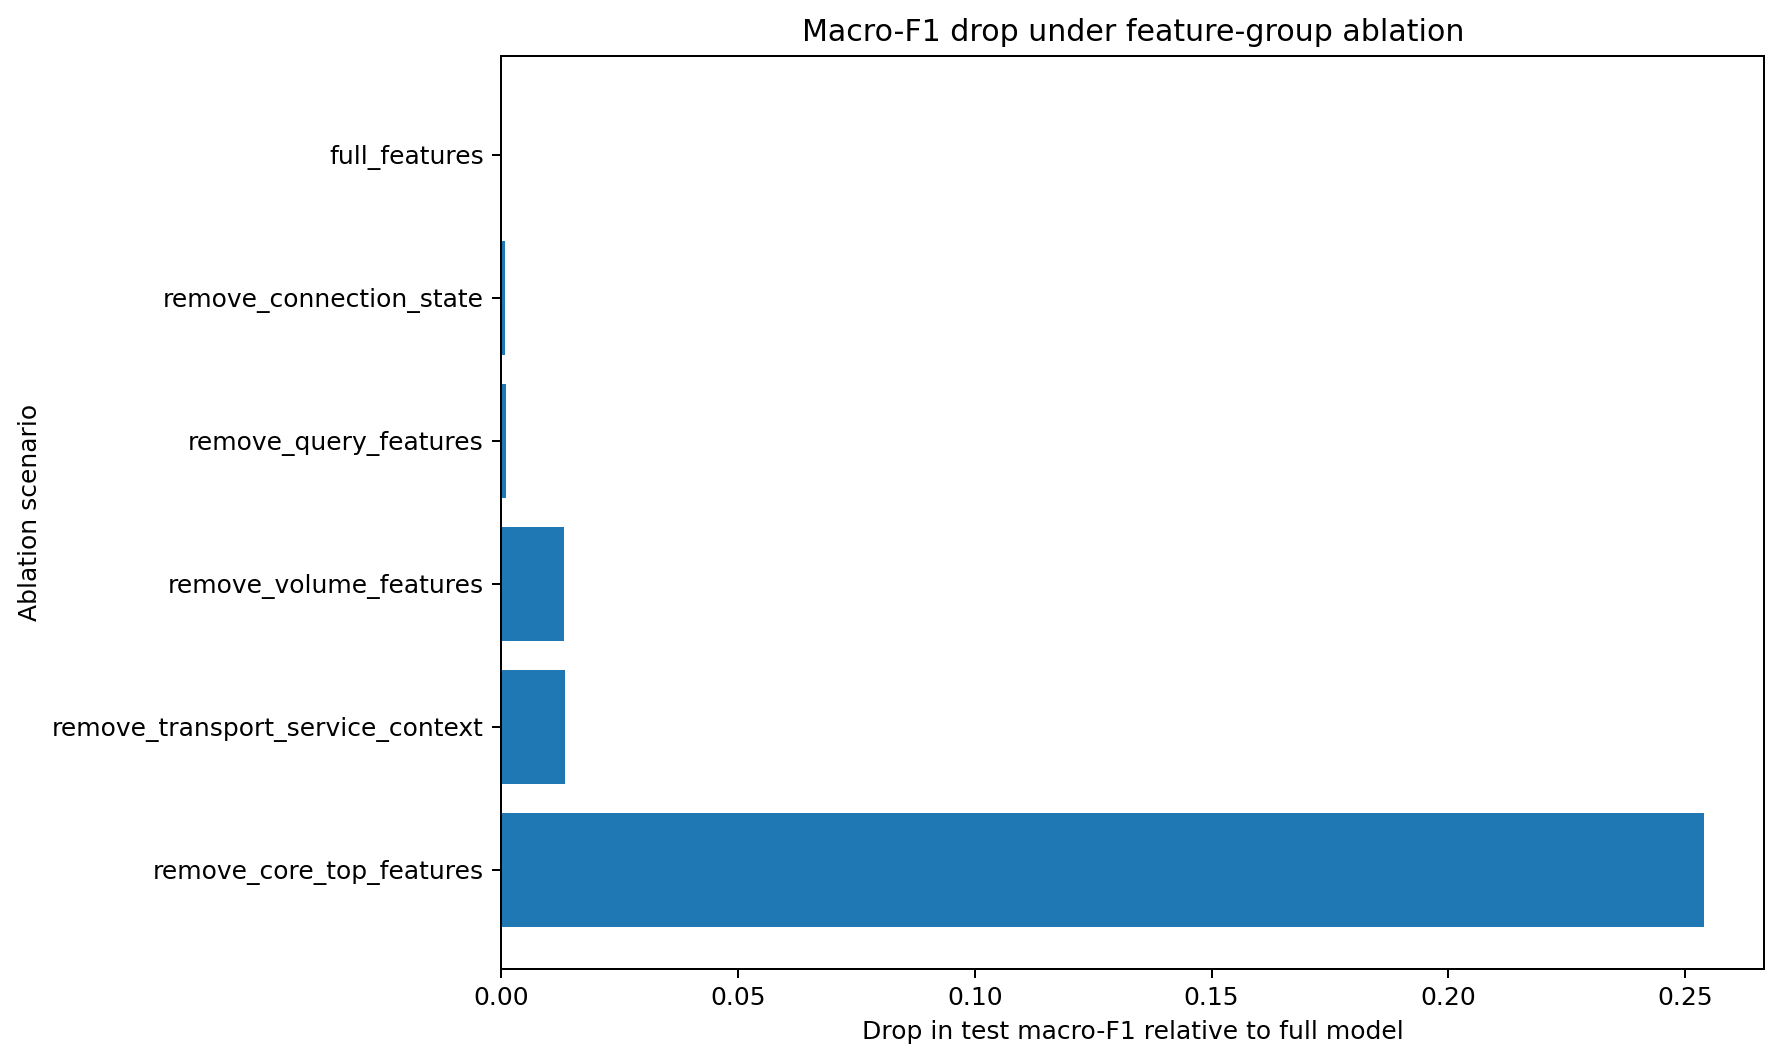


[Saved outputs]
Directory: ablation_study_outputs
Plot files:
ablation_study_outputs\figures\ablation_macro_f1_drop.png
ablation_study_outputs\figures\ablation_macro_f1_drop.pdf

[Step 15 summary]
{
  "ablation_model": "lightgbm",
  "full_model_test_macro_f1": 0.9910075088916381,
  "full_model_test_accuracy": 0.9921081109615435,
  "scenarios": [
    {
      "scenario": "full_features",
      "delta_test_acc": 0.0,
      "delta_test_f1_macro": 0.0
    },
    {
      "scenario": "remove_connection_state",
      "delta_test_acc": -0.0006070683875735172,
      "delta_test_f1_macro": -0.0006825700946822
    },
    {
      "scenario": "remove_query_features",
      "delta_test_acc": -0.001372502441470691,
      "delta_test_f1_macro": -0.0010735666033865332
    },
    {
      "scenario": "remove_volume_features",
      "delta_test_acc": -0.012194156306912673,
      "delta_test_f1_macro": -0.01329499173354265
    },
    {
      "scenario": "remove_transport_service_context",
      "delta_test

In [50]:
# STEP 15: FEATURE-GROUP ABLATION STUDY (FINAL MODEL CONSISTENT)
# - uses LightGBM (selected final model)
# - tests dependence on major feature groups


import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

print("=" * 80)
print("STEP 15: FEATURE-GROUP ABLATION STUDY")
print("=" * 80)

t0 = time.perf_counter()

OUT_DIR = "ablation_study_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Safety checks
required_vars = [
    "X_train_raw", "X_val_raw", "X_test_raw",
    "y_train", "y_val", "y_test",
    "inv_label_mapping"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found."

try:
    from lightgbm import LGBMClassifier
except Exception as e:
    raise ImportError(f"LightGBM not available: {e}")


# Frequency encoder
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_maps_ = {}
        self.columns_ = []

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)
        self.freq_maps_ = {}

        n = len(X)
        for c in self.columns_:
            s = X[c].astype(str)
            vc = s.value_counts(dropna=False)
            self.freq_maps_[c] = (vc / max(n, 1)).to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = np.zeros((len(X), len(self.columns_)), dtype=float)

        for j, c in enumerate(self.columns_):
            fmap = self.freq_maps_.get(c, {})
            out[:, j] = X[c].astype(str).map(fmap).fillna(0.0).astype(float).to_numpy()

        return out


# Evaluation helper
def evaluate_multiclass(model, X, y):
    y_pred = model.predict(X)

    res = {
        "acc": accuracy_score(y, y_pred),
        "f1_macro": f1_score(y, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y, y_pred, average="weighted", zero_division=0),
        "prec_macro": precision_score(y, y_pred, average="macro", zero_division=0),
        "rec_macro": recall_score(y, y_pred, average="macro", zero_division=0),
        "roc_auc_ovr_macro": np.nan
    }

    if hasattr(model, "predict_proba"):
        try:
            y_proba = model.predict_proba(X)
            res["roc_auc_ovr_macro"] = roc_auc_score(
                y, y_proba, multi_class="ovr", average="macro"
            )
        except Exception:
            pass

    return res

# Build LightGBM pipeline for arbitrary feature subset
def build_lgbm_pipeline_for_features(X_train_subset):
    numeric_cols_local = X_train_subset.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols_local = X_train_subset.select_dtypes(exclude=[np.number]).columns.tolist()

    log_transform_candidates = [
        "duration", "src_bytes", "dst_bytes", "missed_bytes",
        "src_pkts", "src_ip_bytes", "dst_pkts", "dst_ip_bytes",
        "http_request_body_len", "http_response_body_len"
    ]
    log_num_cols = [c for c in log_transform_candidates if c in numeric_cols_local]
    plain_num_cols = [c for c in numeric_cols_local if c not in log_num_cols]

    cat_cardinality = pd.DataFrame({
        "column": categorical_cols_local,
        "n_unique": [X_train_subset[c].nunique(dropna=False) for c in categorical_cols_local]
    }).sort_values(by="n_unique", ascending=False)

    HIGH_CARD_THRESHOLD = 50
    high_card_cat_cols_local = cat_cardinality.loc[
        cat_cardinality["n_unique"] > HIGH_CARD_THRESHOLD, "column"
    ].tolist()

    low_mid_card_cat_cols_local = cat_cardinality.loc[
        cat_cardinality["n_unique"] <= HIGH_CARD_THRESHOLD, "column"
    ].tolist()

    log_num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, validate=False))
    ])

    plain_num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    ohe_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])

    freq_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("freq", FrequencyEncoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("log_num", log_num_pipe, log_num_cols),
            ("plain_num", plain_num_pipe, plain_num_cols),
            ("lowmid_cat", ohe_pipe, low_mid_card_cat_cols_local),
            ("high_cat", freq_pipe, high_card_cat_cols_local),
        ],
        remainder="drop"
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", LGBMClassifier(
            objective="multiclass",
            n_estimators=250,
            learning_rate=0.1,
            num_leaves=31,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced",
            verbose=-1
        ))
    ])

    feature_meta = {
        "numeric_cols": numeric_cols_local,
        "categorical_cols": categorical_cols_local,
        "log_num_cols": log_num_cols,
        "plain_num_cols": plain_num_cols,
        "high_card_cat_cols": high_card_cat_cols_local,
        "low_mid_card_cat_cols": low_mid_card_cat_cols_local
    }

    return model, feature_meta


# Define ablation scenarios
ABLATION_SCENARIOS = {
    "full_features": [],
    "remove_transport_service_context": ["src_port", "dst_port", "service", "proto"],
    "remove_volume_features": ["src_ip_bytes", "src_bytes", "dst_ip_bytes", "dst_pkts", "src_pkts", "dst_bytes"],
    "remove_connection_state": ["conn_state"],
    "remove_query_features": ["dns_query", "dns_qtype", "dns_qclass", "dns_rcode", "dns_AA", "dns_RD", "dns_RA", "dns_rejected"],
    "remove_core_top_features": ["conn_state", "src_ip_bytes", "src_port", "dst_port", "duration", "service"]
}

print("\n[Ablation scenarios]")
for k, v in ABLATION_SCENARIOS.items():
    print(f"{k}: {v}")


# Train/evaluate each scenario
ablation_rows = []

for scenario_name, remove_cols in ABLATION_SCENARIOS.items():
    print("\n" + "-" * 80)
    print("Running ablation scenario:", scenario_name)
    print("Removed columns:", remove_cols if remove_cols else "None")

    X_train_ab = X_train_raw.drop(columns=[c for c in remove_cols if c in X_train_raw.columns], errors="ignore").copy()
    X_val_ab   = X_val_raw.drop(columns=[c for c in remove_cols if c in X_val_raw.columns], errors="ignore").copy()
    X_test_ab  = X_test_raw.drop(columns=[c for c in remove_cols if c in X_test_raw.columns], errors="ignore").copy()

    model_ab, feature_meta = build_lgbm_pipeline_for_features(X_train_ab)

    print("Remaining features:", X_train_ab.shape[1])
    print("Numeric features  :", len(feature_meta["numeric_cols"]))
    print("Categorical feats :", len(feature_meta["categorical_cols"]))

    # fit on train
    t_fit0 = time.perf_counter()
    model_ab.fit(X_train_ab, y_train)
    fit_s = time.perf_counter() - t_fit0

    # validation metrics
    val_res = evaluate_multiclass(model_ab, X_val_ab, y_val)

    # refit on train+val
    X_trainval_ab = pd.concat([X_train_ab, X_val_ab], axis=0).reset_index(drop=True)
    y_trainval_ab = pd.concat([pd.Series(y_train), pd.Series(y_val)], axis=0).reset_index(drop=True)

    t_refit0 = time.perf_counter()
    model_ab.fit(X_trainval_ab, y_trainval_ab)
    refit_s = time.perf_counter() - t_refit0

    # test metrics
    t_test0 = time.perf_counter()
    test_res = evaluate_multiclass(model_ab, X_test_ab, y_test)
    test_eval_s = time.perf_counter() - t_test0

    ablation_rows.append({
        "scenario": scenario_name,
        "removed_columns": ", ".join(remove_cols) if remove_cols else "None",
        "remaining_feature_count": X_train_ab.shape[1],

        "val_acc": val_res["acc"],
        "val_f1_macro": val_res["f1_macro"],
        "val_f1_weighted": val_res["f1_weighted"],
        "val_prec_macro": val_res["prec_macro"],
        "val_rec_macro": val_res["rec_macro"],
        "val_roc_auc_ovr_macro": val_res["roc_auc_ovr_macro"],

        "test_acc": test_res["acc"],
        "test_f1_macro": test_res["f1_macro"],
        "test_f1_weighted": test_res["f1_weighted"],
        "test_prec_macro": test_res["prec_macro"],
        "test_rec_macro": test_res["rec_macro"],
        "test_roc_auc_ovr_macro": test_res["roc_auc_ovr_macro"],

        "fit_s": fit_s,
        "refit_s": refit_s,
        "test_eval_s": test_eval_s
    })

    print(f"Validation macro-F1 : {val_res['f1_macro']:.6f}")
    print(f"Test macro-F1       : {test_res['f1_macro']:.6f}")
    print(f"Test accuracy       : {test_res['acc']:.6f}")


# Build results table
ablation_df = pd.DataFrame(ablation_rows)

full_row = ablation_df[ablation_df["scenario"] == "full_features"].iloc[0]

for col in ["test_acc", "test_f1_macro", "test_f1_weighted", "test_roc_auc_ovr_macro"]:
    ablation_df[f"delta_{col}"] = ablation_df[col] - full_row[col]

ablation_df = ablation_df.sort_values(by="test_f1_macro", ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("[ABLATION RESULTS TABLE]")
print("=" * 80)
print(ablation_df)


# Compact table
ablation_compact_df = ablation_df[[
    "scenario",
    "removed_columns",
    "remaining_feature_count",
    "test_acc",
    "test_f1_macro",
    "test_f1_weighted",
    "test_roc_auc_ovr_macro",
    "delta_test_acc",
    "delta_test_f1_macro"
]].copy()

print("\n[Compact ablation summary]")
print(ablation_compact_df)


# Plot macro-F1 drop
plot_df = ablation_df.copy()
plot_df["f1_drop_vs_full"] = full_row["test_f1_macro"] - plot_df["test_f1_macro"]

plt.figure(figsize=(10, 6), dpi=180)
plt.barh(plot_df["scenario"][::-1], plot_df["f1_drop_vs_full"][::-1])
plt.title("Macro-F1 drop under feature-group ablation")
plt.xlabel("Drop in test macro-F1 relative to full model")
plt.ylabel("Ablation scenario")
plt.tight_layout()

plot_png = os.path.join(FIG_DIR, "ablation_macro_f1_drop.png")
plot_pdf = os.path.join(FIG_DIR, "ablation_macro_f1_drop.pdf")
plt.savefig(plot_png, bbox_inches="tight")
plt.savefig(plot_pdf, bbox_inches="tight")
plt.show()


# Save results
ablation_df.to_csv(os.path.join(OUT_DIR, "ablation_results_full.csv"), index=False)
ablation_compact_df.to_csv(os.path.join(OUT_DIR, "ablation_results_compact.csv"), index=False)

step15_summary = {
    "ablation_model": "lightgbm",
    "full_model_test_macro_f1": float(full_row["test_f1_macro"]),
    "full_model_test_accuracy": float(full_row["test_acc"]),
    "scenarios": ablation_df[["scenario", "delta_test_acc", "delta_test_f1_macro"]].to_dict(orient="records"),
    "plot_files": [plot_png, plot_pdf]
}

with open(os.path.join(OUT_DIR, "step15_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step15_summary, f, indent=2)

t_step9 = time.perf_counter() - t0

print("\n[Saved outputs]")
print("Directory:", OUT_DIR)
print("Plot files:")
print(plot_png)
print(plot_pdf)

print("\n[Step 15 summary]")
print(json.dumps(step15_summary, indent=2))

print(f"\nSTEP 15 completed successfully in {t_step9:.4f} seconds.")

In [51]:
# STEP 16: Experimental environment information

import os
import sys
import json
import platform
import psutil

print("=" * 80)
print("STEP 16: EXPERIMENTAL ENVIRONMENT INFORMATION")
print("=" * 80)

OUT_DIR = "environment_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

env_summary = {}

env_summary["operating_system"] = {
    "system": platform.system(),
    "release": platform.release(),
    "version": platform.version(),
    "machine": platform.machine(),
    "processor": platform.processor()
}

env_summary["cpu"] = {
    "physical_cores": psutil.cpu_count(logical=False),
    "logical_cores": psutil.cpu_count(logical=True),
    "frequency": str(psutil.cpu_freq())
}

ram = psutil.virtual_memory()
env_summary["memory"] = {
    "total_ram_gb": round(ram.total / (1024 ** 3), 2),
    "available_ram_gb": round(ram.available / (1024 ** 3), 2)
}

env_summary["python"] = {
    "version": sys.version,
    "executable": sys.executable
}

env_summary["working_directory"] = os.getcwd()

# Key library versions
library_versions = {}

try:
    import numpy
    library_versions["numpy"] = numpy.__version__
except Exception:
    library_versions["numpy"] = "not installed"

try:
    import pandas
    library_versions["pandas"] = pandas.__version__
except Exception:
    library_versions["pandas"] = "not installed"

try:
    import sklearn
    library_versions["scikit_learn"] = sklearn.__version__
except Exception:
    library_versions["scikit_learn"] = "not installed"

try:
    import matplotlib
    library_versions["matplotlib"] = matplotlib.__version__
except Exception:
    library_versions["matplotlib"] = "not installed"

try:
    import networkx
    library_versions["networkx"] = networkx.__version__
except Exception:
    library_versions["networkx"] = "not installed"

try:
    import lightgbm
    library_versions["lightgbm"] = lightgbm.__version__
except Exception:
    library_versions["lightgbm"] = "not installed"

try:
    import xgboost
    library_versions["xgboost"] = xgboost.__version__
except Exception:
    library_versions["xgboost"] = "not installed"

try:
    import shap
    library_versions["shap"] = shap.__version__
except Exception:
    library_versions["shap"] = "not installed"

try:
    import scipy
    library_versions["scipy"] = scipy.__version__
except Exception:
    library_versions["scipy"] = "not installed"

try:
    import torch
    library_versions["torch"] = torch.__version__
    env_summary["gpu"] = {
        "torch_cuda_available": bool(torch.cuda.is_available()),
        "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
    }
except Exception:
    library_versions["torch"] = "not installed"
    env_summary["gpu"] = {
        "torch_cuda_available": False,
        "cuda_device": None
    }

env_summary["library_versions"] = library_versions

print("\n[Operating system]")
print(json.dumps(env_summary["operating_system"], indent=2))

print("\n[CPU]")
print(json.dumps(env_summary["cpu"], indent=2))

print("\n[Memory]")
print(json.dumps(env_summary["memory"], indent=2))

print("\n[Python]")
print(json.dumps(env_summary["python"], indent=2))

print("\n[Key library versions]")
print(json.dumps(env_summary["library_versions"], indent=2))

print("\n[GPU]")
print(json.dumps(env_summary["gpu"], indent=2))

env_path = os.path.join(OUT_DIR, "experimental_environment_summary.json")
with open(env_path, "w", encoding="utf-8") as f:
    json.dump(env_summary, f, indent=2)

print("\n[Saved artifact]")
print(env_path)

print("\nSTEP 16 completed successfully.")

STEP 16: EXPERIMENTAL ENVIRONMENT INFORMATION

[Operating system]
{
  "system": "Windows",
  "release": "10",
  "version": "10.0.26200",
  "machine": "AMD64",
  "processor": "Intel64 Family 6 Model 151 Stepping 2, GenuineIntel"
}

[CPU]
{
  "physical_cores": 16,
  "logical_cores": 24,
  "frequency": "scpufreq(current=2100.0, min=0.0, max=2100.0)"
}

[Memory]
{
  "total_ram_gb": 63.69,
  "available_ram_gb": 33.91
}

[Python]
{
  "version": "3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]",
  "executable": "C:\\Users\\amala\\anaconda3\\envs\\deepfake\\python.exe"
}

[Key library versions]
{
  "numpy": "2.2.5",
  "pandas": "2.3.3",
  "scikit_learn": "1.7.2",
  "matplotlib": "3.10.8",
  "networkx": "3.4.2",
  "lightgbm": "4.6.0",
  "xgboost": "3.2.0",
  "shap": "0.49.1",
  "scipy": "1.15.3",
  "torch": "2.11.0+cu126"
}

[GPU]
{
  "torch_cuda_available": true,
  "cuda_device": "NVIDIA RTX A1000 Laptop GPU"
}

[Saved artifact]
environment_outp

STEP 17: REALISTIC BINARY BENIGN-MAJORITY EVALUATION

[Binary dataset]
Shape: (190474, 45)
Binary class distribution:
binary_target
1    148434
0     42040
Name: count, dtype: int64
binary_target
1    77.9287
0    22.0713
Name: proportion, dtype: float64

[Pool sizes]
Benign pool: 42040
Attack pool: 148434

[Balanced training/validation design]
Train per class: 20000
Val per class  : 5000
Remaining benign pool: 17040
Remaining attack pool: 123434

[Balanced train/val shapes]
X_train_bin: (40000, 40)
X_val_bin  : (10000, 40)

[Imbalanced test scenario shapes]
95:5 test shape: (18040, 40) | benign ratio: 0.9446
99:1 test shape: (17240, 40) | benign ratio: 0.9884

[Binary model fitted]
Fit time (s): 0.9795

[Default threshold metrics @ 0.5]
   threshold  accuracy        f1  precision  recall_tpr  specificity       fpr  tpr   roc_auc    pr_auc     tn  fp  fn    tp            scenario  pred_time_s  pred_ms_per_sample
0        0.5  0.997838  0.980873   0.962464         1.0     0.997711  0.00

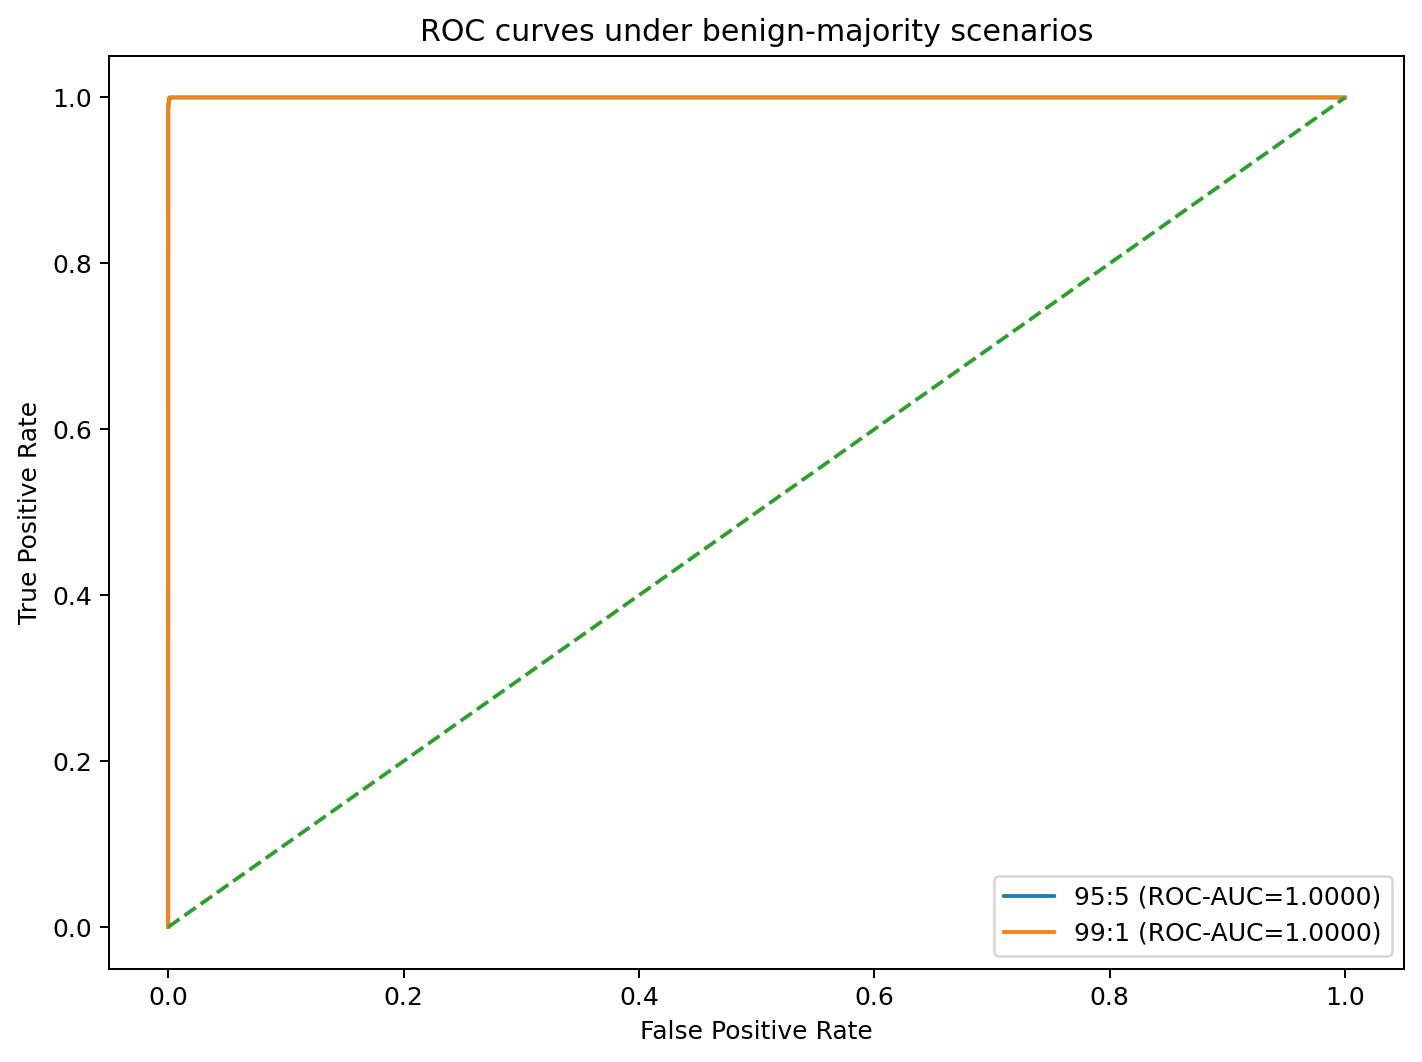

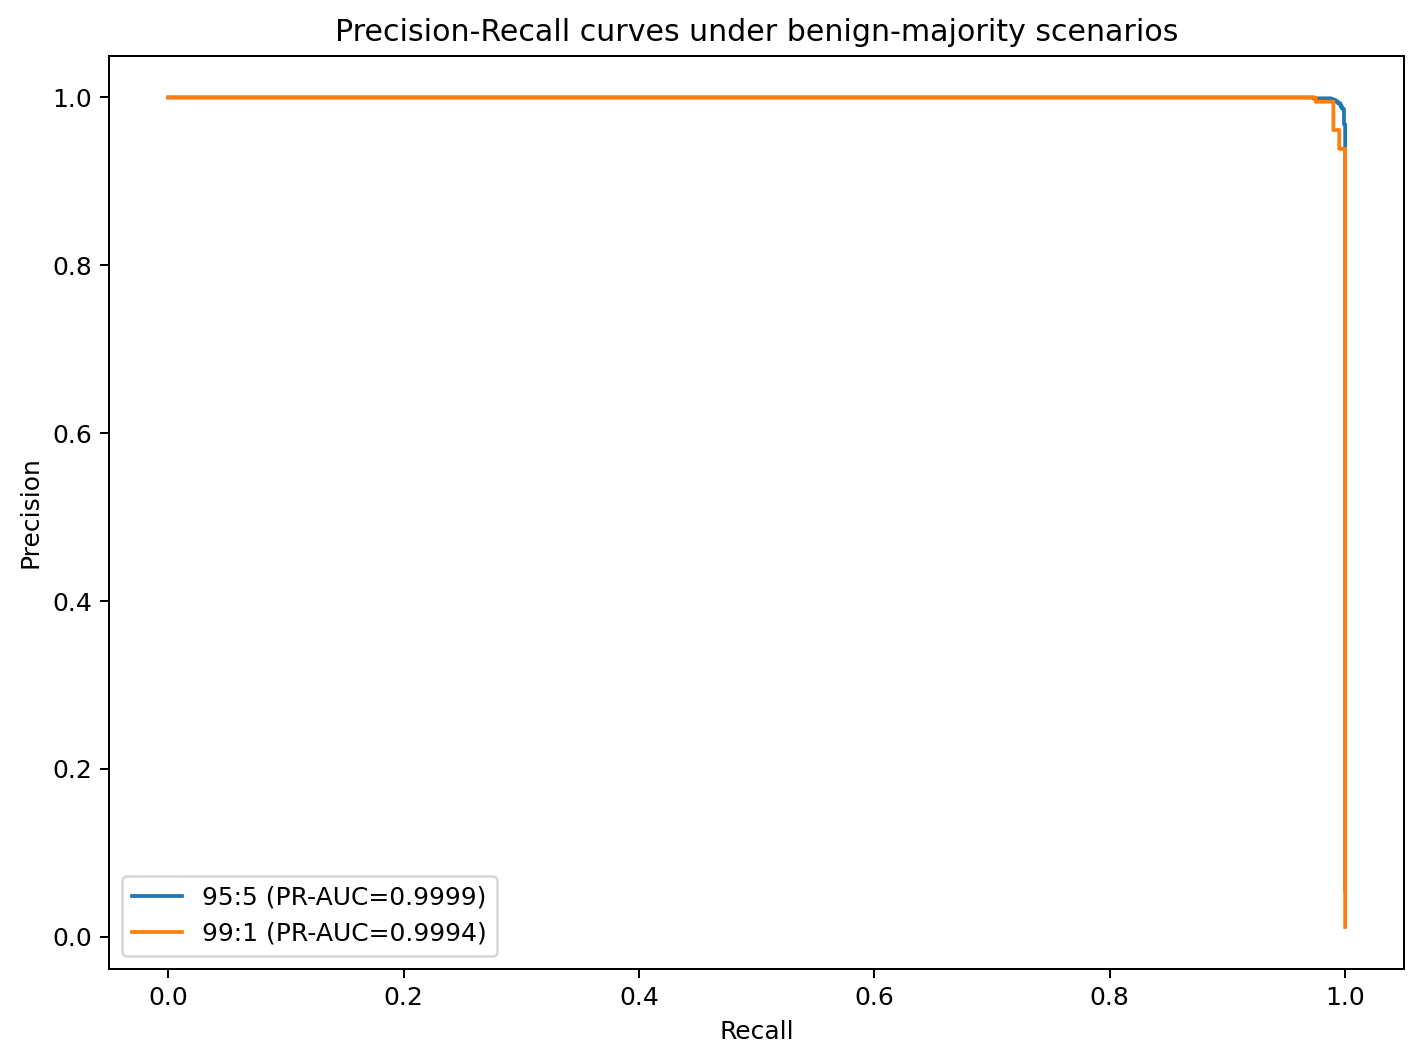


[Default metrics table]
   threshold  accuracy        f1  precision  recall_tpr  specificity       fpr  tpr   roc_auc    pr_auc     tn  fp  fn    tp            scenario  pred_time_s  pred_ms_per_sample
0        0.5  0.997838  0.980873   0.962464         1.0     0.997711  0.002289  1.0  0.999993  0.999882  17001  39   0  1000  95_5_benign_attack     0.196567            0.010896
1        0.5  0.997738  0.911162   0.836820         1.0     0.997711  0.002289  1.0  0.999993  0.999426  17001  39   0   200  99_1_benign_attack     0.127911            0.007419

[Target-TPR threshold table]
     scenario  target_tpr  threshold  achieved_tpr  achieved_fpr
0  95:5_tpr95        0.95   0.999986         0.956      0.000000
1  95:5_tpr99        0.99   0.999824         0.990      0.000117
2  99:1_tpr95        0.95   0.999980         0.975      0.000000
3  99:1_tpr99        0.99   0.999941         0.990      0.000059

[FPR-constrained threshold table]
       scenario  threshold  accuracy        f1  pre

In [52]:
# STEP 17: REALISTIC BINARY BENIGN-MAJORITY EVALUATION
# - 95:5 and 99:1 benign:attack test scenarios
# - LightGBM binary detector
# - PR-AUC, ROC-AUC, FPR at fixed TPR, threshold tuning

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

print("=" * 80)
print("STEP 17: REALISTIC BINARY BENIGN-MAJORITY EVALUATION")
print("=" * 80)

t0 = time.perf_counter()

OUT_DIR = "binary_benign_majority_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Safety checks
required_vars = ["df_work"]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found. Run previous steps first."

try:
    from lightgbm import LGBMClassifier
except Exception as e:
    raise ImportError(f"LightGBM not available: {e}")

# Frequency encoder
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_maps_ = {}
        self.columns_ = []

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)
        self.freq_maps_ = {}

        n = len(X)
        for c in self.columns_:
            s = X[c].astype(str)
            vc = s.value_counts(dropna=False)
            self.freq_maps_[c] = (vc / max(n, 1)).to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = np.zeros((len(X), len(self.columns_)), dtype=float)

        for j, c in enumerate(self.columns_):
            fmap = self.freq_maps_.get(c, {})
            out[:, j] = X[c].astype(str).map(fmap).fillna(0.0).astype(float).to_numpy()

        return out


# Build binary dataset from deduplicated data
df_bin = df_work.copy().reset_index(drop=True)
df_bin["binary_target"] = pd.to_numeric(df_bin["label"], errors="coerce").fillna(-1).astype(int)

print("\n[Binary dataset]")
print("Shape:", df_bin.shape)
print("Binary class distribution:")
print(df_bin["binary_target"].value_counts())
print((100 * df_bin["binary_target"].value_counts(normalize=True)).round(4))


# Preserve context columns

CONTEXT_COLS_BIN = [c for c in [
    "src_ip", "dst_ip", "src_port", "dst_port", "proto", "service", "conn_state"
] if c in df_bin.columns]


# Feature exclusions

DROP_FROM_FEATURES_BIN = [c for c in [
    "type",
    "label",
    "binary_target",
    "src_ip",
    "dst_ip"
] if c in df_bin.columns]

X_bin_raw = df_bin.drop(columns=DROP_FROM_FEATURES_BIN, errors="ignore").copy()
y_bin = df_bin["binary_target"].copy()

obj_cols_bin = X_bin_raw.select_dtypes(include=["object", "string"]).columns.tolist()
for c in obj_cols_bin:
    X_bin_raw[c] = X_bin_raw[c].astype(str).str.strip()
    X_bin_raw[c] = X_bin_raw[c].replace({"-": "MISSING_TOKEN", "": "MISSING_TOKEN", "nan": "MISSING_TOKEN"})


# Split into benign and attack pools
# Use random row split here for deployment-style class ratio simulation
# The grouped binary split from Step 2C remains your leakage-resistant branch

BENIGN_CLASS = 0
ATTACK_CLASS = 1

benign_idx = np.where(y_bin.values == BENIGN_CLASS)[0]
attack_idx = np.where(y_bin.values == ATTACK_CLASS)[0]

rng = np.random.default_rng(42)
rng.shuffle(benign_idx)
rng.shuffle(attack_idx)

print("\n[Pool sizes]")
print("Benign pool:", len(benign_idx))
print("Attack pool:", len(attack_idx))


# Build a reasonably balanced training set
# and separate imbalanced test scenarios

N_TRAIN_PER_CLASS = min(20000, len(benign_idx) // 2, len(attack_idx) // 4)
N_VAL_PER_CLASS = min(5000, len(benign_idx) // 6, len(attack_idx) // 10)

assert N_TRAIN_PER_CLASS > 1000, "Not enough data for stable balanced training."
assert N_VAL_PER_CLASS > 500, "Not enough data for stable validation."

train_benign_idx = benign_idx[:N_TRAIN_PER_CLASS]
val_benign_idx   = benign_idx[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS]

train_attack_idx = attack_idx[:N_TRAIN_PER_CLASS]
val_attack_idx   = attack_idx[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS]

used_idx = set(train_benign_idx) | set(val_benign_idx) | set(train_attack_idx) | set(val_attack_idx)

remaining_benign_idx = np.array([i for i in benign_idx if i not in used_idx], dtype=int)
remaining_attack_idx = np.array([i for i in attack_idx if i not in used_idx], dtype=int)

print("\n[Balanced training/validation design]")
print("Train per class:", N_TRAIN_PER_CLASS)
print("Val per class  :", N_VAL_PER_CLASS)
print("Remaining benign pool:", len(remaining_benign_idx))
print("Remaining attack pool:", len(remaining_attack_idx))


# Construct train and val
train_idx = np.concatenate([train_benign_idx, train_attack_idx])
val_idx   = np.concatenate([val_benign_idx, val_attack_idx])

rng.shuffle(train_idx)
rng.shuffle(val_idx)

X_train_bin = X_bin_raw.iloc[train_idx].reset_index(drop=True)
y_train_bin = y_bin.iloc[train_idx].reset_index(drop=True)

X_val_bin   = X_bin_raw.iloc[val_idx].reset_index(drop=True)
y_val_bin   = y_bin.iloc[val_idx].reset_index(drop=True)

ctx_train_bin_realistic = df_bin.iloc[train_idx][CONTEXT_COLS_BIN].reset_index(drop=True)
ctx_val_bin_realistic   = df_bin.iloc[val_idx][CONTEXT_COLS_BIN].reset_index(drop=True)

print("\n[Balanced train/val shapes]")
print("X_train_bin:", X_train_bin.shape)
print("X_val_bin  :", X_val_bin.shape)


# Construct imbalanced test sets
def make_imbalanced_test_set(benign_ratio=0.95, total_size=20000, seed=42):
    rng_local = np.random.default_rng(seed)

    n_benign = int(round(total_size * benign_ratio))
    n_attack = total_size - n_benign

    n_benign = min(n_benign, len(remaining_benign_idx))
    n_attack = min(n_attack, len(remaining_attack_idx))

    idx_b = rng_local.choice(remaining_benign_idx, size=n_benign, replace=False)
    idx_a = rng_local.choice(remaining_attack_idx, size=n_attack, replace=False)

    idx = np.concatenate([idx_b, idx_a])
    rng_local.shuffle(idx)

    X = X_bin_raw.iloc[idx].reset_index(drop=True)
    y = y_bin.iloc[idx].reset_index(drop=True)
    ctx = df_bin.iloc[idx][CONTEXT_COLS_BIN].reset_index(drop=True)

    return X, y, ctx, idx

X_test_95, y_test_95, ctx_test_95, idx_test_95 = make_imbalanced_test_set(benign_ratio=0.95, total_size=20000, seed=42)
X_test_99, y_test_99, ctx_test_99, idx_test_99 = make_imbalanced_test_set(benign_ratio=0.99, total_size=20000, seed=43)

print("\n[Imbalanced test scenario shapes]")
print("95:5 test shape:", X_test_95.shape, "| benign ratio:", round((y_test_95 == 0).mean(), 4))
print("99:1 test shape:", X_test_99.shape, "| benign ratio:", round((y_test_99 == 0).mean(), 4))


# Build binary LightGBM pipeline
def build_binary_lgbm_pipeline(X_train_subset):
    numeric_cols_local = X_train_subset.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols_local = X_train_subset.select_dtypes(exclude=[np.number]).columns.tolist()

    log_transform_candidates = [
        "duration", "src_bytes", "dst_bytes", "missed_bytes",
        "src_pkts", "src_ip_bytes", "dst_pkts", "dst_ip_bytes",
        "http_request_body_len", "http_response_body_len"
    ]
    log_num_cols = [c for c in log_transform_candidates if c in numeric_cols_local]
    plain_num_cols = [c for c in numeric_cols_local if c not in log_num_cols]

    cat_cardinality = pd.DataFrame({
        "column": categorical_cols_local,
        "n_unique": [X_train_subset[c].nunique(dropna=False) for c in categorical_cols_local]
    }).sort_values(by="n_unique", ascending=False)

    HIGH_CARD_THRESHOLD = 50
    high_card_cat_cols_local = cat_cardinality.loc[
        cat_cardinality["n_unique"] > HIGH_CARD_THRESHOLD, "column"
    ].tolist()

    low_mid_card_cat_cols_local = cat_cardinality.loc[
        cat_cardinality["n_unique"] <= HIGH_CARD_THRESHOLD, "column"
    ].tolist()

    log_num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, validate=False))
    ])

    plain_num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    ohe_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])

    freq_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("freq", FrequencyEncoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("log_num", log_num_pipe, log_num_cols),
            ("plain_num", plain_num_pipe, plain_num_cols),
            ("lowmid_cat", ohe_pipe, low_mid_card_cat_cols_local),
            ("high_cat", freq_pipe, high_card_cat_cols_local),
        ],
        remainder="drop"
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", LGBMClassifier(
            objective="binary",
            n_estimators=250,
            learning_rate=0.1,
            num_leaves=31,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced",
            verbose=-1
        ))
    ])

    return model

binary_model = build_binary_lgbm_pipeline(X_train_bin)


# Fit binary model
t_fit0 = time.perf_counter()
binary_model.fit(X_train_bin, y_train_bin)
fit_s = time.perf_counter() - t_fit0

print("\n[Binary model fitted]")
print(f"Fit time (s): {fit_s:.4f}")


# Binary evaluation helpers

def compute_binary_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / max(fp + tn, 1)
    tpr = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "f1": float(f1),
        "precision": float(prec),
        "recall_tpr": float(rec),
        "specificity": float(specificity),
        "fpr": float(fpr),
        "tpr": float(tpr),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

def find_threshold_for_target_tpr(y_true, y_score, target_tpr):
    fpr_arr, tpr_arr, thr_arr = roc_curve(y_true, y_score)
    valid = np.where(tpr_arr >= target_tpr)[0]
    if len(valid) == 0:
        return None

    idx = valid[np.argmin(fpr_arr[valid])]
    return {
        "target_tpr": float(target_tpr),
        "threshold": float(thr_arr[idx]),
        "achieved_tpr": float(tpr_arr[idx]),
        "achieved_fpr": float(fpr_arr[idx])
    }

def find_best_threshold_under_fpr(y_true, y_score, max_fpr=0.01):
    thresholds = np.linspace(0, 1, 1001)
    best = None

    for th in thresholds:
        m = compute_binary_metrics(y_true, y_score, threshold=th)
        if m["fpr"] <= max_fpr:
            if best is None or m["f1"] > best["f1"]:
                best = m

    return best

def evaluate_scenario(model, X, y, scenario_name):
    t_pred0 = time.perf_counter()
    y_score = model.predict_proba(X)[:, 1]
    pred_s = time.perf_counter() - t_pred0

    default_metrics = compute_binary_metrics(y, y_score, threshold=0.5)
    default_metrics["scenario"] = scenario_name
    default_metrics["pred_time_s"] = float(pred_s)
    default_metrics["pred_ms_per_sample"] = float(1000 * pred_s / len(X))

    tpr95 = find_threshold_for_target_tpr(y, y_score, target_tpr=0.95)
    tpr99 = find_threshold_for_target_tpr(y, y_score, target_tpr=0.99)
    best_under_fpr_1pct = find_best_threshold_under_fpr(y, y_score, max_fpr=0.01)

    precision_arr, recall_arr, pr_thresholds = precision_recall_curve(y, y_score)
    fpr_arr, tpr_arr, roc_thresholds = roc_curve(y, y_score)

    curves = {
        "precision": precision_arr,
        "recall": recall_arr,
        "pr_thresholds": pr_thresholds,
        "fpr": fpr_arr,
        "tpr": tpr_arr,
        "roc_thresholds": roc_thresholds
    }

    return default_metrics, tpr95, tpr99, best_under_fpr_1pct, curves, y_score


# Evaluate 95:5 and 99:1 scenarios
default_95, tpr95_95, tpr99_95, best_fpr1_95, curves_95, y_score_95 = evaluate_scenario(
    binary_model, X_test_95, y_test_95, "95_5_benign_attack"
)
default_99, tpr95_99, tpr99_99, best_fpr1_99, curves_99, y_score_99 = evaluate_scenario(
    binary_model, X_test_99, y_test_99, "99_1_benign_attack"
)

print("\n[Default threshold metrics @ 0.5]")
print(pd.DataFrame([default_95, default_99]))

print("\n[Thresholds for target TPR]")
print("95:5 @ TPR>=0.95:", tpr95_95)
print("95:5 @ TPR>=0.99:", tpr99_95)
print("99:1 @ TPR>=0.95:", tpr95_99)
print("99:1 @ TPR>=0.99:", tpr99_99)

print("\n[Best threshold under FPR <= 1%]")
print("95:5:", best_fpr1_95)
print("99:1:", best_fpr1_99)


# Plot ROC curves
OUT_DIR = "binary_benign_majority_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

plt.figure(figsize=(8, 6), dpi=180)
plt.plot(curves_95["fpr"], curves_95["tpr"], label=f"95:5 (ROC-AUC={default_95['roc_auc']:.4f})")
plt.plot(curves_99["fpr"], curves_99["tpr"], label=f"99:1 (ROC-AUC={default_99['roc_auc']:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves under benign-majority scenarios")
plt.legend()
plt.tight_layout()
roc_png = os.path.join(FIG_DIR, "binary_benign_majority_roc.png")
roc_pdf = os.path.join(FIG_DIR, "binary_benign_majority_roc.pdf")
plt.savefig(roc_png, bbox_inches="tight")
plt.savefig(roc_pdf, bbox_inches="tight")
plt.show()


# Plot PR curves
plt.figure(figsize=(8, 6), dpi=180)
plt.plot(curves_95["recall"], curves_95["precision"], label=f"95:5 (PR-AUC={default_95['pr_auc']:.4f})")
plt.plot(curves_99["recall"], curves_99["precision"], label=f"99:1 (PR-AUC={default_99['pr_auc']:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves under benign-majority scenarios")
plt.legend()
plt.tight_layout()
pr_png = os.path.join(FIG_DIR, "binary_benign_majority_pr.png")
pr_pdf = os.path.join(FIG_DIR, "binary_benign_majority_pr.pdf")
plt.savefig(pr_png, bbox_inches="tight")
plt.savefig(pr_pdf, bbox_inches="tight")
plt.show()


# Build summary tables
default_df = pd.DataFrame([default_95, default_99])

threshold_rows = []
for scenario, res in [
    ("95:5_tpr95", tpr95_95),
    ("95:5_tpr99", tpr99_95),
    ("99:1_tpr95", tpr95_99),
    ("99:1_tpr99", tpr99_99),
]:
    if res is not None:
        row = {"scenario": scenario}
        row.update(res)
        threshold_rows.append(row)

threshold_targets_df = pd.DataFrame(threshold_rows)

fpr1_rows = []
for scenario, res in [
    ("95:5_fpr<=1%", best_fpr1_95),
    ("99:1_fpr<=1%", best_fpr1_99),
]:
    if res is not None:
        row = {"scenario": scenario}
        row.update(res)
        fpr1_rows.append(row)

fpr1_df = pd.DataFrame(fpr1_rows)

print("\n[Default metrics table]")
print(default_df)

print("\n[Target-TPR threshold table]")
print(threshold_targets_df)

print("\n[FPR-constrained threshold table]")
print(fpr1_df)


# Save outputs
default_df.to_csv(os.path.join(OUT_DIR, "default_threshold_metrics.csv"), index=False)
threshold_targets_df.to_csv(os.path.join(OUT_DIR, "target_tpr_thresholds.csv"), index=False)
fpr1_df.to_csv(os.path.join(OUT_DIR, "fpr_constrained_thresholds.csv"), index=False)

step17_summary = {
    "binary_model": "lightgbm",
    "fit_time_seconds": float(fit_s),
    "train_shape": list(X_train_bin.shape),
    "val_shape": list(X_val_bin.shape),
    "test_95_shape": list(X_test_95.shape),
    "test_99_shape": list(X_test_99.shape),
    "default_metrics": default_df.to_dict(orient="records"),
    "target_tpr_thresholds": threshold_targets_df.to_dict(orient="records"),
    "fpr_constrained_thresholds": fpr1_df.to_dict(orient="records"),
    "plot_files": [roc_png, roc_pdf, pr_png, pr_pdf]
}

with open(os.path.join(OUT_DIR, "step7_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step17_summary, f, indent=2)

t_step10 = time.perf_counter() - t0

print("\n[Saved outputs]")
print("Directory:", OUT_DIR)
print("Plot files:")
for p in step17_summary["plot_files"]:
    print(p)

print("\n[Step 17 summary]")
print(json.dumps(step17_summary, indent=2))

print(f"\nSTEP 17 completed successfully in {t_step10:.4f} seconds.")

STEP 18: MULTI-SEED STABILITY ANALYSIS

[Seeds]
[7, 21, 42, 84, 168]

--------------------------------------------------------------------------------
[Multiclass] Running seed = 7
Test macro-F1 : 0.991008
Test accuracy : 0.992108
ROC-AUC macro : 0.999911

--------------------------------------------------------------------------------
[Multiclass] Running seed = 21
Test macro-F1 : 0.991008
Test accuracy : 0.992108
ROC-AUC macro : 0.999911

--------------------------------------------------------------------------------
[Multiclass] Running seed = 42
Test macro-F1 : 0.991008
Test accuracy : 0.992108
ROC-AUC macro : 0.999911

--------------------------------------------------------------------------------
[Multiclass] Running seed = 84
Test macro-F1 : 0.991008
Test accuracy : 0.992108
ROC-AUC macro : 0.999911

--------------------------------------------------------------------------------
[Multiclass] Running seed = 168
Test macro-F1 : 0.991008
Test accuracy : 0.992108
ROC-AUC macro : 

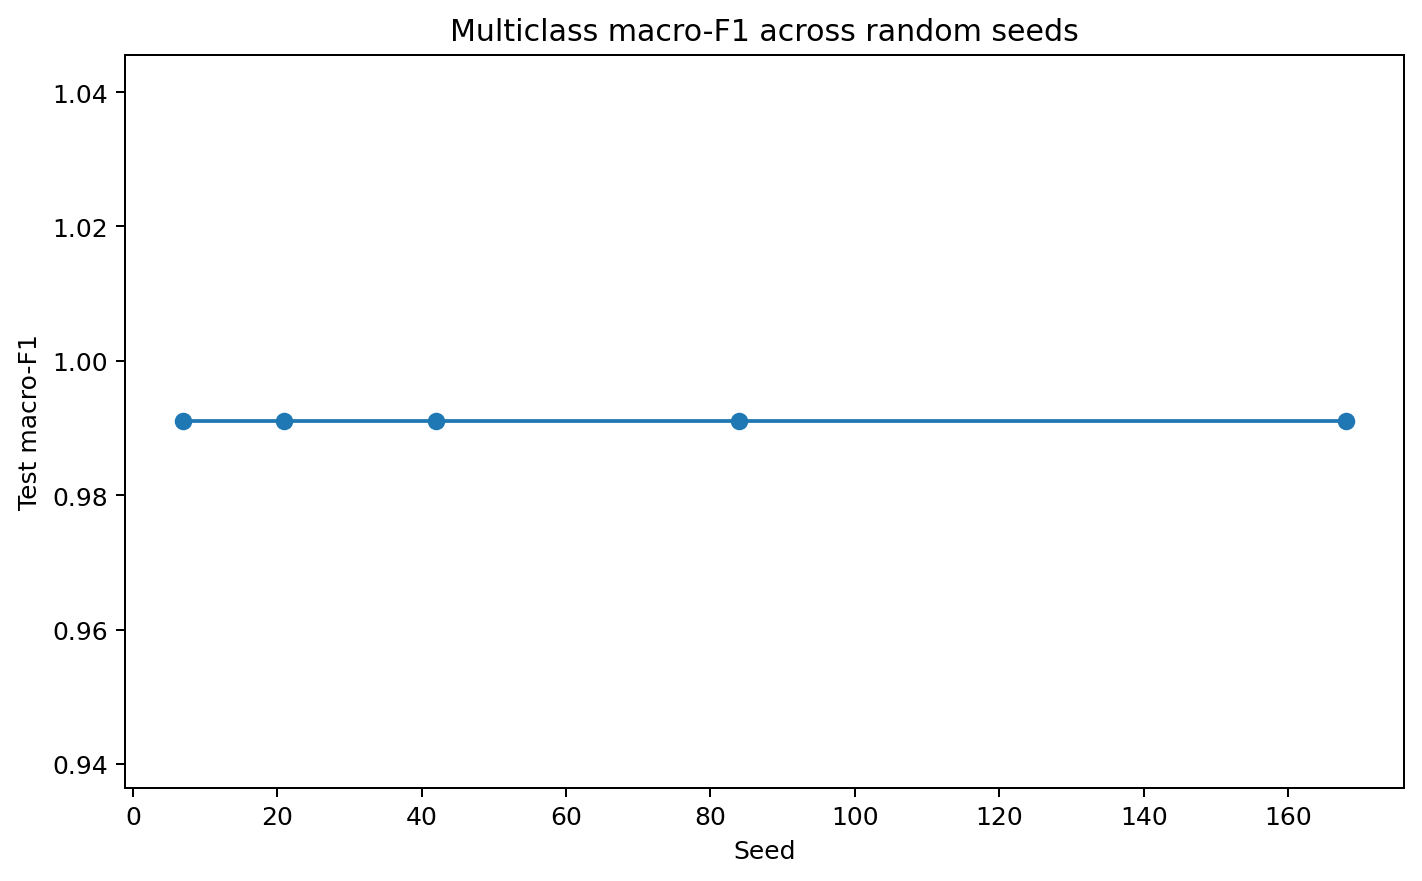

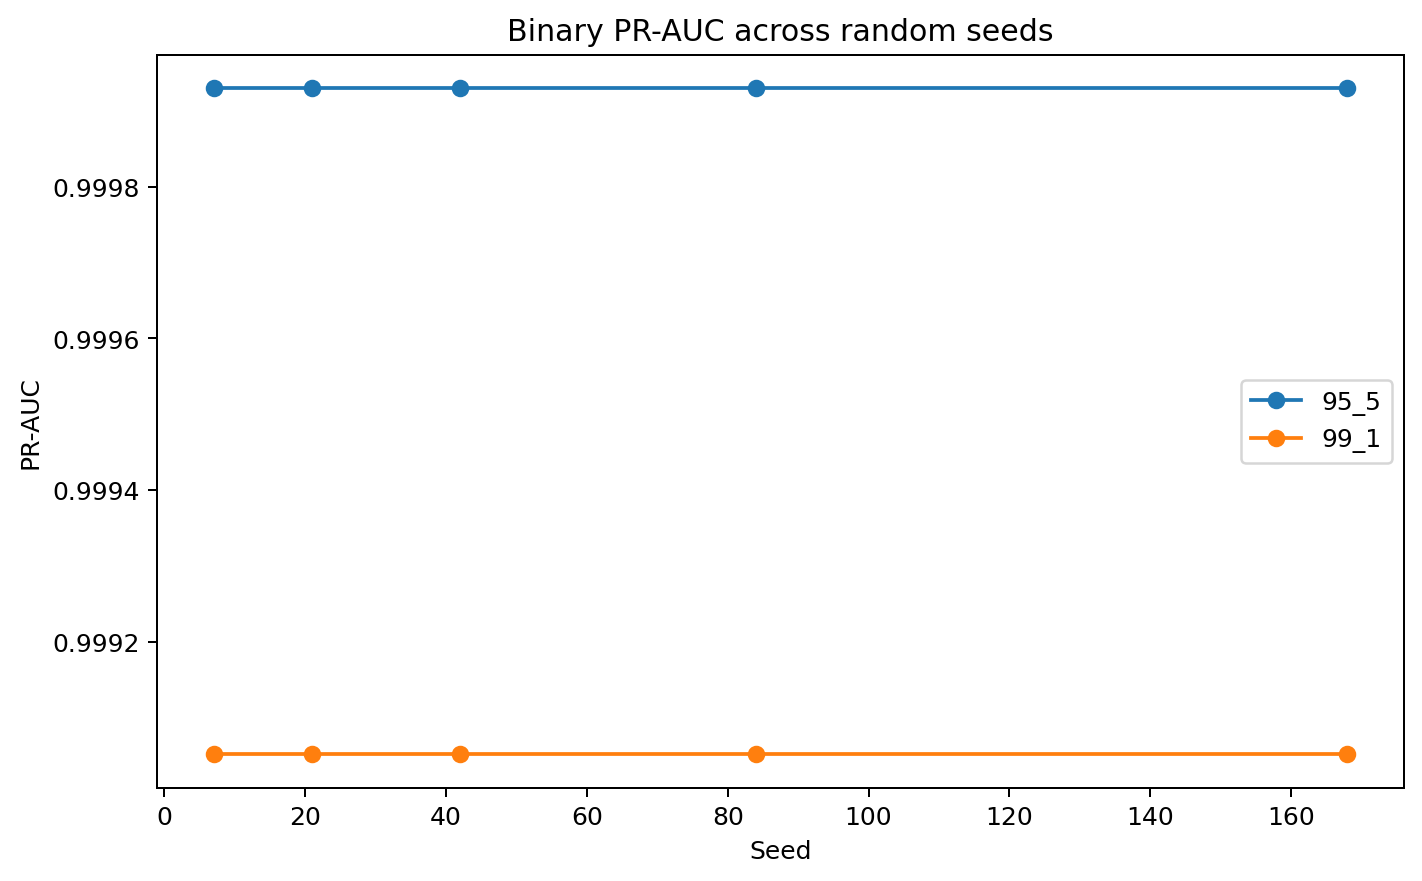


[Saved outputs]
Directory: multiseed_stability_outputs
Plot files:
multiseed_stability_outputs\figures\multiclass_macro_f1_by_seed.png
multiseed_stability_outputs\figures\multiclass_macro_f1_by_seed.pdf
multiseed_stability_outputs\figures\binary_pr_auc_by_seed.png
multiseed_stability_outputs\figures\binary_pr_auc_by_seed.pdf

[Step 18 summary]
{
  "seeds": [
    7,
    21,
    42,
    84,
    168
  ],
  "multiclass_summary": [
    {
      "acc_mean": 0.9921081109615436,
      "acc_std": 1.2412670766236366e-16,
      "f1_macro_mean": 0.9910075088916381,
      "f1_macro_std": 0.0,
      "f1_weighted_mean": 0.9921141822341232,
      "f1_weighted_std": 0.0,
      "prec_macro_mean": 0.9907648637736315,
      "prec_macro_std": 1.2412670766236366e-16,
      "rec_macro_mean": 0.9912817865567758,
      "rec_macro_std": 0.0,
      "roc_auc_ovr_macro_mean": 0.9999108458546873,
      "roc_auc_ovr_macro_std": 0.0,
      "fit_s_mean": 7.488712279993342,
      "fit_s_std": 0.9469506349796252
    }
 

In [53]:
# STEP 18: MULTI-SEED STABILITY ANALYSIS
# - final-model robustness across repeated runs
# - multiclass stability
# - binary 95:5 and 99:1 stability
# - reports mean ± std

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("=" * 80)
print("STEP 18: MULTI-SEED STABILITY ANALYSIS")
print("=" * 80)

t0 = time.perf_counter()

OUT_DIR = "multiseed_stability_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Safety checks
required_vars = [
    # multiclass
    "X_train_raw", "X_val_raw", "X_test_raw",
    "y_train", "y_val", "y_test",
    # binary
    "X_train_bin", "X_val_bin", "X_test_95", "X_test_99",
    "y_train_bin", "y_val_bin", "y_test_95", "y_test_99"
]
for v in required_vars:
    assert v in globals(), f"Required variable '{v}' not found."

try:
    from lightgbm import LGBMClassifier
except Exception as e:
    raise ImportError(f"LightGBM not available: {e}")


# Frequency encoder
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.freq_maps_ = {}
        self.columns_ = []

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)
        self.freq_maps_ = {}

        n = len(X)
        for c in self.columns_:
            s = X[c].astype(str)
            vc = s.value_counts(dropna=False)
            self.freq_maps_[c] = (vc / max(n, 1)).to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = np.zeros((len(X), len(self.columns_)), dtype=float)

        for j, c in enumerate(self.columns_):
            fmap = self.freq_maps_.get(c, {})
            out[:, j] = X[c].astype(str).map(fmap).fillna(0.0).astype(float).to_numpy()

        return out


# Generic pipeline builder
def build_lgbm_pipeline(X_train_subset, objective="multiclass", seed=42):
    numeric_cols_local = X_train_subset.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols_local = X_train_subset.select_dtypes(exclude=[np.number]).columns.tolist()

    log_transform_candidates = [
        "duration", "src_bytes", "dst_bytes", "missed_bytes",
        "src_pkts", "src_ip_bytes", "dst_pkts", "dst_ip_bytes",
        "http_request_body_len", "http_response_body_len"
    ]
    log_num_cols = [c for c in log_transform_candidates if c in numeric_cols_local]
    plain_num_cols = [c for c in numeric_cols_local if c not in log_num_cols]

    cat_cardinality = pd.DataFrame({
        "column": categorical_cols_local,
        "n_unique": [X_train_subset[c].nunique(dropna=False) for c in categorical_cols_local]
    }).sort_values(by="n_unique", ascending=False)

    HIGH_CARD_THRESHOLD = 50
    high_card_cat_cols_local = cat_cardinality.loc[
        cat_cardinality["n_unique"] > HIGH_CARD_THRESHOLD, "column"
    ].tolist()

    low_mid_card_cat_cols_local = cat_cardinality.loc[
        cat_cardinality["n_unique"] <= HIGH_CARD_THRESHOLD, "column"
    ].tolist()

    log_num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, validate=False))
    ])

    plain_num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    ohe_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])

    freq_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("freq", FrequencyEncoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("log_num", log_num_pipe, log_num_cols),
            ("plain_num", plain_num_pipe, plain_num_cols),
            ("lowmid_cat", ohe_pipe, low_mid_card_cat_cols_local),
            ("high_cat", freq_pipe, high_card_cat_cols_local),
        ],
        remainder="drop"
    )

    if objective == "multiclass":
        clf = LGBMClassifier(
        objective="multiclass",
        n_estimators=250,
        learning_rate=0.1,
        num_leaves=31,
        random_state=seed,
        n_jobs=-1,
        class_weight="balanced",
        verbose=-1
    
        )
        
    elif objective == "binary":
        clf = LGBMClassifier(
        objective="binary",
        n_estimators=250,
        learning_rate=0.1,
        num_leaves=31,
        random_state=seed,
        n_jobs=-1,
        class_weight="balanced",
        verbose=-1
        )
        
    else:
        raise ValueError(f"Unsupported objective: {objective}")

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", clf)
    ])

    return model


# Evaluation helpers
def eval_multiclass(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)

    return {
        "acc": accuracy_score(y, y_pred),
        "f1_macro": f1_score(y, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y, y_pred, average="weighted", zero_division=0),
        "prec_macro": precision_score(y, y_pred, average="macro", zero_division=0),
        "rec_macro": recall_score(y, y_pred, average="macro", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_score(y, y_proba, multi_class="ovr", average="macro")
    }

def eval_binary(model, X, y, threshold=0.5):
    y_score = model.predict_proba(X)[:, 1]
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

    return {
        "acc": accuracy_score(y, y_pred),
        "f1": f1_score(y, y_pred, zero_division=0),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall_tpr": recall_score(y, y_pred, zero_division=0),
        "fpr": fp / max(fp + tn, 1),
        "roc_auc": roc_auc_score(y, y_score),
        "pr_auc": average_precision_score(y, y_score)
    }


# Seed list
SEEDS = [7, 21, 42, 84, 168]

print("\n[Seeds]")
print(SEEDS)


# Multi-seed multiclass stability
multiclass_rows = []

X_trainval_mc = pd.concat([X_train_raw, X_val_raw], axis=0).reset_index(drop=True)
y_trainval_mc = pd.concat([pd.Series(y_train), pd.Series(y_val)], axis=0).reset_index(drop=True)

for seed in SEEDS:
    print("\n" + "-" * 80)
    print(f"[Multiclass] Running seed = {seed}")

    model_mc = build_lgbm_pipeline(X_trainval_mc, objective="multiclass", seed=seed)

    t_fit0 = time.perf_counter()
    model_mc.fit(X_trainval_mc, y_trainval_mc)
    fit_s = time.perf_counter() - t_fit0

    res = eval_multiclass(model_mc, X_test_raw, y_test)
    res["seed"] = seed
    res["fit_s"] = fit_s
    multiclass_rows.append(res)

    print(f"Test macro-F1 : {res['f1_macro']:.6f}")
    print(f"Test accuracy : {res['acc']:.6f}")
    print(f"ROC-AUC macro : {res['roc_auc_ovr_macro']:.6f}")

multiclass_seed_df = pd.DataFrame(multiclass_rows)


# Multi-seed binary stability
# Use the same balanced train+val binary pool, then evaluate on 95:5 and 99:1
binary_rows = []

X_trainval_bin = pd.concat([X_train_bin, X_val_bin], axis=0).reset_index(drop=True)
y_trainval_bin = pd.concat([pd.Series(y_train_bin), pd.Series(y_val_bin)], axis=0).reset_index(drop=True)

for seed in SEEDS:
    print("\n" + "-" * 80)
    print(f"[Binary] Running seed = {seed}")

    model_bin = build_lgbm_pipeline(X_trainval_bin, objective="binary", seed=seed)

    t_fit0 = time.perf_counter()
    model_bin.fit(X_trainval_bin, y_trainval_bin)
    fit_s = time.perf_counter() - t_fit0

    res_95 = eval_binary(model_bin, X_test_95, y_test_95, threshold=0.5)
    res_95["seed"] = seed
    res_95["scenario"] = "95_5"
    res_95["fit_s"] = fit_s
    binary_rows.append(res_95)

    res_99 = eval_binary(model_bin, X_test_99, y_test_99, threshold=0.5)
    res_99["seed"] = seed
    res_99["scenario"] = "99_1"
    res_99["fit_s"] = fit_s
    binary_rows.append(res_99)

    print(f"95:5 F1   : {res_95['f1']:.6f} | PR-AUC: {res_95['pr_auc']:.6f} | FPR: {res_95['fpr']:.6f}")
    print(f"99:1 F1   : {res_99['f1']:.6f} | PR-AUC: {res_99['pr_auc']:.6f} | FPR: {res_99['fpr']:.6f}")

binary_seed_df = pd.DataFrame(binary_rows)


# Summaries: mean ± std
def mean_std_table(df, metric_cols, group_cols=None):
    if group_cols is None:
        group_cols = []

    grouped = df.groupby(group_cols) if group_cols else [((), df)]

    rows = []
    for key, subdf in grouped:
        row = {}
        if group_cols:
            if len(group_cols) == 1:
                row[group_cols[0]] = key
            else:
                for k, v in zip(group_cols, key):
                    row[k] = v

        for col in metric_cols:
            row[f"{col}_mean"] = subdf[col].mean()
            row[f"{col}_std"] = subdf[col].std(ddof=1)

        rows.append(row)

    return pd.DataFrame(rows)

multiclass_metrics = ["acc", "f1_macro", "f1_weighted", "prec_macro", "rec_macro", "roc_auc_ovr_macro", "fit_s"]
binary_metrics = ["acc", "f1", "precision", "recall_tpr", "fpr", "roc_auc", "pr_auc", "fit_s"]

multiclass_summary_df = mean_std_table(multiclass_seed_df, multiclass_metrics)
binary_summary_df = mean_std_table(binary_seed_df, binary_metrics, group_cols=["scenario"])

print("\n" + "=" * 80)
print("[MULTICLASS SEED-WISE RESULTS]")
print("=" * 80)
print(multiclass_seed_df)

print("\n[MULTICLASS MEAN ± STD]")
print(multiclass_summary_df)

print("\n" + "=" * 80)
print("[BINARY SEED-WISE RESULTS]")
print("=" * 80)
print(binary_seed_df)

print("\n[BINARY MEAN ± STD]")
print(binary_summary_df)


# Compact tables
multiclass_compact_df = multiclass_summary_df[[
    "acc_mean", "acc_std",
    "f1_macro_mean", "f1_macro_std",
    "f1_weighted_mean", "f1_weighted_std",
    "roc_auc_ovr_macro_mean", "roc_auc_ovr_macro_std"
]].copy()

binary_compact_df = binary_summary_df[[
    "scenario",
    "acc_mean", "acc_std",
    "f1_mean", "f1_std",
    "precision_mean", "precision_std",
    "recall_tpr_mean", "recall_tpr_std",
    "fpr_mean", "fpr_std",
    "pr_auc_mean", "pr_auc_std"
]].copy()

print("\n[Compact multiclass stability summary]")
print(multiclass_compact_df)

print("\n[Compact binary stability summary]")
print(binary_compact_df)


# # Plot: multiclass macro-F1 by seed
# OUT_DIR = "multiseed_stability_outputs"
# os.makedirs(OUT_DIR, exist_ok=True)

plt.figure(figsize=(8, 5), dpi=180)
plt.plot(multiclass_seed_df["seed"], multiclass_seed_df["f1_macro"], marker="o")
plt.title("Multiclass macro-F1 across random seeds")
plt.xlabel("Seed")
plt.ylabel("Test macro-F1")
plt.tight_layout()
mc_plot_png = os.path.join(FIG_DIR, "multiclass_macro_f1_by_seed.png")
mc_plot_pdf = os.path.join(FIG_DIR, "multiclass_macro_f1_by_seed.pdf")
plt.savefig(mc_plot_png, bbox_inches="tight")
plt.savefig(mc_plot_pdf, bbox_inches="tight")
plt.show()


# Plot: binary PR-AUC by seed for both scenarios
plt.figure(figsize=(8, 5), dpi=180)
for scenario in ["95_5", "99_1"]:
    sub = binary_seed_df[binary_seed_df["scenario"] == scenario].sort_values("seed")
    plt.plot(sub["seed"], sub["pr_auc"], marker="o", label=scenario)

plt.title("Binary PR-AUC across random seeds")
plt.xlabel("Seed")
plt.ylabel("PR-AUC")
plt.legend()
plt.tight_layout()
bin_plot_png = os.path.join(FIG_DIR, "binary_pr_auc_by_seed.png")
bin_plot_pdf = os.path.join(FIG_DIR, "binary_pr_auc_by_seed.pdf")
plt.savefig(bin_plot_png, bbox_inches="tight")
plt.savefig(bin_plot_pdf, bbox_inches="tight")
plt.show()


# Save outputs
multiclass_seed_df.to_csv(os.path.join(OUT_DIR, "multiclass_seedwise_results.csv"), index=False)
multiclass_summary_df.to_csv(os.path.join(OUT_DIR, "multiclass_stability_summary.csv"), index=False)
multiclass_compact_df.to_csv(os.path.join(OUT_DIR, "multiclass_stability_compact.csv"), index=False)

binary_seed_df.to_csv(os.path.join(OUT_DIR, "binary_seedwise_results.csv"), index=False)
binary_summary_df.to_csv(os.path.join(OUT_DIR, "binary_stability_summary.csv"), index=False)
binary_compact_df.to_csv(os.path.join(OUT_DIR, "binary_stability_compact.csv"), index=False)

step18_summary = {
    "seeds": SEEDS,
    "multiclass_summary": multiclass_summary_df.to_dict(orient="records"),
    "binary_summary": binary_summary_df.to_dict(orient="records"),
    "plot_files": [mc_plot_png, mc_plot_pdf, bin_plot_png, bin_plot_pdf]
}

with open(os.path.join(OUT_DIR, "step18_summary.json"), "w", encoding="utf-8") as f:
    json.dump(step18_summary, f, indent=2)

t_step11 = time.perf_counter() - t0

print("\n[Saved outputs]")
print("Directory:", OUT_DIR)
print("Plot files:")
for p in step18_summary["plot_files"]:
    print(p)

print("\n[Step 18 summary]")
print(json.dumps(step18_summary, indent=2))

print(f"\nSTEP 18 completed successfully in {t_step11:.4f} seconds.")